
Analyzing: HPC_1

path: /home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut1.pkl

- Graph sanity check

[HPC_1] units: coords/length=um | diameter=vox
BOX bounds:
  x: [1425.000000, 1825.000000]  (size=400.000000)
  y: [5487.500000, 5887.500000]  (size=400.000000)
  z: [3300.000000, 3700.000000]  (size=400.000000)

- Duplicated edges: {'n_pairs_duplicated': 2, 'n_extra_edges': 2, 'perc_extra_edges': 0.15278838808250572}
- Loops: {'n_loops': 1, 'perc_loops': 0.07639419404125286, 'loop_indices': [424]}

- Average length by nkind:

nkind=2 (arteriole): mean length = 28.068814
nkind=3 (venule): mean length = 38.127434
nkind=4 (capillary): mean length = 47.734570

- Average diameter by nkind:

arteriole (nkind=2, n=96):
  mean:   6.16
  median: 6.01
  p5–p95: 3.41 – 9.32

venule (nkind=3, n=22):
  mean:   9.22
  median: 9.73
  p5–p95: 6.03 – 11.70

capillary (nkind=4, n=1191):
  mean:   5.31
  median: 5.09
  p5–p95: 4.27 – 7.03



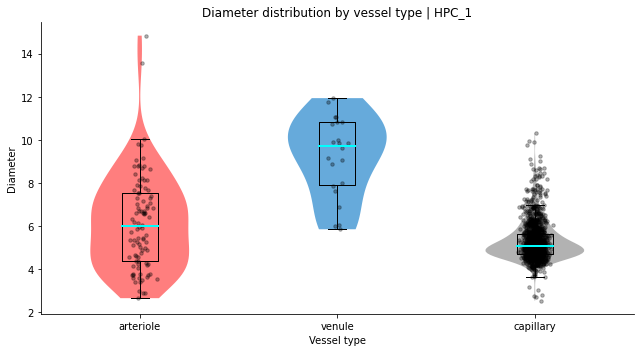

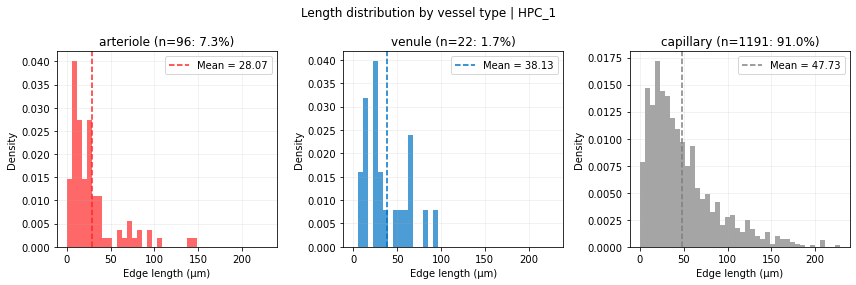

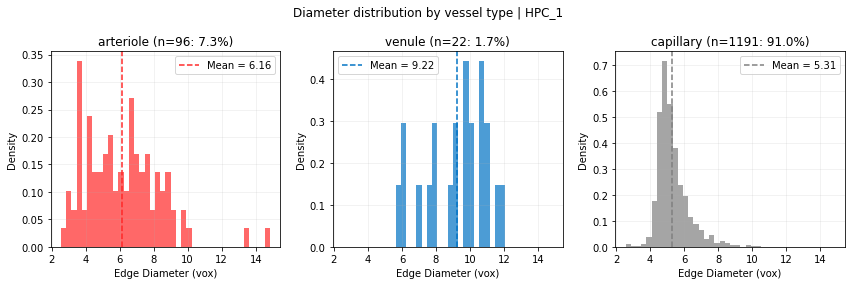


--- DEGREES ---

Unique degrees: [1 3 4 5 6]
HDN (>= 4): 66


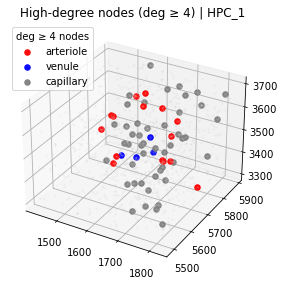


--- BC ANALYSIS ---



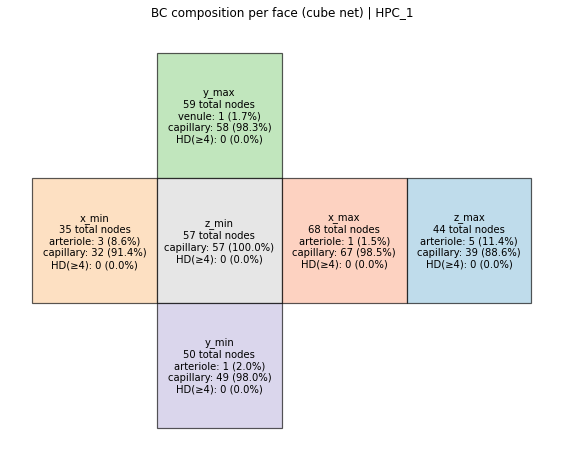

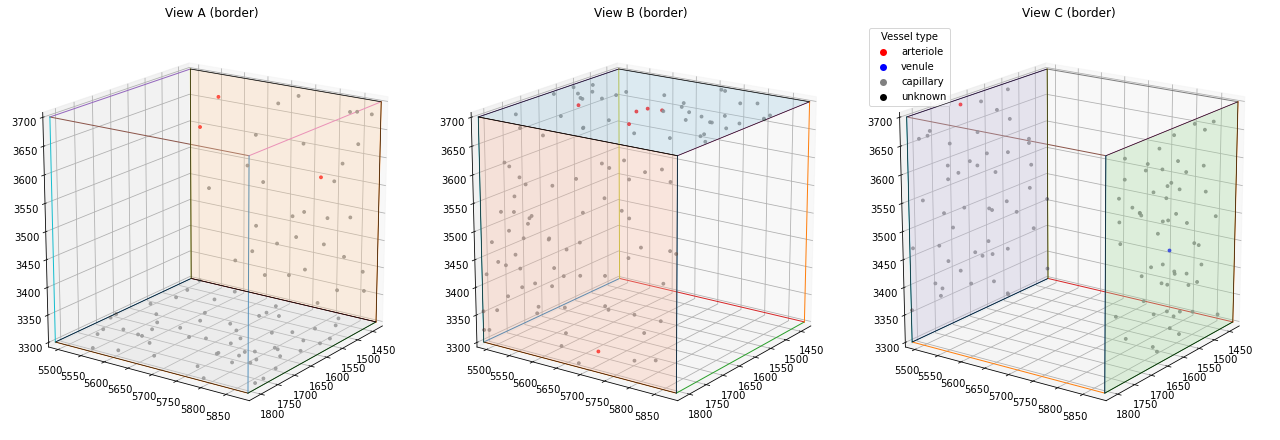


--- REDUNDANCY ---

[HPC_1] A-C frontier nodes: 44
[HPC_1] venous nodes: 23
[HPC_1] paths found: 41
{'graph': 'HPC_1', 'A_AC_nodes': 44, 'V_nodes': 23, 'pairs_with_path': 41, 'all_frontiers_reached_a_vein': False, 'median_full_len_um': 330.36825942993164, 'median_trimmed_capillary_len_um': 330.36825942993164, 'median_removed_um': 0.0, 'median_removed_frac': 0.0}
n paths: 41
median full: 330.36825942993164
median trimmed: 330.36825942993164
median removed: 0.0
median removed frac: 0.0


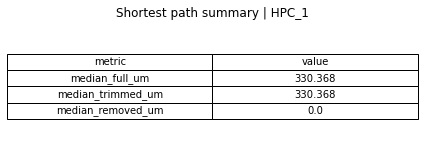

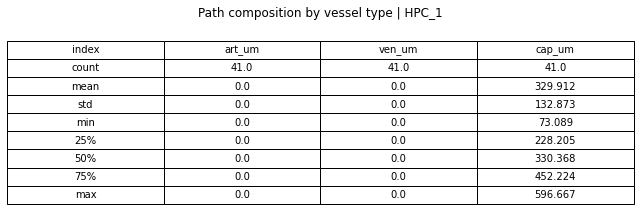


[COMPARISON SUMMARY]
{'graph': 'HPC_1', 'n_pairs': 41, 'n_target_changed': 0, 'pct_target_changed': 0.0, 'n_delta_um_nonzero': 0, 'pct_delta_um_nonzero': 0.0, 'n_delta_edges_nonzero': 0, 'pct_delta_edges_nonzero': 0.0, 'median_delta_um': 0.0, 'median_delta_edges': 0.0, 'n_weighted_paths_using_artery': 0, 'pct_weighted_paths_using_artery': 0.0, 'median_weighted_arterial_len_um': 0.0}
unique arterioles: 19
[HPC_1] edge-disjoint total = 21
[HPC_1] exported reconstructed paths = 21

--- VESSEL DENSITY ---

Number of boxes: 343
---- DENSITY CHECK ----
Global density box: 0.021218637794417367
Global length density box: 930.9763372915434
Mean TOTAL box density: 0.022635759128876894
Min TOTAL density: 0.005364212919101799
Max TOTAL density: 0.04459675865844548
Mean TOTAL length density: 988.0197159958888
Total vessel length (µm): 60385.28199965053
Total vessel length (mm): 60.38528199965053
-----------------------
{'graph': 'HPC_1', 'V': 1088, 'E': 1309, 'graph_density': 0.002213661453541858}

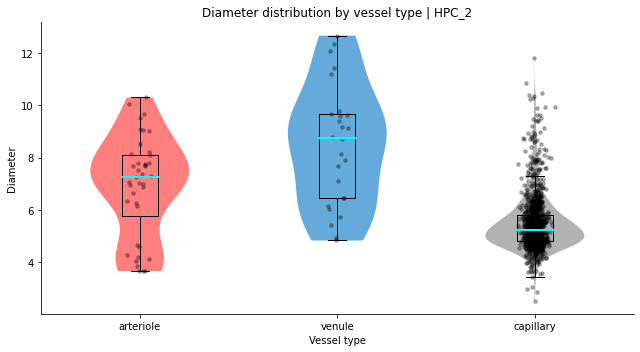

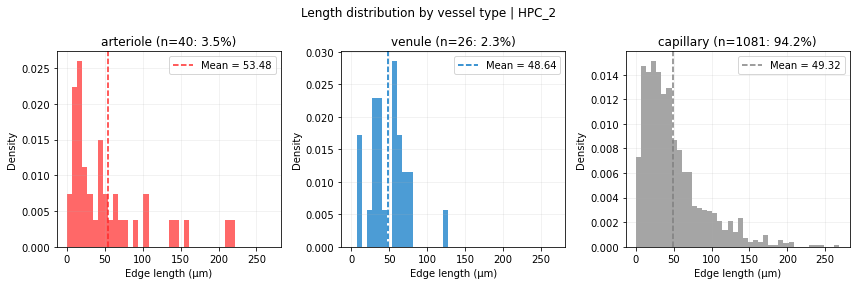

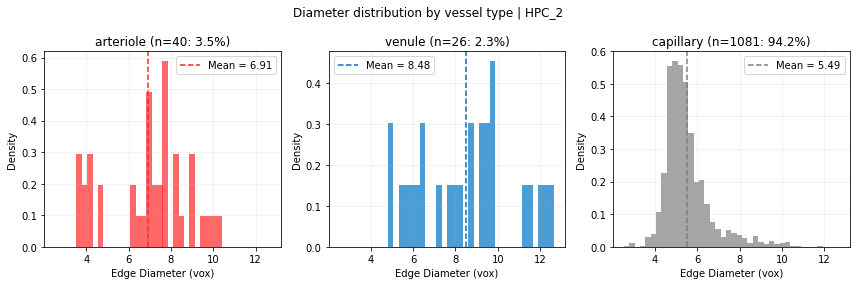


--- DEGREES ---

Unique degrees: [1 3 4 5 8]
HDN (>= 4): 54


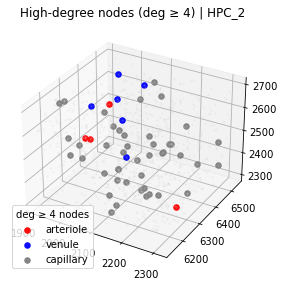


--- BC ANALYSIS ---



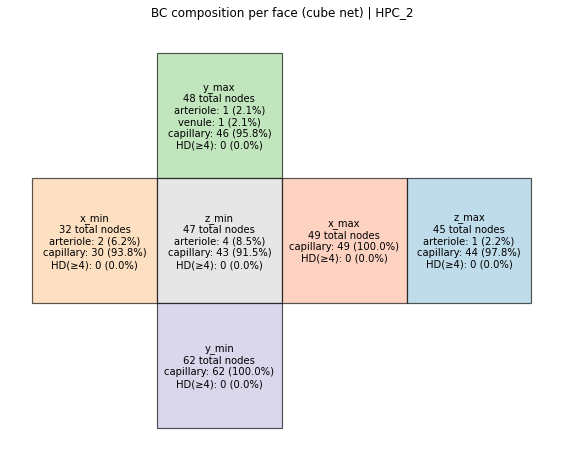

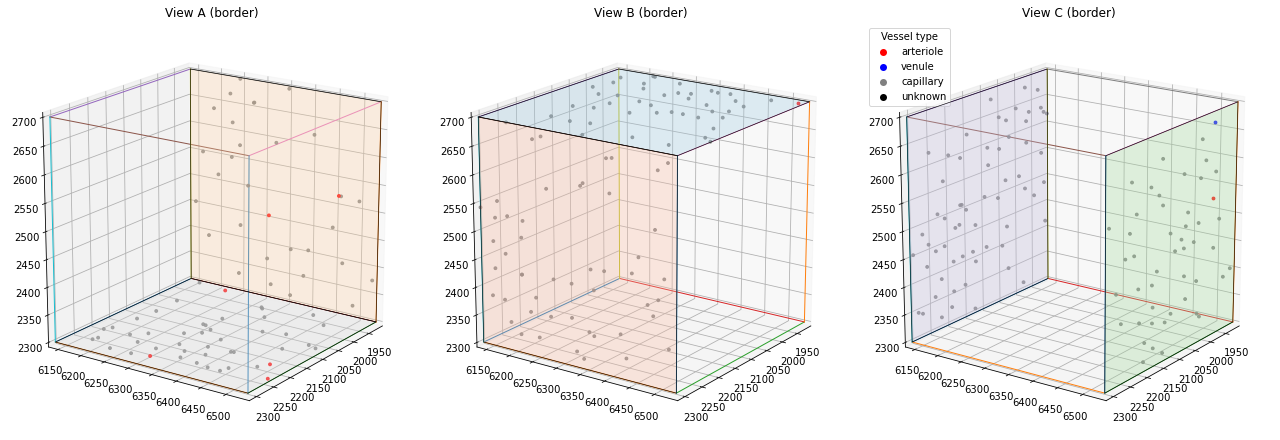


--- REDUNDANCY ---

[HPC_2] A-C frontier nodes: 22
[HPC_2] venous nodes: 27
[HPC_2] paths found: 19
{'graph': 'HPC_2', 'A_AC_nodes': 22, 'V_nodes': 27, 'pairs_with_path': 19, 'all_frontiers_reached_a_vein': False, 'median_full_len_um': 241.90000867843628, 'median_trimmed_capillary_len_um': 241.90000867843628, 'median_removed_um': 0.0, 'median_removed_frac': 0.0}
n paths: 19
median full: 241.90000867843628
median trimmed: 241.90000867843628
median removed: 0.0
median removed frac: 0.0


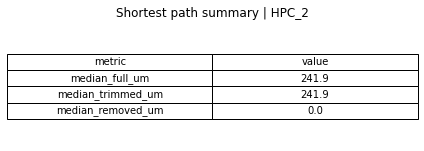

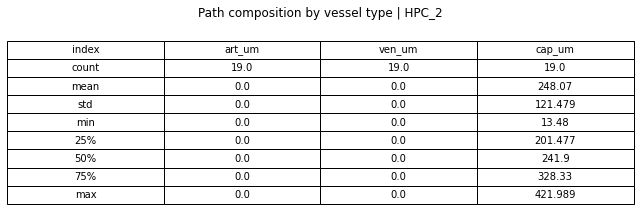


[COMPARISON SUMMARY]
{'graph': 'HPC_2', 'n_pairs': 19, 'n_target_changed': 0, 'pct_target_changed': 0.0, 'n_delta_um_nonzero': 0, 'pct_delta_um_nonzero': 0.0, 'n_delta_edges_nonzero': 0, 'pct_delta_edges_nonzero': 0.0, 'median_delta_um': 0.0, 'median_delta_edges': 0.0, 'n_weighted_paths_using_artery': 0, 'pct_weighted_paths_using_artery': 0.0, 'median_weighted_arterial_len_um': 0.0}
unique arterioles: 19
[HPC_2] edge-disjoint total = 26
[HPC_2] exported reconstructed paths = 26

--- VESSEL DENSITY ---

Number of boxes: 343
---- DENSITY CHECK ----
Global density box: 0.02125789311011265
Global length density box: 880.6336481033011
Mean TOTAL box density: 0.022175321208438403
Min TOTAL density: 0.006819466511798158
Max TOTAL density: 0.043281003791946375
Mean TOTAL length density: 925.8137097393704
Total vessel length (µm): 56714.32056461237
Total vessel length (mm): 56.71432056461237
-----------------------
{'graph': 'HPC_2', 'V': 947, 'E': 1147, 'graph_density': 0.0025606622448546765}

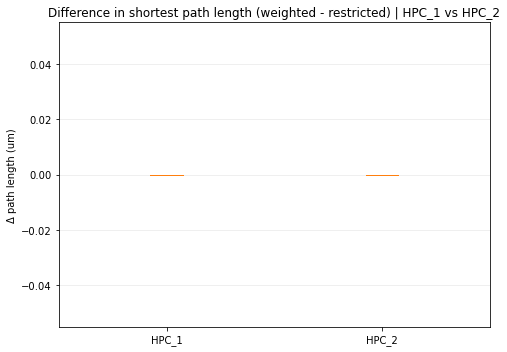

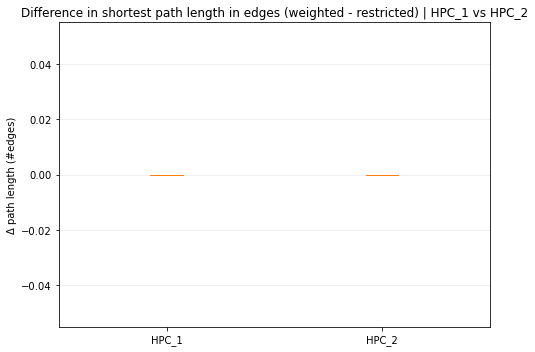

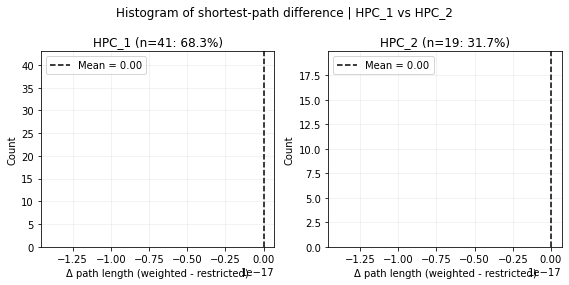

KeyError: ['path_len_with_artery', 'path_len_without_artery']

In [6]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import ttest_ind, ttest_rel

# ---------------------------------------------------------------------
# formatted analysis toolbox
# ---------------------------------------------------------------------
sys.path.insert(0, "/home/ana/MicroBrain/codes/Graph Analysis & by region/Graph analysis")
from graph_analysis_functions_formatted import *

# ---------------------------------------------------------------------
# local helpers
# ---------------------------------------------------------------------
ARTERY = 2
VEIN = 3
CAPILLARY = 4

def subset_ms_by_nkind(ms, nkind_code):
    m = np.asarray(ms["nkind"], dtype=int) == int(nkind_code)
    return {
        "midpoints": ms["midpoints"][m],
        "lengths": ms["lengths"][m],
        "nkind": ms["nkind"][m],
        "r0": ms["r0"][m],
        "r1": ms["r1"][m],
    }

def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def pairwise_ttests_table(df, value_col, graphs_order, group_col="graph"):
    rows = []
    present = [g for g in graphs_order if g in set(df[group_col].astype(str))]
    for g1, g2 in combinations(present, 2):
        x1 = _finite(df.loc[df[group_col] == g1, value_col].to_numpy(float))
        x2 = _finite(df.loc[df[group_col] == g2, value_col].to_numpy(float))

        if x1.size < 2 or x2.size < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_stat, p_val = ttest_ind(x1, x2, equal_var=False, nan_policy="omit")

        rows.append({
            "metric": value_col,
            "group1": g1,
            "group2": g2,
            "n1": int(x1.size),
            "n2": int(x2.size),
            "mean1": float(np.mean(x1)) if x1.size else np.nan,
            "mean2": float(np.mean(x2)) if x2.size else np.nan,
            "median1": float(np.median(x1)) if x1.size else np.nan,
            "median2": float(np.median(x2)) if x2.size else np.nan,
            "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
            "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        })
    return pd.DataFrame(rows)

def _p_to_text(p):
    if not np.isfinite(p):
        return "p=NA"
    if p < 1e-4:
        return "p<1e-4"
    return f"p={p:.3g}"

def _p_to_stars(p):
    if not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def add_pairwise_pvalues(ax, stats_df, positions, data_by_group):
    if stats_df is None or stats_df.empty:
        return

    valid_arrays = [np.asarray(v, float) for v in data_by_group.values() if len(v) > 0]
    if not valid_arrays:
        return

    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    if yr <= 0:
        yr = 1.0

    max_y = max(np.nanmax(v) for v in valid_arrays)
    n_pairs = len(stats_df)

    base = max_y + 0.05 * yr
    step = 0.10 * yr
    needed_top = base + (n_pairs + 1) * step

    if needed_top > ymax:
        ax.set_ylim(ymin, needed_top)
        ymin, ymax = ax.get_ylim()
        yr = ymax - ymin
        base = max_y + 0.05 * yr
        step = 0.08 * yr

    for i, row in enumerate(stats_df.itertuples(index=False)):
        g1, g2 = row.group1, row.group2
        if g1 not in positions or g2 not in positions:
            continue

        x1, x2 = positions[g1], positions[g2]
        if x1 > x2:
            x1, x2 = x2, x1

        y = base + i * step
        h = 0.025 * yr

        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
        ax.text(
            (x1 + x2) / 2.0,
            y + h + 0.01 * yr,
            f"{_p_to_stars(row.p_value)} ({_p_to_text(row.p_value)})",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black"
        )

def add_jitter_scatter(ax, xpos, y, color="black", jitter=0.08, alpha=0.22, s=10, max_points=2000):
    y = _finite(y)
    if y.size == 0:
        return

    if y.size > max_points:
        rng = np.random.default_rng(0)
        y = rng.choice(y, size=max_points, replace=False)

    rng = np.random.default_rng(0)
    xj = xpos + rng.uniform(-jitter, jitter, size=y.size)

    ax.scatter(
        xj, y,
        s=s,
        alpha=alpha,
        color=color,
        edgecolors="none",
        zorder=2
    )

def delta_median_pct(medians):
    medians = _finite(medians)
    if medians.size < 2:
        return np.nan
    m = float(np.median(medians))
    return np.nan if abs(m) < 1e-12 else 100.0 * (float(np.max(medians)) - float(np.min(medians))) / m

def paired_ttest(df, graphs_order, group_col="graph"):
    rows = []
    present = [g for g in graphs_order if g in set(df[group_col].astype(str))]

    for g in present:
        sub = df[df[group_col] == g].copy()
        sub = sub.dropna(subset=["path_len_with_artery", "path_len_without_artery"])

        x = _finite(sub["path_len_with_artery"].to_numpy(float))
        y = _finite(sub["path_len_without_artery"].to_numpy(float))

        n = min(len(x), len(y))
        x = x[:n]
        y = y[:n]

        if n < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_stat, p_val = ttest_rel(y, x, nan_policy="omit")

        rows.append({
            "graph": g,
            "n_pairs": int(n),
            "mean_with_artery": float(np.mean(x)) if n else np.nan,
            "mean_without_artery": float(np.mean(y)) if n else np.nan,
            "median_with_artery": float(np.median(x)) if n else np.nan,
            "median_without_artery": float(np.median(y)) if n else np.nan,
            "mean_delta_no_minus_yes": float(np.mean(y - x)) if n else np.nan,
            "median_delta_no_minus_yes": float(np.median(y - x)) if n else np.nan,
            "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
            "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        })

    return pd.DataFrame(rows)

def path_to_edge_ids(graph, path):
    eids = []
    for u, v in zip(path[:-1], path[1:]):
        eid = graph.get_eid(u, v, directed=False, error=False)
        if eid == -1:
            return []
        eids.append(eid)
    return eids

def path_edge_type_sequence(graph, path, edge_type_attr="nkind"):
    eids = path_to_edge_ids(graph, path)
    if len(eids) == 0:
        return np.array([], dtype=int)
    return np.asarray(graph.es[eids][edge_type_attr], dtype=int)

def arterial_length_in_path(graph, path, edge_type_attr="nkind", length_attr="length"):
    eids = path_to_edge_ids(graph, path)
    if len(eids) == 0:
        return np.nan
    nk = np.asarray(graph.es[eids][edge_type_attr], dtype=int)
    L = np.asarray(graph.es[eids][length_attr], dtype=float)
    return float(np.sum(L[nk == ARTERY]))

def build_allowed_subgraph(graph, artery_continuity=True, edge_type_attr="nkind"):
    if artery_continuity:
        keep_eids = list(range(graph.ecount()))
    else:
        keep_eids = [e.index for e in graph.es if int(e[edge_type_attr]) != ARTERY]
    subg = graph.subgraph_edges(keep_eids, delete_vertices=False)
    return subg


def compare_frontier_modes_detailed(
    graph,
    edge_type_attr="nkind",
    weight_attr="length",
    tie_break_edges=True,
    tol=1e-9,
):
    """
    Compara shortest paths desde cada A/C frontier en dos modos:
      - artery_continuity=True
      - artery_continuity=False

    usando el mismo weight_attr en ambos casos.

    Devuelve una tabla por frontier node con:
      - target elegido en cada modo
      - distancia y nº de edges
      - uso de arteria en el modo con continuidad
      - comparación contra el mismo target forzado sin arteria
    """

    (
        paths_yes,
        dist_yes,
        n_edges_yes,
        src_yes,
        tgt_yes,
        A_valid_yes,
        V_valid_yes,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=True,
        edge_type_attr=edge_type_attr,
        weight_attr=weight_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    (
        paths_no,
        dist_no,
        n_edges_no,
        src_no,
        tgt_no,
        A_valid_no,
        V_valid_no,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=False,
        edge_type_attr=edge_type_attr,
        weight_attr=weight_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    by_frontier_yes = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(paths_yes, dist_yes, n_edges_yes, src_yes, tgt_yes)
    }

    by_frontier_no = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(paths_no, dist_no, n_edges_no, src_no, tgt_no)
    }

    all_frontiers = sorted(set(by_frontier_yes) | set(by_frontier_no))
    rows = []

    for f in all_frontiers:
        ry = by_frontier_yes.get(f)
        rn = by_frontier_no.get(f)

        path_yes = None if ry is None else ry["path"]
        path_no  = None if rn is None else rn["path"]

        seq_yes = np.array([], dtype=int) if path_yes is None else path_edge_type_sequence(graph, path_yes)

        forced_same_target_path = []
        forced_same_target_um = np.nan
        forced_same_target_edges = np.nan
        forced_same_target_exists = False

        rows.append({
            "source_frontier": int(f),

            "has_with_artery": ry is not None,
            "has_without_artery": rn is not None,

            "target_with_artery": np.nan if ry is None else ry["target"],
            "target_without_artery": np.nan if rn is None else rn["target"],

            "same_target_venous": (
                np.nan if (ry is None or rn is None)
                else bool(ry["target"] == rn["target"])
            ),

            "path_len_with_artery": np.nan if ry is None else ry["dist_um"],
            "path_len_without_artery": np.nan if rn is None else rn["dist_um"],
            "delta_no_minus_yes": (
                np.nan if (ry is None or rn is None)
                else rn["dist_um"] - ry["dist_um"]
            ),

            "path_len_with_artery_edges": np.nan if ry is None else ry["n_edges"],
            "path_len_without_artery_edges": np.nan if rn is None else rn["n_edges"],
            "delta_edges_no_minus_yes": (
                np.nan if (ry is None or rn is None)
                else rn["n_edges"] - ry["n_edges"]
            ),

            "uses_artery_with_artery": bool(np.any(seq_yes == ARTERY)) if len(seq_yes) else False,
            "arterial_len_with_artery_um": np.nan if path_yes is None else arterial_length_in_path(graph, path_yes),
            "arterial_edges_with_artery": int(np.sum(seq_yes == ARTERY)) if len(seq_yes) else 0,

            "forced_same_target_without_artery_exists": forced_same_target_exists,
            "forced_same_target_without_artery_um": forced_same_target_um,
            "forced_same_target_without_artery_edges": forced_same_target_edges,

            "forced_same_target_delta_vs_with_um": (
                np.nan if (ry is None or not forced_same_target_exists)
                else forced_same_target_um - ry["dist_um"]
            ),
            "forced_same_target_delta_vs_best_without_um": (
                np.nan if (rn is None or not forced_same_target_exists)
                else forced_same_target_um - rn["dist_um"]
            ),
            "forced_same_target_delta_vs_with_edges": (
                np.nan if (ry is None or not forced_same_target_exists)
                else forced_same_target_edges - ry["n_edges"]
            ),
            "forced_same_target_delta_vs_best_without_edges": (
                np.nan if (rn is None or not forced_same_target_exists)
                else forced_same_target_edges - rn["n_edges"]
            ),
        })

    return pd.DataFrame(rows)


def compare_frontier_restricted_vs_weighted(
    graph,
    edge_type_attr="nkind",
    length_weight_attr="length",
    weighted_attr="w_cap_prior",
    tie_break_edges=True,
    tol=1e-9,
):
    """
    Compara dos estrategias de shortest path desde cada A/C frontier:

    1) restricted:
       artery_continuity=False, weight_attr=length

    2) weighted:
       artery_continuity=True, weight_attr=weighted_attr

    Devuelve una tabla por frontier node.
    """

    (
        paths_restricted,
        dist_restricted,
        n_edges_restricted,
        src_restricted,
        tgt_restricted,
        A_valid_restricted,
        V_valid_restricted,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=False,
        edge_type_attr=edge_type_attr,
        weight_attr=length_weight_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    (
        paths_weighted,
        dist_weighted,
        n_edges_weighted,
        src_weighted,
        tgt_weighted,
        A_valid_weighted,
        V_valid_weighted,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=True,
        edge_type_attr=edge_type_attr,
        weight_attr=weighted_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    by_frontier_restricted = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(
            paths_restricted, dist_restricted, n_edges_restricted, src_restricted, tgt_restricted
        )
    }

    by_frontier_weighted = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(
            paths_weighted, dist_weighted, n_edges_weighted, src_weighted, tgt_weighted
        )
    }

    all_frontiers = sorted(set(by_frontier_restricted) | set(by_frontier_weighted))
    rows = []

    for f in all_frontiers:
        rr = by_frontier_restricted.get(f)
        rw = by_frontier_weighted.get(f)

        path_r = None if rr is None else rr["path"]
        path_w = None if rw is None else rw["path"]

        seq_w = np.array([], dtype=int) if path_w is None else path_edge_type_sequence(graph, path_w)

        rows.append({
            "source_frontier": int(f),

            "has_restricted": rr is not None,
            "has_weighted": rw is not None,

            "target_restricted": np.nan if rr is None else rr["target"],
            "target_weighted": np.nan if rw is None else rw["target"],

            "same_target_venous": (
                np.nan if (rr is None or rw is None)
                else bool(rr["target"] == rw["target"])
            ),

            "path_len_restricted": np.nan if rr is None else rr["dist_um"],
            "path_len_weighted": np.nan if rw is None else rw["dist_um"],
            "delta_weighted_minus_restricted": (
                np.nan if (rr is None or rw is None)
                else rw["dist_um"] - rr["dist_um"]
            ),

            "path_len_restricted_edges": np.nan if rr is None else rr["n_edges"],
            "path_len_weighted_edges": np.nan if rw is None else rw["n_edges"],
            "delta_edges_weighted_minus_restricted": (
                np.nan if (rr is None or rw is None)
                else rw["n_edges"] - rr["n_edges"]
            ),

            "weighted_uses_artery": bool(np.any(seq_w == ARTERY)) if len(seq_w) else False,
            "weighted_arterial_len_um": np.nan if path_w is None else arterial_length_in_path(graph, path_w),
            "weighted_arterial_edges": int(np.sum(seq_w == ARTERY)) if len(seq_w) else 0,
        })

    return pd.DataFrame(rows)

def summarize_frontier_comparison(df_cmp_local, graph_name):
    ss = df_cmp_local.dropna(subset=["path_len_restricted", "path_len_weighted"]).copy()

    if ss.empty:
        return {
            "graph": graph_name,
            "n_pairs": 0,
            "n_target_changed": 0,
            "pct_target_changed": np.nan,
            "n_delta_um_nonzero": 0,
            "pct_delta_um_nonzero": np.nan,
            "n_delta_edges_nonzero": 0,
            "pct_delta_edges_nonzero": np.nan,
            "median_delta_um": np.nan,
            "median_delta_edges": np.nan,
            "n_weighted_paths_using_artery": 0,
            "pct_weighted_paths_using_artery": np.nan,
            "median_weighted_arterial_len_um": np.nan,
        }

    target_changed = (ss["same_target_venous"] == False)
    delta_um_nonzero = ~np.isclose(ss["delta_weighted_minus_restricted"].to_numpy(float), 0.0, atol=1e-9)
    delta_edges_nonzero = ~np.isclose(ss["delta_edges_weighted_minus_restricted"].to_numpy(float), 0.0, atol=1e-9)
    uses_artery = ss["weighted_uses_artery"] == True

    return {
        "graph": graph_name,
        "n_pairs": int(len(ss)),
        "n_target_changed": int(np.sum(target_changed)),
        "pct_target_changed": 100.0 * float(np.mean(target_changed)),
        "n_delta_um_nonzero": int(np.sum(delta_um_nonzero)),
        "pct_delta_um_nonzero": 100.0 * float(np.mean(delta_um_nonzero)),
        "n_delta_edges_nonzero": int(np.sum(delta_edges_nonzero)),
        "pct_delta_edges_nonzero": 100.0 * float(np.mean(delta_edges_nonzero)),
        "median_delta_um": float(np.nanmedian(ss["delta_weighted_minus_restricted"])),
        "median_delta_edges": float(np.nanmedian(ss["delta_edges_weighted_minus_restricted"])),
        "n_weighted_paths_using_artery": int(np.sum(uses_artery)),
        "pct_weighted_paths_using_artery": 100.0 * float(np.mean(uses_artery)),
        "median_weighted_arterial_len_um": float(np.nanmedian(ss["weighted_arterial_len_um"])),
    }

def plot_restricted_vs_weighted_scatter(df_comparison, graph_name, figsize=(5, 5)):
    sub = df_comparison[df_comparison["graph"] == graph_name].copy()
    sub = sub.dropna(subset=["path_len_restricted", "path_len_weighted"])

    x = sub["path_len_restricted"].to_numpy(float)
    y = sub["path_len_weighted"].to_numpy(float)

    if len(sub) == 0:
        print(f"No paired data for {graph_name}")
        return

    plt.figure(figsize=figsize)
    plt.scatter(x, y, alpha=0.7)

    mx = max(np.max(x), np.max(y)) if len(x) else 1.0
    plt.plot([0, mx], [0, mx], "--")

    plt.xlabel("Restricted (um)")
    plt.ylabel("Weighted + continuity (um)")
    plt.title(f"Restricted vs weighted | {graph_name}")
    plt.tight_layout()
    plt.show()


def plot_with_vs_without_scatter(df_comparison, graph_name, figsize=(5, 5)):
    sub = df_comparison[df_comparison["graph"] == graph_name].copy()
    sub = sub.dropna(subset=["path_len_with_artery", "path_len_without_artery"])

    x = sub["path_len_with_artery"].to_numpy(float)
    y = sub["path_len_without_artery"].to_numpy(float)

    if len(sub) == 0:
        print(f"No paired data for {graph_name}")
        return

    plt.figure(figsize=figsize)
    plt.scatter(x, y, alpha=0.7)

    mx = max(np.max(x), np.max(y)) if len(x) else 1.0
    plt.plot([0, mx], [0, mx], "--")

    plt.xlabel("With artery (um)")
    plt.ylabel("Without artery (um)")
    plt.title(f"With vs without artery | {graph_name}")
    plt.tight_layout()
    plt.show()
def plot_frontier_path_differences(df_comparison, graph_name, figsize=(12, 5)):
    sub = df_comparison[df_comparison["graph"] == graph_name].copy()
    sub = sub.dropna(subset=["delta_weighted_minus_restricted"])
    sub = sub.sort_values("delta_weighted_minus_restricted").reset_index(drop=True)

    if len(sub) == 0:
        print(f"No delta data for {graph_name}")
        return

    x = np.arange(len(sub))
    y = sub["delta_weighted_minus_restricted"].to_numpy(float)
    changed = sub["same_target_venous"] == False

    plt.figure(figsize=figsize)
    plt.plot(x, y, marker="o", linewidth=1)
    plt.axhline(0, linewidth=1)

    if np.any(changed):
        plt.scatter(
            x[changed.to_numpy()],
            y[changed.to_numpy()],
            marker="x",
            s=60,
            label="target venous changed"
        )
        plt.legend()

    plt.xlabel("Frontier nodes (sorted)")
    plt.ylabel("Δ length = weighted - restricted (um)")
    plt.title(f"Per-frontier delta | {graph_name}")
    plt.tight_layout()
    plt.show()
def plot_paired_restricted_vs_weighted_boxplots_from_comparison(
    df_comparison,
    graphs_order,
    ylabel="Shortest path length (um)",
    title=None,
    sharey=True,
):
    present = [g for g in graphs_order if g in set(df_comparison["graph"].astype(str))]
    if len(present) == 0:
        print("No graphs found.")
        return pd.DataFrame()

    all_y = []
    for g in present:
        sub = df_comparison[df_comparison["graph"] == g].copy()
        sub = sub.dropna(subset=["path_len_restricted", "path_len_weighted"])

        x_r = _finite(sub["path_len_restricted"].to_numpy(float))
        x_w = _finite(sub["path_len_weighted"].to_numpy(float))

        if x_r.size:
            all_y.append(x_r)
        if x_w.size:
            all_y.append(x_w)

    if len(all_y) == 0:
        print("No paired values found.")
        return pd.DataFrame()

    all_y = np.concatenate(all_y)
    global_ymin_data = float(np.nanmin(all_y))
    global_ymax_data = float(np.nanmax(all_y))
    yr = global_ymax_data - global_ymin_data
    if not np.isfinite(yr) or yr <= 0:
        yr = 1.0

    common_ymin = global_ymin_data - 0.03 * yr

    fig, axes = plt.subplots(
        1, len(present),
        figsize=(5.2 * len(present), 5.8),
        sharey=sharey
    )
    if len(present) == 1:
        axes = [axes]

    stats_out = []

    for ax, g in zip(axes, present):
        sub = df_comparison[df_comparison["graph"] == g].copy()
        sub = sub.dropna(subset=["path_len_restricted", "path_len_weighted"])

        x_r = _finite(sub["path_len_restricted"].to_numpy(float))
        x_w = _finite(sub["path_len_weighted"].to_numpy(float))

        n = min(len(x_r), len(x_w))
        x_r = x_r[:n]
        x_w = x_w[:n]

        if n == 0:
            ax.set_axis_off()
            continue

        bp = ax.boxplot(
            [x_r, x_w],
            labels=["restricted", "weighted"],
            showfliers=False,
            patch_artist=True,
            widths=0.5
        )

        bp["boxes"][0].set_facecolor("tab:blue")
        bp["boxes"][0].set_alpha(0.30)
        bp["boxes"][1].set_facecolor("tab:orange")
        bp["boxes"][1].set_alpha(0.30)

        add_jitter_scatter(ax, 1, x_r, color="tab:blue")
        add_jitter_scatter(ax, 2, x_w, color="tab:orange")

        if n < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_stat, p_val = ttest_rel(x_w, x_r, nan_policy="omit")

        st = pd.DataFrame([{
            "group1": "restricted",
            "group2": "weighted",
            "p_value": p_val,
        }])

        add_pairwise_pvalues(
            ax,
            st,
            positions={"restricted": 1, "weighted": 2},
            data_by_group={
                "restricted": x_r,
                "weighted": x_w,
            }
        )

        dm = delta_median_pct(np.array([np.median(x_r), np.median(x_w)], float))
        ax.set_title(f"{g}\nΔmedian={dm:.1f}%", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(alpha=0.25, axis="y")
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=10, labelleft=True)
        ax.set_xlim(0.3, 2.7)

        stats_out.append({
            "graph": g,
            "n_pairs": int(n),
            "mean_restricted": float(np.mean(x_r)),
            "mean_weighted": float(np.mean(x_w)),
            "median_restricted": float(np.median(x_r)),
            "median_weighted": float(np.median(x_w)),
            "mean_delta_weighted_minus_restricted": float(np.mean(x_w - x_r)),
            "median_delta_weighted_minus_restricted": float(np.median(x_w - x_r)),
            "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
            "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        })

    ymaxs = []
    for ax in axes:
        if ax.axison:
            ymaxs.append(ax.get_ylim()[1])

    common_ymax = max(ymaxs) if ymaxs else (global_ymax_data + 0.10 * yr)

    for ax in axes:
        if ax.axison:
            ax.set_ylim(common_ymin, common_ymax)

    if title is not None:
        fig.suptitle(title, fontsize=14)
        plt.tight_layout(rect=[0.03, 0.03, 1, 0.93])
    else:
        plt.tight_layout(rect=[0.03, 0.03, 1, 1])

    plt.show()

    return pd.DataFrame(stats_out)

# ---------------------------------------------------------------------
# paths / params
# ---------------------------------------------------------------------
out_root = "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED"
os.makedirs(out_root, exist_ok=True)

PATHS = {
    "HPC_1": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut1.pkl",
    "HPC_2": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut2.pkl",
    #"HPC_3": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut3.pkl",
}

HIPPO_CENTERS = {
    "HPC_1": [1000, 3500, 1400],
    "HPC_2": [1300, 3900, 1000],
    "HPC_3": [2100, 4200, 750],
}

box_size_um = (400, 400, 400)
degree_thr = 4
eps_vox = 2.0
slab_um_cutbox = 10.0
slab_axis = "z"
bins_hist = 40

BOX_ORDER = list(PATHS.keys())
BOX_LABEL = " vs ".join(BOX_ORDER)

VESSEL_COL = {
    "arteriole": "#d62728",
    "venule": "#1f77b4",
    "capillary": "#7f7f7f",
    "unknown": "#c7c7c7",
}

BOX_COL = {
    "HPC_1": "tab:blue",
    "HPC_2": "tab:orange",
    "HPC_3": "tab:green",
}

# ---------------------------------------------------------------------
# safety check for res_um_per_vox
# ---------------------------------------------------------------------
try:
    res_um_per_vox
except NameError:
    res_um_per_vox = 1.0
    print("[WARNING] res_um_per_vox was not defined. Using res_um_per_vox = 1.0")

# ---------------------------------------------------------------------
# COLLECTORS (global across all boxes)
# ---------------------------------------------------------------------
all_summaries = []
diam_length_global_boxes = []
av_path_size_rows = []
av_rows = []
bc_rows = []
hdn_nodes_rows = []
redundancy_rows = []
comparison_detailed_rows = []
comparison_summary_rows = []

density_boxes_rows = []
graph_density_rows = []
bc_long_rows = []
trimmed_rows = []

# ---------------------------------------------------------------------
# analysis loop (per box / per graph)
# ---------------------------------------------------------------------
for name, path in PATHS.items():
    center = HIPPO_CENTERS[name]

    print("\n======================")
    print("Analyzing:", name)
    print("======================\n")
    print("path:", path)

    g = load_graph(path)
    G = keep_giant_component(g)

    print("\n- Graph sanity check\n")
    g_unit = G["unit"] if ("unit" in G.attributes()) else "unknown"
    d_unit = G["diameter_unit"] if ("diameter_unit" in G.attributes()) else "unknown"
    print(f"[{name}] units: coords/length={g_unit} | diameter={d_unit}")

    cut_box = make_box_in_um(center, box_size_um, res_um_per_vox=res_um_per_vox)
    validate_box_faces(cut_box)

    print(
        "BOX bounds:\n"
        f"  x: [{cut_box['xmin']:.6f}, {cut_box['xmax']:.6f}]  (size={cut_box['xmax'] - cut_box['xmin']:.6f})\n"
        f"  y: [{cut_box['ymin']:.6f}, {cut_box['ymax']:.6f}]  (size={cut_box['ymax'] - cut_box['ymin']:.6f})\n"
        f"  z: [{cut_box['zmin']:.6f}, {cut_box['zmax']:.6f}]  (size={cut_box['zmax'] - cut_box['zmin']:.6f})\n"
    )

    w_cap_prior = add_penalization_weights(
        G,
        new_weight_attr="w_cap_prior",
        edge_type_attr="nkind",
        length_attr="length",
        penalty_art=1e5,
        penalty_ven=1e5,
    )

    # -----------------------------------------------------------------
    # Basic stats
    # -----------------------------------------------------------------
    dup = duplicated_edge_stats(G)
    loops = loop_edge_stats(G)
    print("- Duplicated edges:", dup)
    print("- Loops:", loops)

    # -----------------------------------------------------------------
    # Lengths / diameters by type
    # -----------------------------------------------------------------
    avg_len_dict = get_avg_length_nkind(G)
    avg_len_by_type = {
        EDGE_NKIND_TO_LABEL.get(int(k), str(k)): float(v)
        for k, v in avg_len_dict.items()
    }

    diam_stats = diameter_stats_nkind(
        G,
        label_dict=EDGE_NKIND_TO_LABEL,
        plot=True,
        title_suffix=name
    )

    e_diam = np.asarray(G.es["diameter"], float)
    e_leng = np.asarray(G.es["length"], float)
    nk = np.asarray(G.es["nkind"], int)

    etype_counts = edge_type_counts(nk, EDGE_NKIND_TO_LABEL)
    E_arteriole = int(etype_counts["arteriole"])
    E_venule = int(etype_counts["venule"])
    E_capillary = int(etype_counts["capillary"])
    E_unknown = int(etype_counts["unknown"])

    for k in np.unique(nk):
        lab = EDGE_NKIND_TO_LABEL.get(int(k), str(k))
        m = (nk == k)
        if np.any(m):
            diam_length_global_boxes.append(pd.DataFrame({
                "graph": name,
                "type": str(lab),
                "diameter_vox": e_diam[m],
                "length_um": e_leng[m],
            }))

    plot_hist_by_category_general(
        values=e_leng,
        category=nk,
        label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist,
        layout="horizontal",
        density=True,
        show_mean=True,
        variable_name="Edge length (µm)",
        category_name="Vessel type",
        main_title=f"Length distribution by vessel type | {name}"
    )

    plot_hist_by_category_general(
        values=e_diam,
        category=nk,
        label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist,
        layout="horizontal",
        density=True,
        show_mean=True,
        variable_name="Edge Diameter (vox)",
        category_name="Vessel type",
        main_title=f"Diameter distribution by vessel type | {name}"
    )

    # -----------------------------------------------------------------
    # Degrees / HDN
    # -----------------------------------------------------------------
    print("\n--- DEGREES ---\n")
    get_degrees(G, threshold=degree_thr)

    hdn = analyze_hdn_pattern_in_box(
        G,
        box=cut_box,
        coords_attr="coords",
        space="um",
        degree_thr=degree_thr,
        eps_vox=eps_vox
    )

    deg = np.asarray(G.degree(), int)
    hdn_nodes = np.where(deg >= degree_thr)[0]
    coords = np.asarray(G.vs["coords"], float)

    for v in hdn_nodes:
        t = infer_node_type_from_incident_edges(G, int(v))
        x, y, z = coords[int(v)]
        hdn_nodes_rows.append({
            "graph": name,
            "v": int(v),
            "x": float(x),
            "y": float(y),
            "z": float(z),
            "degree": int(deg[int(v)]),
            "type": t
        })

    plot_degree_nodes_spatial(
        G,
        coords_attr="coords",
        degree_min=degree_thr,
        degree_max=None,
        by_type=True,
        title=f"High-degree nodes (deg ≥ {degree_thr}) | {name}"
    )

    # -----------------------------------------------------------------
    # BC analysis
    # -----------------------------------------------------------------
    print("\n--- BC ANALYSIS ---\n")

    bc = analyze_bc_faces(
        G,
        cut_box,
        coords_attr="coords",
        space="um",
        eps_vox=eps_vox,
        degree_thr=degree_thr,
        mode="border",
        diam_attr="diameter",
        return_diameter_values=True,
    )

    bc_long_df = bc_diameter_longtable(bc, box_name=name).copy()
    bc_long_df["graph"] = name
    bc_long_rows.append(bc_long_df)

    bc_df = bc_faces_table(bc, box_name=name).copy()
    bc_df["graph"] = name
    bc_rows.append(bc_df)

    plot_bc_cube_net(bc, title=f"BC composition per face (cube net) | {name}")
    plot_bc_3_cubes_tinted(
        G,
        cut_box,
        coords_attr="coords",
        space="um",
        eps_vox=eps_vox,
        mode="border"
    )

    # -----------------------------------------------------------------
    # Redundancy / resilience
    # -----------------------------------------------------------------
    print("\n--- REDUNDANCY ---\n")

    # OFFICIAL analysis: no arterial continuity

    shortest_paths_noA, dist_no, path_n_edges, source_frontiers, target_venous, A, V = \
    shortest_av_paths_from_ac_frontier(
        G,
        artery_continuity=False,
        edge_type_attr="nkind",
        weight_attr="length",
        tie_break_edges=True,
        tol=1e-6,
    )


    print(f"[{name}] A-C frontier nodes: {len(A)}")
    print(f"[{name}] venous nodes: {len(V)}")
    print(f"[{name}] paths found: {len(shortest_paths_noA)}")

    for p, d, a, v in zip(shortest_paths_noA, dist_no, source_frontiers, target_venous):
        av_path_size_rows.append({
            "graph": name,
            "source_frontier": int(a),
            "target_venous": int(v),
            "path_len_edges": int(len(p) - 1),
            "path_len_um": float(d),
        })

    rows_trimmed = []
    for p in shortest_paths_noA:
        full_eids = path_to_edge_ids(G, p)
        full_len = float(np.sum(np.asarray(G.es[full_eids]["length"], float))) if len(full_eids) else np.nan
        trimmed_len = float(trimmed_capillary_length(G, p))

        removed_um = full_len - trimmed_len if np.isfinite(full_len) and np.isfinite(trimmed_len) else np.nan
        removed_frac = removed_um / full_len if np.isfinite(removed_um) and np.isfinite(full_len) and full_len > 0 else np.nan

        rows_trimmed.append({
            "graph": name,
            "full_len_um": full_len,
            "trimmed_capillary_len_um": trimmed_len,
            "removed_um": removed_um,
            "removed_frac": removed_frac,
            "n_edges_full": int(len(p) - 1),
        })

    df_trimmed = pd.DataFrame(rows_trimmed)

    for _, r in df_trimmed.iterrows():
        trimmed_rows.append({
            "graph": name,
            "full_len_um": float(r["full_len_um"]),
            "trimmed_capillary_len_um": float(r["trimmed_capillary_len_um"]),
            "removed_um": float(r["removed_um"]),
            "removed_frac": float(r["removed_frac"]) if np.isfinite(r["removed_frac"]) else np.nan,
            "n_edges_full": int(r["n_edges_full"]),
        })

    av_stats = {
        "graph": name,
        "A_AC_nodes": int(len(A)),
        "V_nodes": int(len(V)),
        "pairs_with_path": int(len(shortest_paths_noA)),
        "all_frontiers_reached_a_vein": bool(len(shortest_paths_noA) == len(A)),
        "median_full_len_um": float(np.nanmedian(df_trimmed["full_len_um"])) if not df_trimmed.empty else np.nan,
        "median_trimmed_capillary_len_um": float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])) if not df_trimmed.empty else np.nan,
        "median_removed_um": float(np.nanmedian(df_trimmed["removed_um"])) if not df_trimmed.empty else np.nan,
        "median_removed_frac": float(np.nanmedian(df_trimmed["removed_frac"])) if not df_trimmed.empty else np.nan,
    }

    av_rows.append(av_stats)
    print(av_stats)

    if len(shortest_paths_noA) > 0:
        export_paths_vtp(
            G,
            shortest_paths_noA,
            os.path.join(out_root, f"{name}_shortest_paths_AC_to_nearest_vein.vtp")
        )

        print("n paths:", len(shortest_paths_noA))
        print("median full:", np.nanmedian(df_trimmed["full_len_um"]))
        print("median trimmed:", np.nanmedian(df_trimmed["trimmed_capillary_len_um"]))
        print("median removed:", np.nanmedian(df_trimmed["removed_um"]))
        print("median removed frac:", np.nanmedian(df_trimmed["removed_frac"]))

        df_trimmed.to_csv(
            os.path.join(out_root, f"{name}_trimmed_shortest_paths.csv"),
            index=False
        )

    summary_trimmed = pd.DataFrame({
        "metric": ["median_full_um", "median_trimmed_um", "median_removed_um"],
        "value": [
            float(np.nanmedian(df_trimmed["full_len_um"])) if not df_trimmed.empty else np.nan,
            float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])) if not df_trimmed.empty else np.nan,
            float(np.nanmedian(df_trimmed["removed_um"])) if not df_trimmed.empty else np.nan,
        ]
    })

    dataframe_to_table_figure(
        summary_trimmed,
        title=f"Shortest path summary | {name}",
        figsize=(6, 2.2)
    )

    diag_rows = []
    for p in shortest_paths_noA:
        diag_rows.append(removed_by_type(G, p))

    df_diag = pd.DataFrame(diag_rows)
    diag_summary = df_diag.describe().reset_index()

    dataframe_to_table_figure(
        diag_summary,
        title=f"Path composition by vessel type | {name}",
        figsize=(9, 3.2)
    )
    

    # Detailed comparison with vs without artery continuity
    #df_cmp_local = compare_frontier_modes_detailed(G)

    # Comparison without artery continuity vs weighted edges
    df_cmp_local = compare_frontier_restricted_vs_weighted(
        G,
        edge_type_attr="nkind",
        length_weight_attr="length",
        weighted_attr="w_cap_prior",
        tie_break_edges=True,
        tol=1e-6,
    )

    df_cmp_local["graph"] = name
    comparison_detailed_rows.append(df_cmp_local)

    cmp_summary = summarize_frontier_comparison(df_cmp_local, name)
    comparison_summary_rows.append(cmp_summary)




    print("\n[COMPARISON SUMMARY]")
    print(cmp_summary)

    # edge disjoint A-V
    redundancy = max_edge_disjoint_av(G)

    n_disjoint = int(redundancy["n_edge_disjoint_av"])
    nA = int(redundancy["nA"])
    nV = int(redundancy["nV"])
    independent_paths = redundancy["paths"]

    print("unique arterioles:", len(set([p[0] for p in independent_paths])) if independent_paths else 0)
    print(f"[{name}] edge-disjoint total = {n_disjoint}")
    print(f"[{name}] exported reconstructed paths = {len(independent_paths)}")

    if independent_paths:
        export_paths_vtp(
            G,
            independent_paths,
            os.path.join(out_root, f"{name}_edge_disjoint_AV_paths.vtp")
        )

    redundancy_rows.append({
        "graph": name,
        "edge_disjoint_AV": n_disjoint,
        "A_nodes": int(len(A)),
        "V_nodes": int(len(V)),
        "shortest_paths_n": int(len(shortest_paths_noA)),
        "shortest_path_len_median_edges": float(np.median([len(p) - 1 for p in shortest_paths_noA])) if shortest_paths_noA else np.nan,
        "shortest_path_len_p90_edges": float(np.percentile([len(p) - 1 for p in shortest_paths_noA], 90)) if shortest_paths_noA else np.nan,
        "shortest_path_len_median_um": float(np.nanmedian(dist_no)) if len(dist_no) > 0 else np.nan,
        "trimmed_capillary_len_median_um": float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])) if not df_trimmed.empty else np.nan,
    })

    # -----------------------------------------------------------------
    # Vessel density
    # -----------------------------------------------------------------
    print("\n--- VESSEL DENSITY ---\n")

    ms = microsegments_from_formatted_graph(G)
    boxes = generate_boxes(cut_box)

    ms_art = subset_ms_by_nkind(ms, 2)
    ms_ven = subset_ms_by_nkind(ms, 3)
    ms_cap = subset_ms_by_nkind(ms, 4)

    rows = []
    for b in boxes:
        rows.append({
            "graph": name,
            "type": "total",
            "vessel_volume_density": vessel_volume_density(ms, b),
            "vessel_length_density": vessel_length_density(ms, b),
        })
        rows.append({
            "graph": name,
            "type": "arteriole",
            "vessel_volume_density": vessel_volume_density(ms_art, b),
            "vessel_length_density": vessel_length_density(ms_art, b),
        })
        rows.append({
            "graph": name,
            "type": "venule",
            "vessel_volume_density": vessel_volume_density(ms_ven, b),
            "vessel_length_density": vessel_length_density(ms_ven, b),
        })
        rows.append({
            "graph": name,
            "type": "capillary",
            "vessel_volume_density": vessel_volume_density(ms_cap, b),
            "vessel_length_density": vessel_length_density(ms_cap, b),
        })

    df_density_local = pd.DataFrame(rows)
    df_density_total = df_density_local[df_density_local["type"] == "total"].copy()

    mean_box_vvd = float(np.nanmean(df_density_total["vessel_volume_density"]))
    mean_box_vld = float(np.nanmean(df_density_total["vessel_length_density"]))

    density_boxes_rows.extend(rows)

    global_box_density = vessel_volume_density(ms, cut_box)
    global_box_length_density = vessel_length_density(ms, cut_box)

    print("Number of boxes:", len(boxes))
    print("---- DENSITY CHECK ----")
    print("Global density box:", global_box_density)
    print("Global length density box:", global_box_length_density)
    print("Mean TOTAL box density:", np.nanmean(df_density_total["vessel_volume_density"]))
    print("Min TOTAL density:", np.nanmin(df_density_total["vessel_volume_density"]))
    print("Max TOTAL density:", np.nanmax(df_density_total["vessel_volume_density"]))
    print("Mean TOTAL length density:", np.nanmean(df_density_total["vessel_length_density"]))

    total_length_um = np.sum(ms["lengths"])
    total_length_mm = total_length_um * 1e-3

    print("Total vessel length (µm):", total_length_um)
    print("Total vessel length (mm):", total_length_mm)
    print("-----------------------")

    print(graph_density_metrics(G, name))

    # -----------------------------------------------------------------
    # Distance to surface
    # -----------------------------------------------------------------
    d2s_mean = np.nan
    d2s_median = np.nan

    if ("distance_to_surface_R" in G.vs.attributes()) or ("distance_to_surface" in G.vs.attributes()):
        nodes = np.arange(G.vcount())
        d2s = distance_to_surface_stats(G, nodes, space="um")
        d2s_mean = float(d2s["mean"])
        d2s_median = float(d2s["median"])

    # -----------------------------------------------------------------
    # Major artery/vein trees
    # -----------------------------------------------------------------
    art_comp_df, art_edge_df = major_components_from_edge_code(G, 2)
    ven_comp_df, ven_edge_df = major_components_from_edge_code(G, 3)

    print("\nARTERIOLE COMPONENTS")
    print(art_comp_df)

    print("\nVENULE COMPONENTS")
    print(ven_comp_df)

    export_labeled_edges_vtp(
        G,
        art_edge_df,
        os.path.join(out_root, f"{name}_arteriole_components_all.vtp"),
        coords_attr="coords",
        include_only_major=False
    )

    export_labeled_edges_vtp(
        G,
        art_edge_df,
        os.path.join(out_root, f"{name}_arteriole_components_major_only.vtp"),
        coords_attr="coords",
        include_only_major=True
    )

    export_labeled_edges_vtp(
        G,
        ven_edge_df,
        os.path.join(out_root, f"{name}_venule_components_all.vtp"),
        coords_attr="coords",
        include_only_major=False
    )

    export_labeled_edges_vtp(
        G,
        ven_edge_df,
        os.path.join(out_root, f"{name}_venule_components_major_only.vtp"),
        coords_attr="coords",
        include_only_major=True
    )

    # -----------------------------------------------------------------
    # Summary row
    # -----------------------------------------------------------------
    summary = {
        "graph": name,
        "V": int(G.vcount()),
        "E": int(G.ecount()),
        "dup_%": float(dup["perc_extra_edges"]),
        "loops_%": float(loops["perc_loops"]),
        "HDN_n": int(hdn.get("n_hdn", 0)),
        "HDN_frac": float(hdn.get("hdn_fraction", 0.0)),
        "shortest_paths_n": int(len(shortest_paths_noA)),
        "edge_disjoint_AV": int(n_disjoint),
        "A_nodes": int(len(A)),
        "V_nodes": int(len(V)),
        "E_arteriole": int(E_arteriole),
        "E_venule": int(E_venule),
        "E_capillary": int(E_capillary),
        "E_unknown": int(E_unknown),
        "vessel_volume_density_boxes_mean": mean_box_vvd,
        "vessel_length_density_boxes_mean": mean_box_vld,
        "vessel_volume_density_global_box": float(global_box_density),
        "vessel_length_density_global_box": float(global_box_length_density),
        "distance_to_surface_mean_um": float(d2s_mean) if np.isfinite(d2s_mean) else np.nan,
        "distance_to_surface_median_um": float(d2s_median) if np.isfinite(d2s_median) else np.nan,
        "n_arteriole_components": len(art_comp_df),
        "n_major_arteriole_trees": int(art_comp_df["is_major"].sum()) if not art_comp_df.empty else 0,
        "arteriole_threshold": float(art_comp_df["edge_threshold"].iloc[0]) if not art_comp_df.empty else None,
        "n_venule_components": len(ven_comp_df),
        "n_major_venule_trees": int(ven_comp_df["is_major"].sum()) if not ven_comp_df.empty else 0,
        "venule_threshold": float(ven_comp_df["edge_threshold"].iloc[0]) if not ven_comp_df.empty else None,
    }

    for nm, val in avg_len_by_type.items():
        summary[f"avg_len_{nm}_um"] = float(val)

    for _, st in diam_stats.items():
        nm = st["name"]
        summary[f"diam_mean_{nm}_proxy_um"] = float(st["mean"])
        summary[f"diam_median_{nm}_proxy_um"] = float(st["median"])
        summary[f"diam_p5_{nm}_proxy_um"] = float(st["p5"])
        summary[f"diam_p95_{nm}_proxy_um"] = float(st["p95"])

    all_summaries.append(summary)

    # -----------------------------------------------------------------
    # Save local outputs (per box)
    # -----------------------------------------------------------------
    pd.DataFrame([summary]).to_csv(
        os.path.join(out_root, f"{name}_summary.csv"),
        index=False
    )

    bc_df.to_csv(
        os.path.join(out_root, f"{name}_bc_faces.csv"),
        index=False
    )

    df_density_local.to_csv(
        os.path.join(out_root, f"{name}_density_subboxes.csv"),
        index=False
    )

    df_cmp_local.to_csv(
        os.path.join(out_root, f"{name}_frontier_comparison_detailed.csv"),
        index=False
    )

    pd.DataFrame([cmp_summary]).to_csv(
        os.path.join(out_root, f"{name}_frontier_comparison_summary.csv"),
        index=False
    )

# ---------------------------------------------------------------------
# GLOBAL / COMPARATIVE ANALYSIS
# ---------------------------------------------------------------------
print("\n======================")
print("GLOBAL COMPARATIVE ANALYSIS")
print("======================\n")

summary_df = pd.DataFrame(all_summaries)
df_density_global = pd.DataFrame(density_boxes_rows)
df_redundancy = pd.DataFrame(redundancy_rows)
df_av = pd.DataFrame(av_rows)
df_av_path_sizes = pd.DataFrame(av_path_size_rows)
df_hdn_nodes = pd.DataFrame(hdn_nodes_rows)
df_comparison = pd.concat(comparison_detailed_rows, ignore_index=True) if comparison_detailed_rows else pd.DataFrame()
df_comparison_summary = pd.DataFrame(comparison_summary_rows)

if bc_rows:
    df_bc_global = pd.concat(bc_rows, ignore_index=True)
else:
    df_bc_global = pd.DataFrame()

if diam_length_global_boxes:
    df_diam_length_global = pd.concat(diam_length_global_boxes, ignore_index=True)
else:
    df_diam_length_global = pd.DataFrame()

if graph_density_rows:
    df_graph_density = pd.DataFrame(graph_density_rows)
else:
    df_graph_density = pd.DataFrame()

# ---------------------------------------------------------------------
# Save global tables
# ---------------------------------------------------------------------
summary_csv = os.path.join(out_root, "HPC_summary_COMPARISON.csv")
summary_df.to_csv(summary_csv, index=False)

df_density_global.to_csv(
    os.path.join(out_root, "HPC_density_subboxes_all.csv"),
    index=False
)

df_redundancy.to_csv(
    os.path.join(out_root, "HPC_redundancy_global.csv"),
    index=False
)

df_av.to_csv(
    os.path.join(out_root, "HPC_av_path_stats.csv"),
    index=False
)

df_av_path_sizes.to_csv(
    os.path.join(out_root, "HPC_av_path_sizes.csv"),
    index=False
)

df_hdn_nodes.to_csv(
    os.path.join(out_root, "HPC_hdn_nodes.csv"),
    index=False
)

if not df_comparison.empty:
    df_comparison.to_csv(
        os.path.join(out_root, "HPC_av_comparison_with_vs_without_artery.csv"),
        index=False
    )

if not df_comparison_summary.empty:
    df_comparison_summary.to_csv(
        os.path.join(out_root, "HPC_av_comparison_summary.csv"),
        index=False
    )

if not df_bc_global.empty:
    df_bc_global.to_csv(
        os.path.join(out_root, "HPC_bc_faces_all.csv"),
        index=False
    )

if not df_diam_length_global.empty:
    df_diam_length_global.to_csv(
        os.path.join(out_root, "HPC_diameter_length_all_edges.csv"),
        index=False
    )

if not df_graph_density.empty:
    df_graph_density.to_csv(
        os.path.join(out_root, "HPC_graph_density_rows.csv"),
        index=False
    )

print("Saved:", summary_csv)

# ---------------------------------------------------------------------
# Global comparative plots
# ---------------------------------------------------------------------
'''
# 0) Comparison with vs without arterial continuity
if not df_comparison.empty:
    plot_boxplot_by_graph(
        df_comparison,
        "delta_no_minus_yes",
        title=f"Difference in shortest path length (without - with artery) | {BOX_LABEL}",
        ylabel="Δ path length (um)",
        graphs_order=BOX_ORDER
    )

    plot_boxplot_by_graph(
        df_comparison,
        "delta_edges_no_minus_yes",
        title=f"Difference in shortest path length in edges (without - with artery) | {BOX_LABEL}",
        ylabel="Δ path length (#edges)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_comparison["delta_no_minus_yes"].to_numpy(float),
        category=df_comparison["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Δ path length (without - with artery)",
        category_name="Graph",
        main_title=f"Histogram of shortest-path difference | {BOX_LABEL}"
    )

    comparison_stats = paired_ttest(
        df_comparison,
        graphs_order=BOX_ORDER,
        group_col="graph"
    )

    comparison_stats.to_csv(
        os.path.join(out_root, "HPC_av_comparison_paired_ttest.csv"),
        index=False
    )

    print("\nPaired comparison stats (with vs without artery)")
    print(comparison_stats)

    stats_paired_box = plot_paired_with_without_boxplots_from_comparison(
        df_comparison,
        graphs_order=BOX_ORDER,
        ylabel="Shortest path length (um)",
        title="Shortest path with vs without arterial continuity",
        sharey=True
    )

    stats_paired_box.to_csv(
        os.path.join(out_root, "HPC_av_comparison_boxplot_stats.csv"),
        index=False
    )



    # per graph detailed plots
    for g in BOX_ORDER:
        plot_with_vs_without_scatter(df_comparison, g)
        plot_frontier_path_differences(df_comparison, g)
'''
# 0) Comparison restricted vs weighted
if not df_comparison.empty:
    plot_boxplot_by_graph(
        df_comparison,
        "delta_weighted_minus_restricted",
        title=f"Difference in shortest path length (weighted - restricted) | {BOX_LABEL}",
        ylabel="Δ path length (um)",
        graphs_order=BOX_ORDER
    )

    plot_boxplot_by_graph(
        df_comparison,
        "delta_edges_weighted_minus_restricted",
        title=f"Difference in shortest path length in edges (weighted - restricted) | {BOX_LABEL}",
        ylabel="Δ path length (#edges)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_comparison["delta_weighted_minus_restricted"].to_numpy(float),
        category=df_comparison["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Δ path length (weighted - restricted)",
        category_name="Graph",
        main_title=f"Histogram of shortest-path difference | {BOX_LABEL}"
    )

    comparison_stats = paired_ttest(
        df_comparison,
        graphs_order=BOX_ORDER,
        group_col="graph",

    )

    comparison_stats.to_csv(
        os.path.join(out_root, "HPC_av_comparison_restricted_vs_weighted_paired_ttest.csv"),
        index=False
    )

    print("\nPaired comparison stats (restricted vs weighted)")
    print(comparison_stats)

    stats_paired_box = plot_paired_restricted_vs_weighted_boxplots_from_comparison(
        df_comparison,
        graphs_order=BOX_ORDER,
        ylabel="Shortest path length (um)",
        title="Shortest path: restricted vs weighted+continuity",
        sharey=True
    )

    stats_paired_box.to_csv(
        os.path.join(out_root, "HPC_av_comparison_restricted_vs_weighted_boxplot_stats.csv"),
        index=False
    )

    for g in BOX_ORDER:
        plot_restricted_vs_weighted_scatter(df_comparison, g)
        plot_frontier_path_differences(df_comparison, g)



if not df_comparison_summary.empty:
        df_cmp_table = build_frontier_comparison_summary_table(
            df_comparison_summary,
            graphs_order=BOX_ORDER
        )

        df_cmp_table.to_csv(
            os.path.join(out_root, "HPC_av_comparison_summary_table.csv"),
            index=False
        )

        fig, ax = dataframe_to_table_figure(
            df_cmp_table,
            title="Frontier comparison summary: with vs without arterial continuity",
            figsize=(10, 3.8),
            round_decimals=3
        )

        fig.savefig(
            os.path.join(out_root, "HPC_av_comparison_summary_table.png"),
            dpi=200,
            bbox_inches="tight"
        )
        plt.close(fig)

        print("\nComparison summary table")
        print(df_cmp_table)
# 1) Shortest path length boxplot / histogram
if av_path_size_rows:
    pldf = pd.DataFrame(av_path_size_rows)

    plot_boxplot_by_graph(
        pldf,
        "path_len_edges",
        title=f"Shortest A→V path length (#edges) | {BOX_LABEL}",
        ylabel="Path length (#edges)",
        graphs_order=BOX_ORDER
    )

    plot_boxplot_by_graph(
        pldf,
        "path_len_um",
        title=f"Shortest A→V path length (um) | {BOX_LABEL}",
        ylabel="Path length (um)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=pldf["path_len_um"].to_numpy(float),
        category=pldf["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Shortest A→V path length (um)",
        category_name="Graph",
        main_title=f"Histogram of shortest A→V path lengths | {BOX_LABEL}"
    )

# 1b) Trimmed path plots
if trimmed_rows:
    df_trimmed_global = pd.DataFrame(trimmed_rows)

    plot_boxplot_by_graph(
        df_trimmed_global,
        "trimmed_capillary_len_um",
        title=f"Trimmed shortest path length (capillary only, um) | {BOX_LABEL}",
        ylabel="Trimmed path length (um)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_trimmed_global["trimmed_capillary_len_um"].to_numpy(float),
        category=df_trimmed_global["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Trimmed shortest path length (um)",
        category_name="Graph",
        main_title=f"Histogram of trimmed shortest path lengths | {BOX_LABEL}"
    )

    plot_boxplot_by_graph(
        df_trimmed_global,
        "removed_um",
        title=f"Removed length after trimming (um) | {BOX_LABEL}",
        ylabel="Removed length (um)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_trimmed_global["removed_um"].to_numpy(float),
        category=df_trimmed_global["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Removed length after trimming (um)",
        category_name="Graph",
        main_title=f"Histogram of removed length after trimming | {BOX_LABEL}"
    )

    plot_boxplot_by_graph(
        df_trimmed_global,
        "removed_frac",
        title=f"Removed fraction after trimming | {BOX_LABEL}",
        ylabel="Removed fraction",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_trimmed_global["removed_frac"].to_numpy(float),
        category=df_trimmed_global["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Removed fraction after trimming",
        category_name="Graph",
        main_title=f"Histogram of removed fraction after trimming | {BOX_LABEL}"
    )

    plt.figure(figsize=(5, 5))
    x = df_trimmed_global["full_len_um"].to_numpy(float)
    y = df_trimmed_global["trimmed_capillary_len_um"].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    plt.scatter(x, y, alpha=0.7)
    mx = max(np.max(x), np.max(y)) if len(x) else 1.0
    plt.plot([0, mx], [0, mx], "--")
    plt.xlabel("Full shortest path (um)")
    plt.ylabel("Trimmed capillary path (um)")
    plt.title(f"Full vs trimmed shortest path | {BOX_LABEL}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    df_trimmed_global.to_csv(
        os.path.join(out_root, "HPC_trimmed_shortest_paths_all.csv"),
        index=False
    )

# 2) Vessel density boxplots
if density_boxes_rows:
    df_density_all = pd.DataFrame(density_boxes_rows)

    df_density_all.to_csv(
        os.path.join(out_root, "density_boxes_all.csv"),
        index=False
    )

    print("Saved:", os.path.join(out_root, "density_boxes_all.csv"))

    df_density_total = df_density_all[df_density_all["type"] == "total"].copy()

    plot_boxplot_by_graph(
        df_density_total,
        "vessel_volume_density",
        title=f"Total vessel volume density distribution | {BOX_LABEL}",
        ylabel="Vessel volume density (mm³/mm³)",
        graphs_order=BOX_ORDER
    )

    plot_boxplot_by_graph(
        df_density_total,
        "vessel_length_density",
        title=f"Total vessel length density distribution | {BOX_LABEL}",
        ylabel="Vessel length density (mm/mm³)",
        graphs_order=BOX_ORDER
    )

    for t in ["arteriole", "venule", "capillary"]:
        sub = df_density_all[df_density_all["type"] == t].copy()
        if sub.empty:
            continue

        plot_simple_type_boxplots_with_stats(
            sub,
            value_col="vessel_volume_density",
            ylabel="Vessel volume density (mm³/mm³)",
            graphs_order=BOX_ORDER,
            types_order=("arteriole", "venule", "capillary"),
            box_colors=BOX_COL,
            title=f"{t.capitalize()} vessel volume density | {BOX_LABEL}",
        )

        plot_simple_type_boxplots_with_stats(
            sub,
            value_col="vessel_length_density",
            ylabel="Vessel lenght density (mm/mm³)",
            graphs_order=BOX_ORDER,
            types_order=("arteriole", "venule", "capillary"),
            box_colors=BOX_COL,
            title=f"{t.capitalize()} vessel length density | {BOX_LABEL}",
        )

        plot_boxplot_by_graph(
            sub,
            "vessel_volume_density",
            title=f"{t.capitalize()} vessel volume density | {BOX_LABEL}",
            ylabel="Vessel volume density (mm³/mm³)",
            graphs_order=BOX_ORDER
        )

        plot_boxplot_by_graph(
            sub,
            "vessel_length_density",
            title=f"{t.capitalize()} vessel length density | {BOX_LABEL}",
            ylabel="Vessel length density (mm/mm³)",
            graphs_order=BOX_ORDER
        )

    density_stats_rows = []
    for dens_col in ["vessel_volume_density", "vessel_length_density"]:
        for t in ["arteriole", "venule", "capillary"]:
            sub = df_density_all[df_density_all["type"] == t].copy()
            if sub.empty:
                continue
            st = pairwise_ttests_table(sub, dens_col, BOX_ORDER)
            if not st.empty:
                st["type"] = t
                density_stats_rows.append(st)

    if density_stats_rows:
        density_stats_df = pd.concat(density_stats_rows, ignore_index=True)
        density_stats_path = os.path.join(out_root, "HPC_density_by_type_pairwise_ttests.csv")
        density_stats_df.to_csv(density_stats_path, index=False)
        print("Saved:", density_stats_path)

        print("\nCapillary density stats")
        print(density_stats_df[density_stats_df["type"] == "capillary"])

# 3) Global network redundancy per box (edge disjoint)
if not df_redundancy.empty:
    plt.figure(figsize=(6, 4))
    plt.bar(df_redundancy["graph"], df_redundancy["edge_disjoint_AV"])
    plt.ylabel("Edge-disjoint A→V paths")
    plt.title(f"Global network redundancy | {BOX_LABEL}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# 4) Diameter/Length histograms and boxplots per type
if not df_diam_length_global.empty:
    dl = df_diam_length_global.copy()
    dl["type"] = dl["type"].astype(str)

    diameter_length_overlay_by_type(dl, bins=bins_hist, box_label=BOX_LABEL)

    for t in sorted(dl["type"].unique()):
        sub = dl[dl["type"] == t].copy()

        plot_boxplot_by_graph(
            sub,
            "diameter_vox",
            title=f"Diameter boxplot | type={t} | {BOX_LABEL}",
            ylabel="Diameter (vox)",
            graphs_order=BOX_ORDER
        )

        plot_boxplot_by_graph(
            sub,
            "length_um",
            title=f"Length boxplot | type={t} | {BOX_LABEL}",
            ylabel="Length (µm)",
            graphs_order=BOX_ORDER
        )

    out_hpc = os.path.join(out_root, "HPC_diam_length_long.csv")
    dl.to_csv(out_hpc, index=False)
    print("Saved:", out_hpc)
    print("graphs:", sorted(dl["graph"].unique()))

# 5) BC with diameter distribution pooled
if bc_long_rows:
    bc_long_all = pd.concat(bc_long_rows, ignore_index=True)
    bc_long_all.to_csv(os.path.join(out_root, "HPC_bc_diameter_long.csv"), index=False)

    bc_long_all = bc_long_all[
        bc_long_all["vessel_type"].isin(["arteriole", "venule", "capillary"])
    ].copy()

    bc_pooled = (
        bc_long_all
        .groupby(["graph", "vessel_type"])["diameter"]
        .agg(
            n="size",
            mean_diameter="mean",
            median_diameter="median",
            std_diameter="std",
        )
        .reset_index()
    )

    totals = (
        bc_long_all
        .groupby("graph")
        .size()
        .rename("total_bc")
        .reset_index()
    )

    bc_pooled = bc_pooled.merge(totals, on="graph", how="left")
    bc_pooled["pct"] = 100.0 * bc_pooled["n"] / bc_pooled["total_bc"]

    bc_pooled = bc_pooled[
        ["graph", "vessel_type", "n", "pct", "mean_diameter", "median_diameter", "std_diameter"]
    ].sort_values(["graph", "vessel_type"])

    print("\nBC pooled across faces")
    print(bc_pooled)

    bc_pooled.to_csv(os.path.join(out_root, "BC_pooled_across_faces.csv"), index=False)

print("\nDone.")

## prueba


Analyzing: HPC_1

path: /home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut1.pkl

- Graph sanity check

[HPC_1] units: coords/length=um | diameter=vox
BOX bounds:
  x: [1425.000000, 1825.000000]  (size=400.000000)
  y: [5487.500000, 5887.500000]  (size=400.000000)
  z: [3300.000000, 3700.000000]  (size=400.000000)

- Duplicated edges: {'n_pairs_duplicated': 2, 'n_extra_edges': 2, 'perc_extra_edges': 0.15278838808250572}
- Loops: {'n_loops': 1, 'perc_loops': 0.07639419404125286, 'loop_indices': [424]}

- Average length by nkind:

nkind=2 (arteriole): mean length = 28.068814
nkind=3 (venule): mean length = 38.127434
nkind=4 (capillary): mean length = 47.734570

- Average diameter by nkind:

arteriole (nkind=2, n=96):
  mean:   6.16
  median: 6.01
  p5–p95: 3.41 – 9.32

venule (nkind=3, n=22):
  mean:   9.22
  median: 9.73
  p5–p95: 6.03 – 11.70

capillary (nkind=4, n=1191):
  mean:   5.31
  median: 5.09
  p5–p95: 4.27 – 7.03



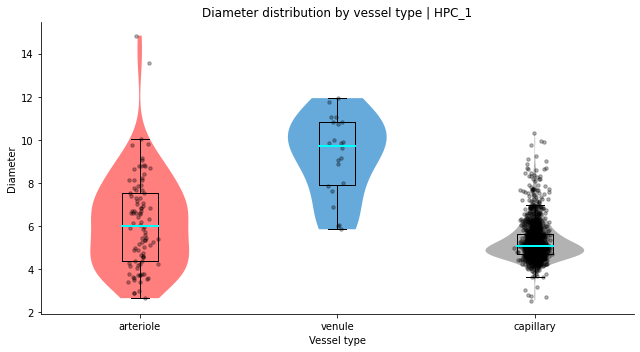

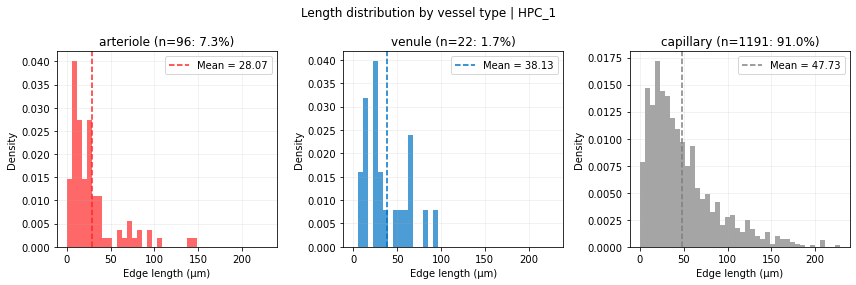

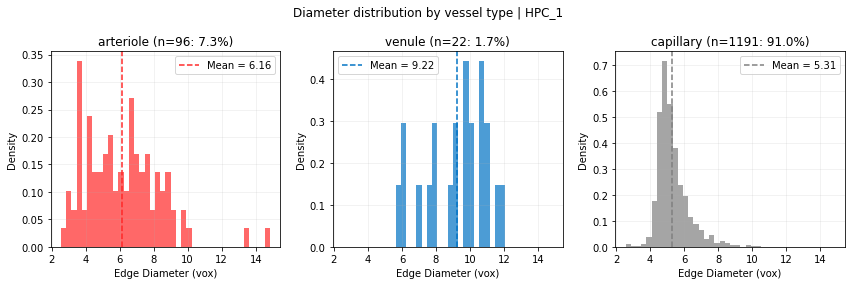


--- DEGREES ---

Unique degrees: [1 3 4 5 6]
HDN (>= 4): 66


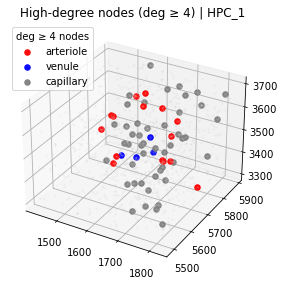


--- BC ANALYSIS ---



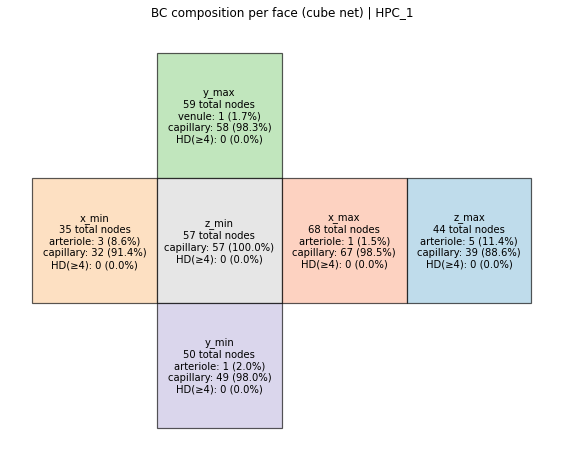

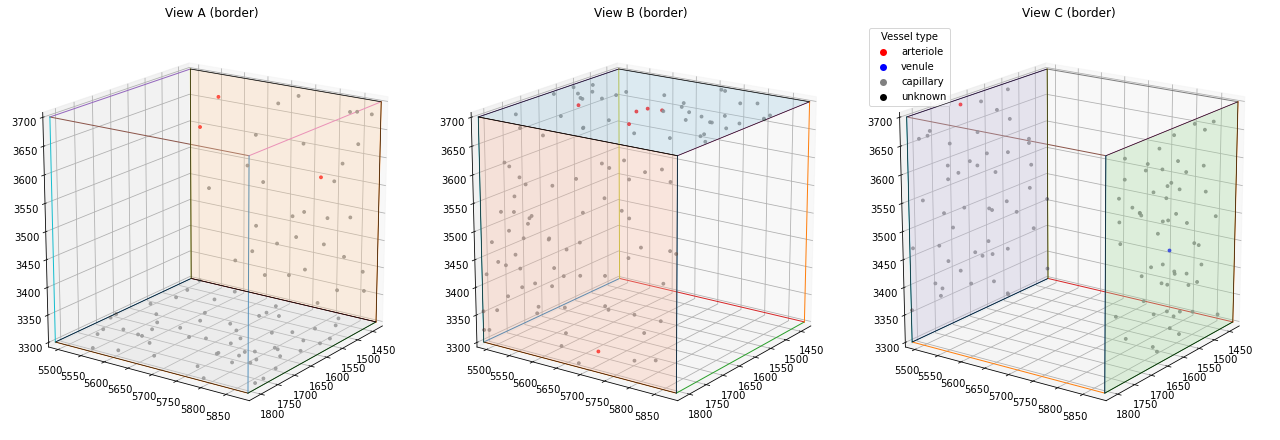


--- SATURATION INTERFACE PROXIES ---

{'arterial_nodes': 109, 'venous_nodes': 23, 'capillary_edges_attached_to_artery': 71, 'capillary_edges_attached_to_vein': 25, 'unique_capillary_nodes_touching_artery': 65, 'unique_capillary_nodes_touching_vein': 24, 'ac_frontier_nodes': 44, 'quick_upper_bound_interface': 24, 'graph': 'HPC_1'}

--- REDUNDANCY / SHORTEST PATHS ---

[HPC_1] A-C frontier nodes: 44
[HPC_1] venous nodes: 23
[HPC_1] paths found: 41
{'graph': 'HPC_1', 'A_AC_nodes': 44, 'V_nodes': 23, 'pairs_with_path': 41, 'all_frontiers_reached_a_vein': False, 'median_full_len_um': 330.36825942993164, 'median_trimmed_capillary_len_um': 330.36825942993164, 'median_removed_um': 0.0, 'median_removed_frac': 0.0}
n paths: 41
median full: 330.36825942993164
median trimmed: 330.36825942993164
median removed: 0.0
median removed frac: 0.0


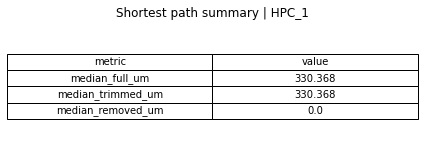

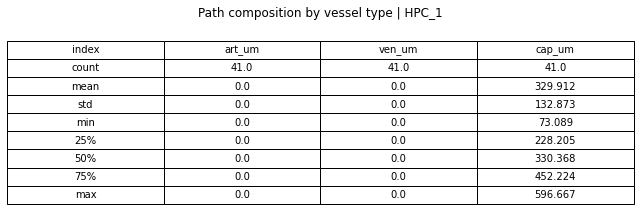


[COMPARISON SUMMARY]
{'graph': 'HPC_1', 'n_pairs': 41, 'n_target_changed': 0, 'pct_target_changed': 0.0, 'n_delta_um_nonzero': 0, 'pct_delta_um_nonzero': 0.0, 'n_delta_edges_nonzero': 0, 'pct_delta_edges_nonzero': 0.0, 'median_delta_um': 0.0, 'median_delta_edges': 0.0, 'n_weighted_paths_using_artery': 0, 'pct_weighted_paths_using_artery': 0.0, 'median_weighted_arterial_len_um': 0.0}

--- MIN CUT / MAX FLOW ---

{'graph': 'HPC_1', 'min_cut_value': 21.0, 'max_flow_value': 21.0, 'n_cut_edges_original_graph': 21, 'n_arterial_nodes_for_mincut': 109, 'n_venous_nodes_for_mincut': 23, 'min_cut_n_arteriole_edges': 0, 'min_cut_n_venule_edges': 0, 'min_cut_n_capillary_edges': 21, 'min_cut_n_unknown_edges': 0}

--- EDGE DISJOINT (secondary) ---

unique arterioles: 19
[HPC_1] edge-disjoint total = 21
[HPC_1] exported reconstructed paths = 21

--- VESSEL DENSITY ---

Number of boxes: 343
---- DENSITY CHECK ----
Global density box: 0.021218637794417367
Global length density box: 930.9763372915434
Me

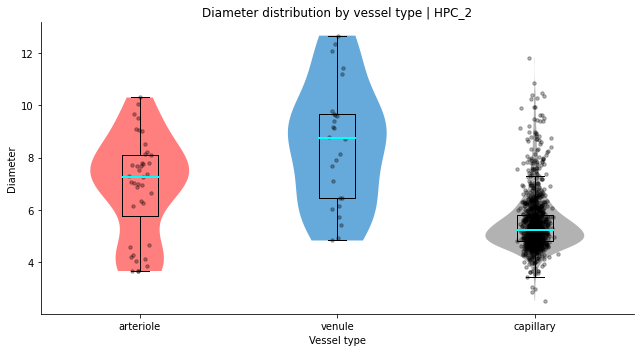

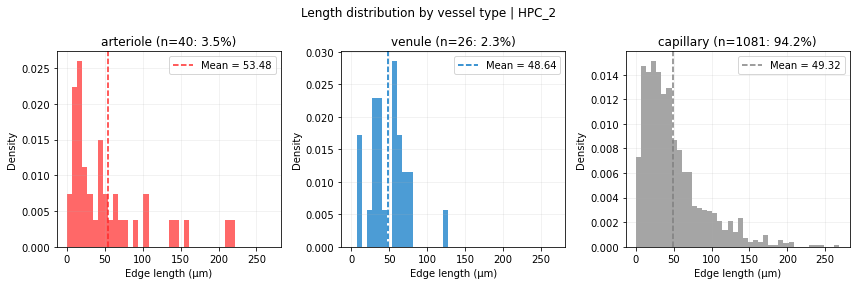

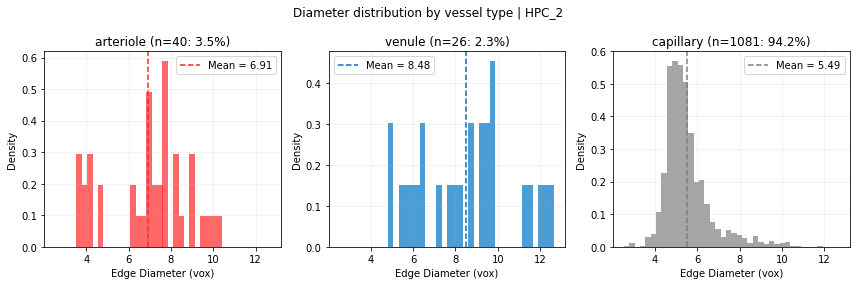


--- DEGREES ---

Unique degrees: [1 3 4 5 8]
HDN (>= 4): 54


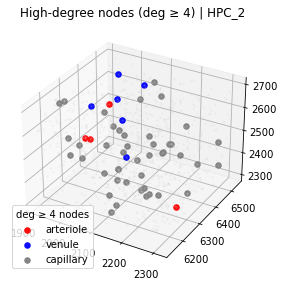


--- BC ANALYSIS ---



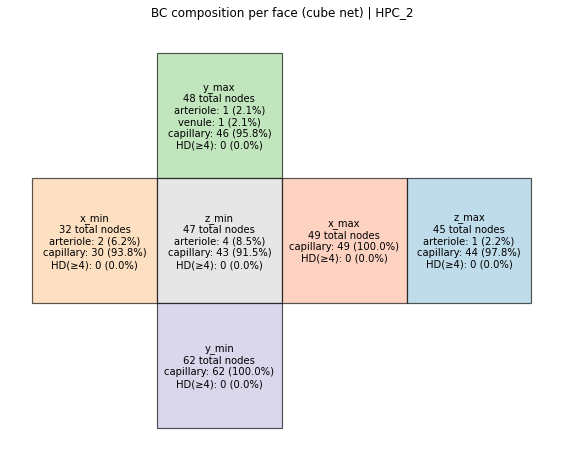

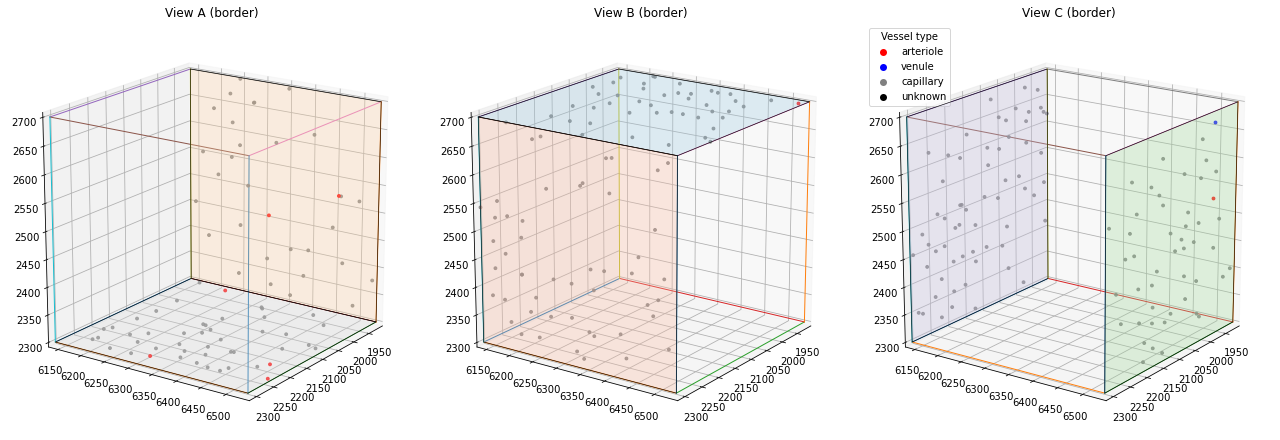


--- SATURATION INTERFACE PROXIES ---

{'arterial_nodes': 46, 'venous_nodes': 27, 'capillary_edges_attached_to_artery': 37, 'capillary_edges_attached_to_vein': 38, 'unique_capillary_nodes_touching_artery': 35, 'unique_capillary_nodes_touching_vein': 38, 'ac_frontier_nodes': 22, 'quick_upper_bound_interface': 35, 'graph': 'HPC_2'}

--- REDUNDANCY / SHORTEST PATHS ---

[HPC_2] A-C frontier nodes: 22
[HPC_2] venous nodes: 27
[HPC_2] paths found: 19
{'graph': 'HPC_2', 'A_AC_nodes': 22, 'V_nodes': 27, 'pairs_with_path': 19, 'all_frontiers_reached_a_vein': False, 'median_full_len_um': 241.90000867843628, 'median_trimmed_capillary_len_um': 241.90000867843628, 'median_removed_um': 0.0, 'median_removed_frac': 0.0}
n paths: 19
median full: 241.90000867843628
median trimmed: 241.90000867843628
median removed: 0.0
median removed frac: 0.0


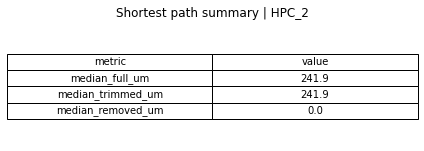

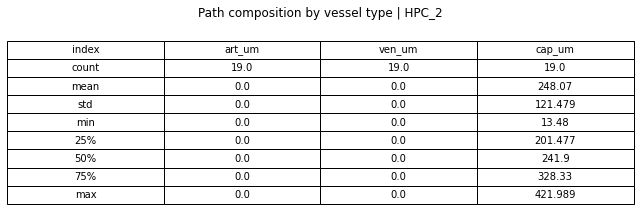


[COMPARISON SUMMARY]
{'graph': 'HPC_2', 'n_pairs': 19, 'n_target_changed': 0, 'pct_target_changed': 0.0, 'n_delta_um_nonzero': 0, 'pct_delta_um_nonzero': 0.0, 'n_delta_edges_nonzero': 0, 'pct_delta_edges_nonzero': 0.0, 'median_delta_um': 0.0, 'median_delta_edges': 0.0, 'n_weighted_paths_using_artery': 0, 'pct_weighted_paths_using_artery': 0.0, 'median_weighted_arterial_len_um': 0.0}

--- MIN CUT / MAX FLOW ---

{'graph': 'HPC_2', 'min_cut_value': 26.0, 'max_flow_value': 26.0, 'n_cut_edges_original_graph': 26, 'n_arterial_nodes_for_mincut': 46, 'n_venous_nodes_for_mincut': 27, 'min_cut_n_arteriole_edges': 0, 'min_cut_n_venule_edges': 0, 'min_cut_n_capillary_edges': 26, 'min_cut_n_unknown_edges': 0}

--- EDGE DISJOINT (secondary) ---

unique arterioles: 19
[HPC_2] edge-disjoint total = 26
[HPC_2] exported reconstructed paths = 26

--- VESSEL DENSITY ---

Number of boxes: 343
---- DENSITY CHECK ----
Global density box: 0.02125789311011265
Global length density box: 880.6336481033011
Mean

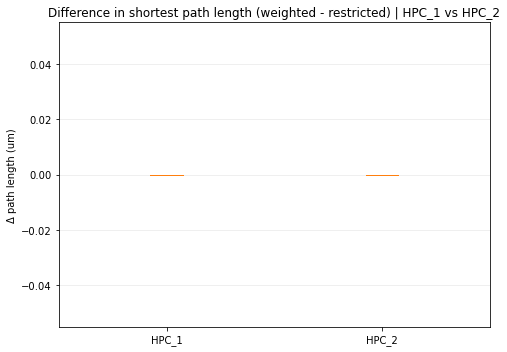

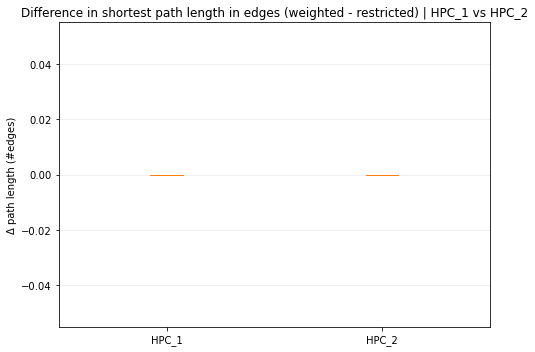

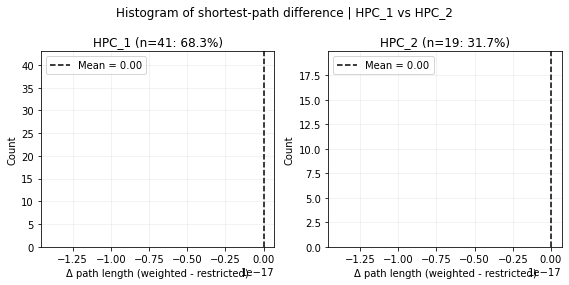


Paired comparison stats (restricted vs weighted)
   graph  n_pairs  mean_restricted  mean_weighted  median_restricted  \
0  HPC_1       41       329.912280     329.912280         330.368259   
1  HPC_2       19       248.069769     248.069769         241.900009   

   median_weighted  mean_delta_weighted_minus_restricted  \
0       330.368259                                   0.0   
1       241.900009                                   0.0   

   median_delta_weighted_minus_restricted  t_stat  p_value  
0                                     0.0     NaN      NaN  
1                                     0.0     NaN      NaN  


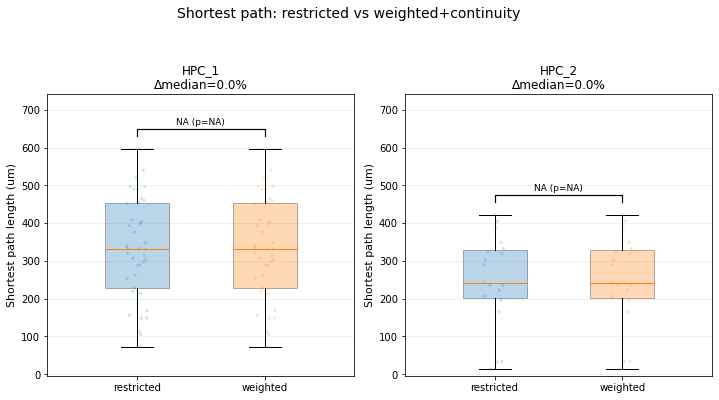

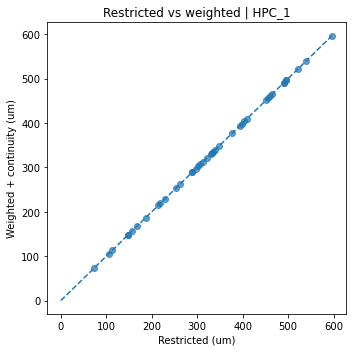

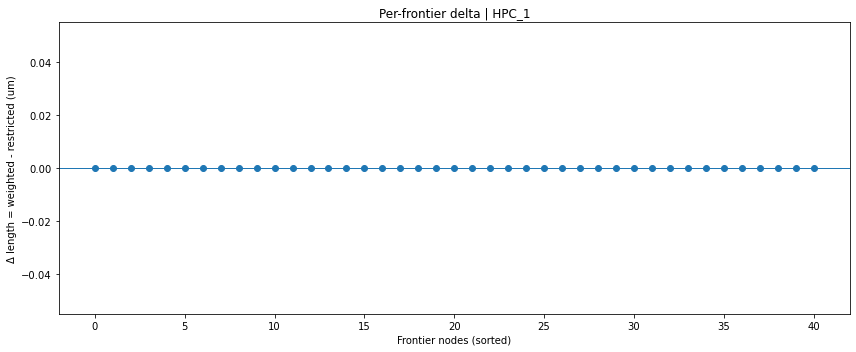

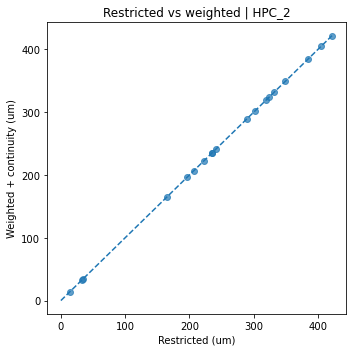

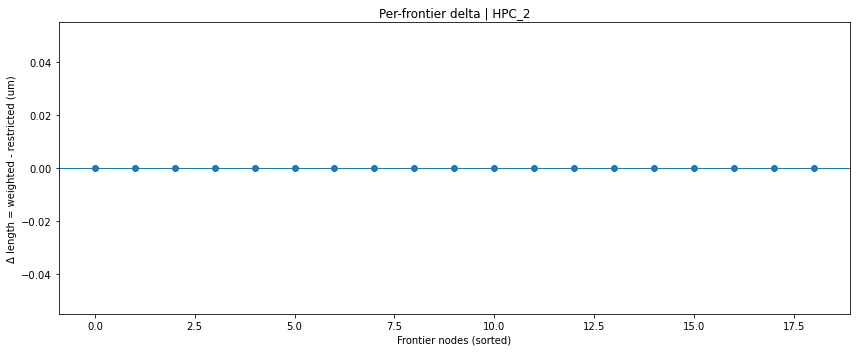

KeyError: 'n_delta_um_positive'

In [7]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import ttest_ind, ttest_rel

# ---------------------------------------------------------------------
# formatted analysis toolbox
# ---------------------------------------------------------------------
sys.path.insert(0, "/home/ana/MicroBrain/codes/Graph Analysis & by region/Graph analysis")
from graph_analysis_functions_formatted import *

# ---------------------------------------------------------------------
# local helpers
# ---------------------------------------------------------------------
ARTERY = 2
VEIN = 3
CAPILLARY = 4


def subset_ms_by_nkind(ms, nkind_code):
    m = np.asarray(ms["nkind"], dtype=int) == int(nkind_code)
    return {
        "midpoints": ms["midpoints"][m],
        "lengths": ms["lengths"][m],
        "nkind": ms["nkind"][m],
        "r0": ms["r0"][m],
        "r1": ms["r1"][m],
    }


def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]


def _nodes_of_edge_type(graph, edge_type_attr="nkind", labels=(2,)):
    labels = {int(x) for x in labels}
    nodes = set()
    for e in graph.es:
        if int(e[edge_type_attr]) in labels:
            u, v = e.tuple
            nodes.add(int(u))
            nodes.add(int(v))
    return nodes


def pairwise_ttests_table(df, value_col, graphs_order, group_col="graph"):
    rows = []
    present = [g for g in graphs_order if g in set(df[group_col].astype(str))]
    for g1, g2 in combinations(present, 2):
        x1 = _finite(df.loc[df[group_col] == g1, value_col].to_numpy(float))
        x2 = _finite(df.loc[df[group_col] == g2, value_col].to_numpy(float))

        if x1.size < 2 or x2.size < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_stat, p_val = ttest_ind(x1, x2, equal_var=False, nan_policy="omit")

        rows.append({
            "metric": value_col,
            "group1": g1,
            "group2": g2,
            "n1": int(x1.size),
            "n2": int(x2.size),
            "mean1": float(np.mean(x1)) if x1.size else np.nan,
            "mean2": float(np.mean(x2)) if x2.size else np.nan,
            "median1": float(np.median(x1)) if x1.size else np.nan,
            "median2": float(np.median(x2)) if x2.size else np.nan,
            "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
            "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        })
    return pd.DataFrame(rows)


def _p_to_text(p):
    if not np.isfinite(p):
        return "p=NA"
    if p < 1e-4:
        return "p<1e-4"
    return f"p={p:.3g}"


def _p_to_stars(p):
    if not np.isfinite(p):
        return "NA"
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


def add_pairwise_pvalues(ax, stats_df, positions, data_by_group):
    if stats_df is None or stats_df.empty:
        return

    valid_arrays = [np.asarray(v, float) for v in data_by_group.values() if len(v) > 0]
    if not valid_arrays:
        return

    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    if yr <= 0:
        yr = 1.0

    max_y = max(np.nanmax(v) for v in valid_arrays)
    n_pairs = len(stats_df)

    base = max_y + 0.05 * yr
    step = 0.10 * yr
    needed_top = base + (n_pairs + 1) * step

    if needed_top > ymax:
        ax.set_ylim(ymin, needed_top)
        ymin, ymax = ax.get_ylim()
        yr = ymax - ymin
        base = max_y + 0.05 * yr
        step = 0.08 * yr

    for i, row in enumerate(stats_df.itertuples(index=False)):
        g1, g2 = row.group1, row.group2
        if g1 not in positions or g2 not in positions:
            continue

        x1, x2 = positions[g1], positions[g2]
        if x1 > x2:
            x1, x2 = x2, x1

        y = base + i * step
        h = 0.025 * yr

        ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=1.2, c="black")
        ax.text(
            (x1 + x2) / 2.0,
            y + h + 0.01 * yr,
            f"{_p_to_stars(row.p_value)} ({_p_to_text(row.p_value)})",
            ha="center",
            va="bottom",
            fontsize=9,
            color="black"
        )


def add_jitter_scatter(ax, xpos, y, color="black", jitter=0.08, alpha=0.22, s=10, max_points=2000):
    y = _finite(y)
    if y.size == 0:
        return

    if y.size > max_points:
        rng = np.random.default_rng(0)
        y = rng.choice(y, size=max_points, replace=False)

    rng = np.random.default_rng(0)
    xj = xpos + rng.uniform(-jitter, jitter, size=y.size)

    ax.scatter(
        xj, y,
        s=s,
        alpha=alpha,
        color=color,
        edgecolors="none",
        zorder=2
    )


def delta_median_pct(medians):
    medians = _finite(medians)
    if medians.size < 2:
        return np.nan
    m = float(np.median(medians))
    return np.nan if abs(m) < 1e-12 else 100.0 * (float(np.max(medians)) - float(np.min(medians))) / m


def paired_ttest_restricted_vs_weighted(df, graphs_order, group_col="graph"):
    rows = []
    present = [g for g in graphs_order if g in set(df[group_col].astype(str))]

    for g in present:
        sub = df[df[group_col] == g].copy()
        sub = sub.dropna(subset=["path_len_restricted", "path_len_weighted"])

        x = _finite(sub["path_len_restricted"].to_numpy(float))
        y = _finite(sub["path_len_weighted"].to_numpy(float))

        n = min(len(x), len(y))
        x = x[:n]
        y = y[:n]

        if n < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_stat, p_val = ttest_rel(y, x, nan_policy="omit")

        rows.append({
            "graph": g,
            "n_pairs": int(n),
            "mean_restricted": float(np.mean(x)) if n else np.nan,
            "mean_weighted": float(np.mean(y)) if n else np.nan,
            "median_restricted": float(np.median(x)) if n else np.nan,
            "median_weighted": float(np.median(y)) if n else np.nan,
            "mean_delta_weighted_minus_restricted": float(np.mean(y - x)) if n else np.nan,
            "median_delta_weighted_minus_restricted": float(np.median(y - x)) if n else np.nan,
            "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
            "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        })

    return pd.DataFrame(rows)


def path_to_edge_ids(graph, path):
    eids = []
    for u, v in zip(path[:-1], path[1:]):
        eid = graph.get_eid(u, v, directed=False, error=False)
        if eid == -1:
            return []
        eids.append(eid)
    return eids


def path_edge_type_sequence(graph, path, edge_type_attr="nkind"):
    eids = path_to_edge_ids(graph, path)
    if len(eids) == 0:
        return np.array([], dtype=int)
    return np.asarray(graph.es[eids][edge_type_attr], dtype=int)


def arterial_length_in_path(graph, path, edge_type_attr="nkind", length_attr="length"):
    eids = path_to_edge_ids(graph, path)
    if len(eids) == 0:
        return np.nan
    nk = np.asarray(graph.es[eids][edge_type_attr], dtype=int)
    L = np.asarray(graph.es[eids][length_attr], dtype=float)
    return float(np.sum(L[nk == ARTERY]))


def build_allowed_subgraph(graph, artery_continuity=True, edge_type_attr="nkind"):
    if artery_continuity:
        keep_eids = list(range(graph.ecount()))
    else:
        keep_eids = [e.index for e in graph.es if int(e[edge_type_attr]) != ARTERY]
    subg = graph.subgraph_edges(keep_eids, delete_vertices=False)
    return subg


# ---------------------------------------------------------------------
# Saturation / interface proxies
# ---------------------------------------------------------------------
def saturation_interface_proxies(graph, edge_type_attr="nkind"):
    arterial_nodes = _nodes_of_edge_type(graph, edge_type_attr=edge_type_attr, labels=(ARTERY,))
    venous_nodes = _nodes_of_edge_type(graph, edge_type_attr=edge_type_attr, labels=(VEIN,))

    art_cap_eids = []
    ven_cap_eids = []

    art_cap_neighbors = set()
    ven_cap_neighbors = set()

    for e in graph.es:
        if int(e[edge_type_attr]) != CAPILLARY:
            continue

        u, v = map(int, e.tuple)

        if u in arterial_nodes or v in arterial_nodes:
            art_cap_eids.append(int(e.index))
            if u in arterial_nodes and v not in arterial_nodes:
                art_cap_neighbors.add(v)
            elif v in arterial_nodes and u not in arterial_nodes:
                art_cap_neighbors.add(u)

        if u in venous_nodes or v in venous_nodes:
            ven_cap_eids.append(int(e.index))
            if u in venous_nodes and v not in venous_nodes:
                ven_cap_neighbors.add(v)
            elif v in venous_nodes and u not in venous_nodes:
                ven_cap_neighbors.add(u)

    try:
        ac_frontier_nodes = get_ac_frontier_nodes(graph, edge_type_attr=edge_type_attr)
        n_ac_frontier = int(len(ac_frontier_nodes))
    except Exception:
        ac_frontier_nodes = sorted(list(art_cap_neighbors))
        n_ac_frontier = int(len(ac_frontier_nodes))

    quick_upper_bound = int(min(len(art_cap_neighbors), len(ven_cap_neighbors)))

    out = {
        "arterial_nodes": int(len(arterial_nodes)),
        "venous_nodes": int(len(venous_nodes)),
        "capillary_edges_attached_to_artery": int(len(art_cap_eids)),
        "capillary_edges_attached_to_vein": int(len(ven_cap_eids)),
        "unique_capillary_nodes_touching_artery": int(len(art_cap_neighbors)),
        "unique_capillary_nodes_touching_vein": int(len(ven_cap_neighbors)),
        "ac_frontier_nodes": int(n_ac_frontier),
        "quick_upper_bound_interface": quick_upper_bound,
    }
    return out


# ---------------------------------------------------------------------
# Min-cut as main connectivity metric
# ---------------------------------------------------------------------
def av_min_cut_metrics(
    graph,
    edge_type_attr="nkind",
    per_edge_capacity=1.0,
):
    """
    Min-cut / max-flow global entre lado arterial y venoso.

    Construye:
      super_source -> todos los arterial nodes
      todos los venous nodes -> super_sink

    Las edges originales tienen capacidad = per_edge_capacity.
    Las super-edges tienen capacidad muy alta para que el corte relevante
    ocurra dentro de la red original.
    """
    arterial_nodes = sorted(_nodes_of_edge_type(graph, edge_type_attr=edge_type_attr, labels=(ARTERY,)))
    venous_nodes = sorted(_nodes_of_edge_type(graph, edge_type_attr=edge_type_attr, labels=(VEIN,)))

    if len(arterial_nodes) == 0 or len(venous_nodes) == 0:
        return {
            "min_cut_value": np.nan,
            "max_flow_value": np.nan,
            "n_arterial_nodes": int(len(arterial_nodes)),
            "n_venous_nodes": int(len(venous_nodes)),
            "cut_edge_ids": [],
            "cut_edge_types": [],
            "n_cut_edges_original_graph": 0,
        }

    g2 = graph.copy()

    orig_n = g2.vcount()
    g2.add_vertices(2)
    super_source = orig_n
    super_sink = orig_n + 1

    big_cap = float(max(1, graph.ecount() + 1))

    extra_edges = []
    extra_caps = []
    extra_orig_eid = []

    # original edges
    if "tmp_capacity_mc" in g2.es.attributes():
        del g2.es["tmp_capacity_mc"]

    g2.es["tmp_capacity_mc"] = [float(per_edge_capacity)] * g2.ecount()
    g2.es["orig_eid_mc"] = list(range(graph.ecount()))

    # super edges source -> arterial
    for a in arterial_nodes:
        extra_edges.append((super_source, int(a)))
        extra_caps.append(big_cap)
        extra_orig_eid.append(-1)

    # venous -> sink
    for v in venous_nodes:
        extra_edges.append((int(v), super_sink))
        extra_caps.append(big_cap)
        extra_orig_eid.append(-1)

    if len(extra_edges) > 0:
        start_e = g2.ecount()
        g2.add_edges(extra_edges)
        new_eids = list(range(start_e, g2.ecount()))

        cap_all = list(g2.es["tmp_capacity_mc"])
        orig_all = list(g2.es["orig_eid_mc"])

        for eid, cap, oeid in zip(new_eids, extra_caps, extra_orig_eid):
            cap_all[eid] = float(cap)
            orig_all[eid] = int(oeid)

        g2.es["tmp_capacity_mc"] = cap_all
        g2.es["orig_eid_mc"] = orig_all

    mf = g2.maxflow(
        super_source,
        super_sink,
        capacity=g2.es["tmp_capacity_mc"]
    )

    cut_eids_aug = list(mf.cut)
    cut_orig_eids = []
    cut_edge_types = []

    for eid in cut_eids_aug:
        oeid = int(g2.es[eid]["orig_eid_mc"])
        if oeid >= 0:
            cut_orig_eids.append(oeid)
            cut_edge_types.append(int(graph.es[oeid][edge_type_attr]))

    return {
        "min_cut_value": float(mf.value),
        "max_flow_value": float(mf.value),
        "n_arterial_nodes": int(len(arterial_nodes)),
        "n_venous_nodes": int(len(venous_nodes)),
        "cut_edge_ids": cut_orig_eids,
        "cut_edge_types": cut_edge_types,
        "n_cut_edges_original_graph": int(len(cut_orig_eids)),
    }


def cut_type_counts(cut_edge_types):
    arr = np.asarray(cut_edge_types, dtype=int)
    return {
        "min_cut_n_arteriole_edges": int(np.sum(arr == ARTERY)),
        "min_cut_n_venule_edges": int(np.sum(arr == VEIN)),
        "min_cut_n_capillary_edges": int(np.sum(arr == CAPILLARY)),
        "min_cut_n_unknown_edges": int(np.sum(~np.isin(arr, [ARTERY, VEIN, CAPILLARY]))),
    }


# ---------------------------------------------------------------------
# Path comparisons
# ---------------------------------------------------------------------
def compare_frontier_modes_detailed(
    graph,
    edge_type_attr="nkind",
    weight_attr="length",
    tie_break_edges=True,
    tol=1e-9,
):
    """
    Compara shortest paths desde cada A/C frontier en dos modos:
      - artery_continuity=True
      - artery_continuity=False

    usando el mismo weight_attr en ambos casos.
    """

    (
        paths_yes,
        dist_yes,
        n_edges_yes,
        src_yes,
        tgt_yes,
        A_valid_yes,
        V_valid_yes,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=True,
        edge_type_attr=edge_type_attr,
        weight_attr=weight_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    (
        paths_no,
        dist_no,
        n_edges_no,
        src_no,
        tgt_no,
        A_valid_no,
        V_valid_no,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=False,
        edge_type_attr=edge_type_attr,
        weight_attr=weight_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    by_frontier_yes = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(paths_yes, dist_yes, n_edges_yes, src_yes, tgt_yes)
    }

    by_frontier_no = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(paths_no, dist_no, n_edges_no, src_no, tgt_no)
    }

    all_frontiers = sorted(set(by_frontier_yes) | set(by_frontier_no))
    rows = []

    for f in all_frontiers:
        ry = by_frontier_yes.get(f)
        rn = by_frontier_no.get(f)

        path_yes = None if ry is None else ry["path"]
        seq_yes = np.array([], dtype=int) if path_yes is None else path_edge_type_sequence(graph, path_yes)

        rows.append({
            "source_frontier": int(f),

            "has_with_artery": ry is not None,
            "has_without_artery": rn is not None,

            "target_with_artery": np.nan if ry is None else ry["target"],
            "target_without_artery": np.nan if rn is None else rn["target"],

            "same_target_venous": (
                np.nan if (ry is None or rn is None)
                else bool(ry["target"] == rn["target"])
            ),

            "path_len_with_artery": np.nan if ry is None else ry["dist_um"],
            "path_len_without_artery": np.nan if rn is None else rn["dist_um"],
            "delta_no_minus_yes": (
                np.nan if (ry is None or rn is None)
                else rn["dist_um"] - ry["dist_um"]
            ),

            "path_len_with_artery_edges": np.nan if ry is None else ry["n_edges"],
            "path_len_without_artery_edges": np.nan if rn is None else rn["n_edges"],
            "delta_edges_no_minus_yes": (
                np.nan if (ry is None or rn is None)
                else rn["n_edges"] - ry["n_edges"]
            ),

            "uses_artery_with_artery": bool(np.any(seq_yes == ARTERY)) if len(seq_yes) else False,
            "arterial_len_with_artery_um": np.nan if path_yes is None else arterial_length_in_path(graph, path_yes),
            "arterial_edges_with_artery": int(np.sum(seq_yes == ARTERY)) if len(seq_yes) else 0,
        })

    return pd.DataFrame(rows)


def compare_frontier_restricted_vs_weighted(
    graph,
    edge_type_attr="nkind",
    length_weight_attr="length",
    weighted_attr="w_cap_prior",
    tie_break_edges=True,
    tol=1e-9,
):
    """
    Compara dos estrategias de shortest path desde cada A/C frontier:

    1) restricted:
       artery_continuity=False, weight_attr=length

    2) weighted:
       artery_continuity=True, weight_attr=weighted_attr
    """

    (
        paths_restricted,
        dist_restricted,
        n_edges_restricted,
        src_restricted,
        tgt_restricted,
        A_valid_restricted,
        V_valid_restricted,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=False,
        edge_type_attr=edge_type_attr,
        weight_attr=length_weight_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    (
        paths_weighted,
        dist_weighted,
        n_edges_weighted,
        src_weighted,
        tgt_weighted,
        A_valid_weighted,
        V_valid_weighted,
    ) = shortest_av_paths_from_ac_frontier(
        graph,
        artery_continuity=True,
        edge_type_attr=edge_type_attr,
        weight_attr=weighted_attr,
        tie_break_edges=tie_break_edges,
        tol=tol,
    )

    by_frontier_restricted = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(
            paths_restricted, dist_restricted, n_edges_restricted, src_restricted, tgt_restricted
        )
    }

    by_frontier_weighted = {
        int(a): {
            "path": p,
            "dist_um": float(d),
            "n_edges": int(ne),
            "target": int(v),
        }
        for p, d, ne, a, v in zip(
            paths_weighted, dist_weighted, n_edges_weighted, src_weighted, tgt_weighted
        )
    }

    all_frontiers = sorted(set(by_frontier_restricted) | set(by_frontier_weighted))
    rows = []

    for f in all_frontiers:
        rr = by_frontier_restricted.get(f)
        rw = by_frontier_weighted.get(f)

        path_w = None if rw is None else rw["path"]
        seq_w = np.array([], dtype=int) if path_w is None else path_edge_type_sequence(graph, path_w)

        rows.append({
            "source_frontier": int(f),

            "has_restricted": rr is not None,
            "has_weighted": rw is not None,

            "target_restricted": np.nan if rr is None else rr["target"],
            "target_weighted": np.nan if rw is None else rw["target"],

            "same_target_venous": (
                np.nan if (rr is None or rw is None)
                else bool(rr["target"] == rw["target"])
            ),

            "path_len_restricted": np.nan if rr is None else rr["dist_um"],
            "path_len_weighted": np.nan if rw is None else rw["dist_um"],
            "delta_weighted_minus_restricted": (
                np.nan if (rr is None or rw is None)
                else rw["dist_um"] - rr["dist_um"]
            ),

            "path_len_restricted_edges": np.nan if rr is None else rr["n_edges"],
            "path_len_weighted_edges": np.nan if rw is None else rw["n_edges"],
            "delta_edges_weighted_minus_restricted": (
                np.nan if (rr is None or rw is None)
                else rw["n_edges"] - rr["n_edges"]
            ),

            "weighted_uses_artery": bool(np.any(seq_w == ARTERY)) if len(seq_w) else False,
            "weighted_arterial_len_um": np.nan if path_w is None else arterial_length_in_path(graph, path_w),
            "weighted_arterial_edges": int(np.sum(seq_w == ARTERY)) if len(seq_w) else 0,
        })

    return pd.DataFrame(rows)


def summarize_frontier_comparison(df_cmp_local, graph_name):
    ss = df_cmp_local.dropna(subset=["path_len_restricted", "path_len_weighted"]).copy()

    if ss.empty:
        return {
            "graph": graph_name,
            "n_pairs": 0,
            "n_target_changed": 0,
            "pct_target_changed": np.nan,
            "n_delta_um_nonzero": 0,
            "pct_delta_um_nonzero": np.nan,
            "n_delta_edges_nonzero": 0,
            "pct_delta_edges_nonzero": np.nan,
            "median_delta_um": np.nan,
            "median_delta_edges": np.nan,
            "n_weighted_paths_using_artery": 0,
            "pct_weighted_paths_using_artery": np.nan,
            "median_weighted_arterial_len_um": np.nan,
        }

    target_changed = (ss["same_target_venous"] == False)
    delta_um_nonzero = ~np.isclose(ss["delta_weighted_minus_restricted"].to_numpy(float), 0.0, atol=1e-9)
    delta_edges_nonzero = ~np.isclose(ss["delta_edges_weighted_minus_restricted"].to_numpy(float), 0.0, atol=1e-9)
    uses_artery = ss["weighted_uses_artery"] == True

    return {
        "graph": graph_name,
        "n_pairs": int(len(ss)),
        "n_target_changed": int(np.sum(target_changed)),
        "pct_target_changed": 100.0 * float(np.mean(target_changed)),
        "n_delta_um_nonzero": int(np.sum(delta_um_nonzero)),
        "pct_delta_um_nonzero": 100.0 * float(np.mean(delta_um_nonzero)),
        "n_delta_edges_nonzero": int(np.sum(delta_edges_nonzero)),
        "pct_delta_edges_nonzero": 100.0 * float(np.mean(delta_edges_nonzero)),
        "median_delta_um": float(np.nanmedian(ss["delta_weighted_minus_restricted"])),
        "median_delta_edges": float(np.nanmedian(ss["delta_edges_weighted_minus_restricted"])),
        "n_weighted_paths_using_artery": int(np.sum(uses_artery)),
        "pct_weighted_paths_using_artery": 100.0 * float(np.mean(uses_artery)),
        "median_weighted_arterial_len_um": float(np.nanmedian(ss["weighted_arterial_len_um"])),
    }


def plot_restricted_vs_weighted_scatter(df_comparison, graph_name, figsize=(5, 5)):
    sub = df_comparison[df_comparison["graph"] == graph_name].copy()
    sub = sub.dropna(subset=["path_len_restricted", "path_len_weighted"])

    x = sub["path_len_restricted"].to_numpy(float)
    y = sub["path_len_weighted"].to_numpy(float)

    if len(sub) == 0:
        print(f"No paired data for {graph_name}")
        return

    plt.figure(figsize=figsize)
    plt.scatter(x, y, alpha=0.7)

    mx = max(np.max(x), np.max(y)) if len(x) else 1.0
    plt.plot([0, mx], [0, mx], "--")

    plt.xlabel("Restricted (um)")
    plt.ylabel("Weighted + continuity (um)")
    plt.title(f"Restricted vs weighted | {graph_name}")
    plt.tight_layout()
    plt.show()


def plot_frontier_path_differences(df_comparison, graph_name, figsize=(12, 5)):
    sub = df_comparison[df_comparison["graph"] == graph_name].copy()
    sub = sub.dropna(subset=["delta_weighted_minus_restricted"])
    sub = sub.sort_values("delta_weighted_minus_restricted").reset_index(drop=True)

    if len(sub) == 0:
        print(f"No delta data for {graph_name}")
        return

    x = np.arange(len(sub))
    y = sub["delta_weighted_minus_restricted"].to_numpy(float)
    changed = sub["same_target_venous"] == False

    plt.figure(figsize=figsize)
    plt.plot(x, y, marker="o", linewidth=1)
    plt.axhline(0, linewidth=1)

    if np.any(changed):
        plt.scatter(
            x[changed.to_numpy()],
            y[changed.to_numpy()],
            marker="x",
            s=60,
            label="target venous changed"
        )
        plt.legend()

    plt.xlabel("Frontier nodes (sorted)")
    plt.ylabel("Δ length = weighted - restricted (um)")
    plt.title(f"Per-frontier delta | {graph_name}")
    plt.tight_layout()
    plt.show()


def plot_paired_restricted_vs_weighted_boxplots_from_comparison(
    df_comparison,
    graphs_order,
    ylabel="Shortest path length (um)",
    title=None,
    sharey=True,
):
    present = [g for g in graphs_order if g in set(df_comparison["graph"].astype(str))]
    if len(present) == 0:
        print("No graphs found.")
        return pd.DataFrame()

    all_y = []
    for g in present:
        sub = df_comparison[df_comparison["graph"] == g].copy()
        sub = sub.dropna(subset=["path_len_restricted", "path_len_weighted"])

        x_r = _finite(sub["path_len_restricted"].to_numpy(float))
        x_w = _finite(sub["path_len_weighted"].to_numpy(float))

        if x_r.size:
            all_y.append(x_r)
        if x_w.size:
            all_y.append(x_w)

    if len(all_y) == 0:
        print("No paired values found.")
        return pd.DataFrame()

    all_y = np.concatenate(all_y)
    global_ymin_data = float(np.nanmin(all_y))
    global_ymax_data = float(np.nanmax(all_y))
    yr = global_ymax_data - global_ymin_data
    if not np.isfinite(yr) or yr <= 0:
        yr = 1.0

    common_ymin = global_ymin_data - 0.03 * yr

    fig, axes = plt.subplots(
        1, len(present),
        figsize=(5.2 * len(present), 5.8),
        sharey=sharey
    )
    if len(present) == 1:
        axes = [axes]

    stats_out = []

    for ax, g in zip(axes, present):
        sub = df_comparison[df_comparison["graph"] == g].copy()
        sub = sub.dropna(subset=["path_len_restricted", "path_len_weighted"])

        x_r = _finite(sub["path_len_restricted"].to_numpy(float))
        x_w = _finite(sub["path_len_weighted"].to_numpy(float))

        n = min(len(x_r), len(x_w))
        x_r = x_r[:n]
        x_w = x_w[:n]

        if n == 0:
            ax.set_axis_off()
            continue

        bp = ax.boxplot(
            [x_r, x_w],
            labels=["restricted", "weighted"],
            showfliers=False,
            patch_artist=True,
            widths=0.5
        )

        bp["boxes"][0].set_facecolor("tab:blue")
        bp["boxes"][0].set_alpha(0.30)
        bp["boxes"][1].set_facecolor("tab:orange")
        bp["boxes"][1].set_alpha(0.30)

        add_jitter_scatter(ax, 1, x_r, color="tab:blue")
        add_jitter_scatter(ax, 2, x_w, color="tab:orange")

        if n < 2:
            t_stat, p_val = np.nan, np.nan
        else:
            t_stat, p_val = ttest_rel(x_w, x_r, nan_policy="omit")

        st = pd.DataFrame([{
            "group1": "restricted",
            "group2": "weighted",
            "p_value": p_val,
        }])

        add_pairwise_pvalues(
            ax,
            st,
            positions={"restricted": 1, "weighted": 2},
            data_by_group={
                "restricted": x_r,
                "weighted": x_w,
            }
        )

        dm = delta_median_pct(np.array([np.median(x_r), np.median(x_w)], float))
        ax.set_title(f"{g}\nΔmedian={dm:.1f}%", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.grid(alpha=0.25, axis="y")
        ax.tick_params(axis="x", labelsize=10)
        ax.tick_params(axis="y", labelsize=10, labelleft=True)
        ax.set_xlim(0.3, 2.7)

        stats_out.append({
            "graph": g,
            "n_pairs": int(n),
            "mean_restricted": float(np.mean(x_r)),
            "mean_weighted": float(np.mean(x_w)),
            "median_restricted": float(np.median(x_r)),
            "median_weighted": float(np.median(x_w)),
            "mean_delta_weighted_minus_restricted": float(np.mean(x_w - x_r)),
            "median_delta_weighted_minus_restricted": float(np.median(x_w - x_r)),
            "t_stat": float(t_stat) if np.isfinite(t_stat) else np.nan,
            "p_value": float(p_val) if np.isfinite(p_val) else np.nan,
        })

    ymaxs = []
    for ax in axes:
        if ax.axison:
            ymaxs.append(ax.get_ylim()[1])

    common_ymax = max(ymaxs) if ymaxs else (global_ymax_data + 0.10 * yr)

    for ax in axes:
        if ax.axison:
            ax.set_ylim(common_ymin, common_ymax)

    if title is not None:
        fig.suptitle(title, fontsize=14)
        plt.tight_layout(rect=[0.03, 0.03, 1, 0.93])
    else:
        plt.tight_layout(rect=[0.03, 0.03, 1, 1])

    plt.show()

    return pd.DataFrame(stats_out)


# ---------------------------------------------------------------------
# paths / params
# ---------------------------------------------------------------------
out_root = "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED"
os.makedirs(out_root, exist_ok=True)

PATHS = {
    "HPC_1": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut1.pkl",
    "HPC_2": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut2.pkl",
    # "HPC_3": "/home/admin/Ana/MicroBrain/output/um_gaia/formatted/formatted2/graph_18_OutGeom_um_formatted_Hcut3.pkl",
}

HIPPO_CENTERS = {
    "HPC_1": [1000, 3500, 1400],
    "HPC_2": [1300, 3900, 1000],
    "HPC_3": [2100, 4200, 750],
}

box_size_um = (400, 400, 400)
degree_thr = 4
eps_vox = 2.0
slab_um_cutbox = 10.0
slab_axis = "z"
bins_hist = 40

BOX_ORDER = list(PATHS.keys())
BOX_LABEL = " vs ".join(BOX_ORDER)

VESSEL_COL = {
    "arteriole": "#d62728",
    "venule": "#1f77b4",
    "capillary": "#7f7f7f",
    "unknown": "#c7c7c7",
}

BOX_COL = {
    "HPC_1": "tab:blue",
    "HPC_2": "tab:orange",
    "HPC_3": "tab:green",
}

# ---------------------------------------------------------------------
# safety check for res_um_per_vox
# ---------------------------------------------------------------------
try:
    res_um_per_vox
except NameError:
    res_um_per_vox = 1.0
    print("[WARNING] res_um_per_vox was not defined. Using res_um_per_vox = 1.0")

# ---------------------------------------------------------------------
# COLLECTORS (global across all boxes)
# ---------------------------------------------------------------------
all_summaries = []
diam_length_global_boxes = []
av_path_size_rows = []
av_rows = []
bc_rows = []
hdn_nodes_rows = []

# principal connectivity metrics
mincut_rows = []
redundancy_rows = []

comparison_detailed_rows = []
comparison_summary_rows = []

density_boxes_rows = []
graph_density_rows = []
bc_long_rows = []
trimmed_rows = []

# new saturation/interface collectors
saturation_rows = []

# ---------------------------------------------------------------------
# analysis loop (per box / per graph)
# ---------------------------------------------------------------------
for name, path in PATHS.items():
    center = HIPPO_CENTERS[name]

    print("\n======================")
    print("Analyzing:", name)
    print("======================\n")
    print("path:", path)

    g = load_graph(path)
    G = keep_giant_component(g)

    print("\n- Graph sanity check\n")
    g_unit = G["unit"] if ("unit" in G.attributes()) else "unknown"
    d_unit = G["diameter_unit"] if ("diameter_unit" in G.attributes()) else "unknown"
    print(f"[{name}] units: coords/length={g_unit} | diameter={d_unit}")

    cut_box = make_box_in_um(center, box_size_um, res_um_per_vox=res_um_per_vox)
    validate_box_faces(cut_box)

    print(
        "BOX bounds:\n"
        f"  x: [{cut_box['xmin']:.6f}, {cut_box['xmax']:.6f}]  (size={cut_box['xmax'] - cut_box['xmin']:.6f})\n"
        f"  y: [{cut_box['ymin']:.6f}, {cut_box['ymax']:.6f}]  (size={cut_box['ymax'] - cut_box['ymin']:.6f})\n"
        f"  z: [{cut_box['zmin']:.6f}, {cut_box['zmax']:.6f}]  (size={cut_box['zmax'] - cut_box['zmin']:.6f})\n"
    )

    # weighted artificial penalizing artery and vein heavily
    add_penalization_weights(
        G,
        new_weight_attr="w_cap_prior",
        edge_type_attr="nkind",
        length_attr="length",
        penalty_art=1e5,
        penalty_ven=1e5,
    )

    # -----------------------------------------------------------------
    # Basic stats
    # -----------------------------------------------------------------
    dup = duplicated_edge_stats(G)
    loops = loop_edge_stats(G)
    print("- Duplicated edges:", dup)
    print("- Loops:", loops)

    # -----------------------------------------------------------------
    # Lengths / diameters by type
    # -----------------------------------------------------------------
    avg_len_dict = get_avg_length_nkind(G)
    avg_len_by_type = {
        EDGE_NKIND_TO_LABEL.get(int(k), str(k)): float(v)
        for k, v in avg_len_dict.items()
    }

    diam_stats = diameter_stats_nkind(
        G,
        label_dict=EDGE_NKIND_TO_LABEL,
        plot=True,
        title_suffix=name
    )

    e_diam = np.asarray(G.es["diameter"], float)
    e_leng = np.asarray(G.es["length"], float)
    nk = np.asarray(G.es["nkind"], int)

    etype_counts = edge_type_counts(nk, EDGE_NKIND_TO_LABEL)
    E_arteriole = int(etype_counts["arteriole"])
    E_venule = int(etype_counts["venule"])
    E_capillary = int(etype_counts["capillary"])
    E_unknown = int(etype_counts["unknown"])

    for k in np.unique(nk):
        lab = EDGE_NKIND_TO_LABEL.get(int(k), str(k))
        m = (nk == k)
        if np.any(m):
            diam_length_global_boxes.append(pd.DataFrame({
                "graph": name,
                "type": str(lab),
                "diameter_vox": e_diam[m],
                "length_um": e_leng[m],
            }))

    plot_hist_by_category_general(
        values=e_leng,
        category=nk,
        label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist,
        layout="horizontal",
        density=True,
        show_mean=True,
        variable_name="Edge length (µm)",
        category_name="Vessel type",
        main_title=f"Length distribution by vessel type | {name}"
    )

    plot_hist_by_category_general(
        values=e_diam,
        category=nk,
        label_dict=EDGE_NKIND_TO_LABEL,
        bins=bins_hist,
        layout="horizontal",
        density=True,
        show_mean=True,
        variable_name="Edge Diameter (vox)",
        category_name="Vessel type",
        main_title=f"Diameter distribution by vessel type | {name}"
    )

    # -----------------------------------------------------------------
    # Degrees / HDN
    # -----------------------------------------------------------------
    print("\n--- DEGREES ---\n")
    get_degrees(G, threshold=degree_thr)

    hdn = analyze_hdn_pattern_in_box(
        G,
        box=cut_box,
        coords_attr="coords",
        space="um",
        degree_thr=degree_thr,
        eps_vox=eps_vox
    )

    deg = np.asarray(G.degree(), int)
    hdn_nodes = np.where(deg >= degree_thr)[0]
    coords = np.asarray(G.vs["coords"], float)

    for v in hdn_nodes:
        t = infer_node_type_from_incident_edges(G, int(v))
        x, y, z = coords[int(v)]
        hdn_nodes_rows.append({
            "graph": name,
            "v": int(v),
            "x": float(x),
            "y": float(y),
            "z": float(z),
            "degree": int(deg[int(v)]),
            "type": t
        })

    plot_degree_nodes_spatial(
        G,
        coords_attr="coords",
        degree_min=degree_thr,
        degree_max=None,
        by_type=True,
        title=f"High-degree nodes (deg ≥ {degree_thr}) | {name}"
    )

    # -----------------------------------------------------------------
    # BC analysis
    # -----------------------------------------------------------------
    print("\n--- BC ANALYSIS ---\n")

    bc = analyze_bc_faces(
        G,
        cut_box,
        coords_attr="coords",
        space="um",
        eps_vox=eps_vox,
        degree_thr=degree_thr,
        mode="border",
        diam_attr="diameter",
        return_diameter_values=True,
    )

    bc_long_df = bc_diameter_longtable(bc, box_name=name).copy()
    bc_long_df["graph"] = name
    bc_long_rows.append(bc_long_df)

    bc_df = bc_faces_table(bc, box_name=name).copy()
    bc_df["graph"] = name
    bc_rows.append(bc_df)

    plot_bc_cube_net(bc, title=f"BC composition per face (cube net) | {name}")
    plot_bc_3_cubes_tinted(
        G,
        cut_box,
        coords_attr="coords",
        space="um",
        eps_vox=eps_vox,
        mode="border"
    )

    # -----------------------------------------------------------------
    # Saturation / interface proxies
    # -----------------------------------------------------------------
    print("\n--- SATURATION INTERFACE PROXIES ---\n")
    sat = saturation_interface_proxies(G, edge_type_attr="nkind")
    sat["graph"] = name
    saturation_rows.append(sat)
    print(sat)

    # -----------------------------------------------------------------
    # Shortest paths (official restricted mode)
    # -----------------------------------------------------------------
    print("\n--- REDUNDANCY / SHORTEST PATHS ---\n")

    shortest_paths_noA, dist_no, path_n_edges, source_frontiers, target_venous, A, V = \
        shortest_av_paths_from_ac_frontier(
            G,
            artery_continuity=False,
            edge_type_attr="nkind",
            weight_attr="length",
            tie_break_edges=True,
            tol=1e-6,
        )

    print(f"[{name}] A-C frontier nodes: {len(A)}")
    print(f"[{name}] venous nodes: {len(V)}")
    print(f"[{name}] paths found: {len(shortest_paths_noA)}")

    for p, d, a, v in zip(shortest_paths_noA, dist_no, source_frontiers, target_venous):
        av_path_size_rows.append({
            "graph": name,
            "source_frontier": int(a),
            "target_venous": int(v),
            "path_len_edges": int(len(p) - 1),
            "path_len_um": float(d),
        })

    rows_trimmed = []
    for p in shortest_paths_noA:
        full_eids = path_to_edge_ids(G, p)
        full_len = float(np.sum(np.asarray(G.es[full_eids]["length"], float))) if len(full_eids) else np.nan
        trimmed_len = float(trimmed_capillary_length(G, p))

        removed_um = full_len - trimmed_len if np.isfinite(full_len) and np.isfinite(trimmed_len) else np.nan
        removed_frac = removed_um / full_len if np.isfinite(removed_um) and np.isfinite(full_len) and full_len > 0 else np.nan

        rows_trimmed.append({
            "graph": name,
            "full_len_um": full_len,
            "trimmed_capillary_len_um": trimmed_len,
            "removed_um": removed_um,
            "removed_frac": removed_frac,
            "n_edges_full": int(len(p) - 1),
        })

    df_trimmed = pd.DataFrame(rows_trimmed)

    for _, r in df_trimmed.iterrows():
        trimmed_rows.append({
            "graph": name,
            "full_len_um": float(r["full_len_um"]),
            "trimmed_capillary_len_um": float(r["trimmed_capillary_len_um"]),
            "removed_um": float(r["removed_um"]),
            "removed_frac": float(r["removed_frac"]) if np.isfinite(r["removed_frac"]) else np.nan,
            "n_edges_full": int(r["n_edges_full"]),
        })

    av_stats = {
        "graph": name,
        "A_AC_nodes": int(len(A)),
        "V_nodes": int(len(V)),
        "pairs_with_path": int(len(shortest_paths_noA)),
        "all_frontiers_reached_a_vein": bool(len(shortest_paths_noA) == len(A)),
        "median_full_len_um": float(np.nanmedian(df_trimmed["full_len_um"])) if not df_trimmed.empty else np.nan,
        "median_trimmed_capillary_len_um": float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])) if not df_trimmed.empty else np.nan,
        "median_removed_um": float(np.nanmedian(df_trimmed["removed_um"])) if not df_trimmed.empty else np.nan,
        "median_removed_frac": float(np.nanmedian(df_trimmed["removed_frac"])) if not df_trimmed.empty else np.nan,
    }

    av_rows.append(av_stats)
    print(av_stats)

    if len(shortest_paths_noA) > 0:
        export_paths_vtp(
            G,
            shortest_paths_noA,
            os.path.join(out_root, f"{name}_shortest_paths_AC_to_nearest_vein.vtp")
        )

        print("n paths:", len(shortest_paths_noA))
        print("median full:", np.nanmedian(df_trimmed["full_len_um"]))
        print("median trimmed:", np.nanmedian(df_trimmed["trimmed_capillary_len_um"]))
        print("median removed:", np.nanmedian(df_trimmed["removed_um"]))
        print("median removed frac:", np.nanmedian(df_trimmed["removed_frac"]))

        df_trimmed.to_csv(
            os.path.join(out_root, f"{name}_trimmed_shortest_paths.csv"),
            index=False
        )

    summary_trimmed = pd.DataFrame({
        "metric": ["median_full_um", "median_trimmed_um", "median_removed_um"],
        "value": [
            float(np.nanmedian(df_trimmed["full_len_um"])) if not df_trimmed.empty else np.nan,
            float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])) if not df_trimmed.empty else np.nan,
            float(np.nanmedian(df_trimmed["removed_um"])) if not df_trimmed.empty else np.nan,
        ]
    })

    dataframe_to_table_figure(
        summary_trimmed,
        title=f"Shortest path summary | {name}",
        figsize=(6, 2.2)
    )

    diag_rows = []
    for p in shortest_paths_noA:
        diag_rows.append(removed_by_type(G, p))

    df_diag = pd.DataFrame(diag_rows)
    diag_summary = df_diag.describe().reset_index()

    dataframe_to_table_figure(
        diag_summary,
        title=f"Path composition by vessel type | {name}",
        figsize=(9, 3.2)
    )

    # -----------------------------------------------------------------
    # Comparison: restricted vs weighted artificial
    # -----------------------------------------------------------------
    df_cmp_local = compare_frontier_restricted_vs_weighted(
        G,
        edge_type_attr="nkind",
        length_weight_attr="length",
        weighted_attr="w_cap_prior",
        tie_break_edges=True,
        tol=1e-6,
    )

    df_cmp_local["graph"] = name
    comparison_detailed_rows.append(df_cmp_local)

    cmp_summary = summarize_frontier_comparison(df_cmp_local, name)
    comparison_summary_rows.append(cmp_summary)

    print("\n[COMPARISON SUMMARY]")
    print(cmp_summary)

    # -----------------------------------------------------------------
    # Min-cut FIRST (principal metric)
    # -----------------------------------------------------------------
    print("\n--- MIN CUT / MAX FLOW ---\n")
    mc = av_min_cut_metrics(
        G,
        edge_type_attr="nkind",
        per_edge_capacity=1.0,
    )
    mc_counts = cut_type_counts(mc["cut_edge_types"])

    mincut_row = {
        "graph": name,
        "min_cut_value": float(mc["min_cut_value"]) if np.isfinite(mc["min_cut_value"]) else np.nan,
        "max_flow_value": float(mc["max_flow_value"]) if np.isfinite(mc["max_flow_value"]) else np.nan,
        "n_cut_edges_original_graph": int(mc["n_cut_edges_original_graph"]),
        "n_arterial_nodes_for_mincut": int(mc["n_arterial_nodes"]),
        "n_venous_nodes_for_mincut": int(mc["n_venous_nodes"]),
        **mc_counts,
    }
    mincut_rows.append(mincut_row)
    print(mincut_row)

    # -----------------------------------------------------------------
    # Edge disjoint SECONDARY
    # -----------------------------------------------------------------
    print("\n--- EDGE DISJOINT (secondary) ---\n")

    redundancy = max_edge_disjoint_av(G)

    n_disjoint = int(redundancy["n_edge_disjoint_av"])
    independent_paths = redundancy["paths"]

    print("unique arterioles:", len(set([p[0] for p in independent_paths])) if independent_paths else 0)
    print(f"[{name}] edge-disjoint total = {n_disjoint}")
    print(f"[{name}] exported reconstructed paths = {len(independent_paths)}")

    if independent_paths:
        export_paths_vtp(
            G,
            independent_paths,
            os.path.join(out_root, f"{name}_edge_disjoint_AV_paths.vtp")
        )

    redundancy_rows.append({
        "graph": name,
        "min_cut_value": float(mc["min_cut_value"]) if np.isfinite(mc["min_cut_value"]) else np.nan,
        "edge_disjoint_AV": n_disjoint,
        "A_nodes": int(len(A)),
        "V_nodes": int(len(V)),
        "shortest_paths_n": int(len(shortest_paths_noA)),
        "shortest_path_len_median_edges": float(np.median([len(p) - 1 for p in shortest_paths_noA])) if shortest_paths_noA else np.nan,
        "shortest_path_len_p90_edges": float(np.percentile([len(p) - 1 for p in shortest_paths_noA], 90)) if shortest_paths_noA else np.nan,
        "shortest_path_len_median_um": float(np.nanmedian(dist_no)) if len(dist_no) > 0 else np.nan,
        "trimmed_capillary_len_median_um": float(np.nanmedian(df_trimmed["trimmed_capillary_len_um"])) if not df_trimmed.empty else np.nan,
    })

    # -----------------------------------------------------------------
    # Vessel density
    # -----------------------------------------------------------------
    print("\n--- VESSEL DENSITY ---\n")

    ms = microsegments_from_formatted_graph(G)
    boxes = generate_boxes(cut_box)

    ms_art = subset_ms_by_nkind(ms, 2)
    ms_ven = subset_ms_by_nkind(ms, 3)
    ms_cap = subset_ms_by_nkind(ms, 4)

    rows = []
    for b in boxes:
        rows.append({
            "graph": name,
            "type": "total",
            "vessel_volume_density": vessel_volume_density(ms, b),
            "vessel_length_density": vessel_length_density(ms, b),
        })
        rows.append({
            "graph": name,
            "type": "arteriole",
            "vessel_volume_density": vessel_volume_density(ms_art, b),
            "vessel_length_density": vessel_length_density(ms_art, b),
        })
        rows.append({
            "graph": name,
            "type": "venule",
            "vessel_volume_density": vessel_volume_density(ms_ven, b),
            "vessel_length_density": vessel_length_density(ms_ven, b),
        })
        rows.append({
            "graph": name,
            "type": "capillary",
            "vessel_volume_density": vessel_volume_density(ms_cap, b),
            "vessel_length_density": vessel_length_density(ms_cap, b),
        })

    df_density_local = pd.DataFrame(rows)
    df_density_total = df_density_local[df_density_local["type"] == "total"].copy()

    mean_box_vvd = float(np.nanmean(df_density_total["vessel_volume_density"]))
    mean_box_vld = float(np.nanmean(df_density_total["vessel_length_density"]))

    density_boxes_rows.extend(rows)

    global_box_density = vessel_volume_density(ms, cut_box)
    global_box_length_density = vessel_length_density(ms, cut_box)

    print("Number of boxes:", len(boxes))
    print("---- DENSITY CHECK ----")
    print("Global density box:", global_box_density)
    print("Global length density box:", global_box_length_density)
    print("Mean TOTAL box density:", np.nanmean(df_density_total["vessel_volume_density"]))
    print("Min TOTAL density:", np.nanmin(df_density_total["vessel_volume_density"]))
    print("Max TOTAL density:", np.nanmax(df_density_total["vessel_volume_density"]))
    print("Mean TOTAL length density:", np.nanmean(df_density_total["vessel_length_density"]))

    total_length_um = np.sum(ms["lengths"])
    total_length_mm = total_length_um * 1e-3

    print("Total vessel length (µm):", total_length_um)
    print("Total vessel length (mm):", total_length_mm)
    print("-----------------------")

    print(graph_density_metrics(G, name))

    # -----------------------------------------------------------------
    # Distance to surface
    # -----------------------------------------------------------------
    d2s_mean = np.nan
    d2s_median = np.nan

    if ("distance_to_surface_R" in G.vs.attributes()) or ("distance_to_surface" in G.vs.attributes()):
        nodes = np.arange(G.vcount())
        d2s = distance_to_surface_stats(G, nodes, space="um")
        d2s_mean = float(d2s["mean"])
        d2s_median = float(d2s["median"])

    # -----------------------------------------------------------------
    # Major artery/vein trees
    # -----------------------------------------------------------------
    art_comp_df, art_edge_df = major_components_from_edge_code(G, 2)
    ven_comp_df, ven_edge_df = major_components_from_edge_code(G, 3)

    print("\nARTERIOLE COMPONENTS")
    print(art_comp_df)

    print("\nVENULE COMPONENTS")
    print(ven_comp_df)

    export_labeled_edges_vtp(
        G,
        art_edge_df,
        os.path.join(out_root, f"{name}_arteriole_components_all.vtp"),
        coords_attr="coords",
        include_only_major=False
    )

    export_labeled_edges_vtp(
        G,
        art_edge_df,
        os.path.join(out_root, f"{name}_arteriole_components_major_only.vtp"),
        coords_attr="coords",
        include_only_major=True
    )

    export_labeled_edges_vtp(
        G,
        ven_edge_df,
        os.path.join(out_root, f"{name}_venule_components_all.vtp"),
        coords_attr="coords",
        include_only_major=False
    )

    export_labeled_edges_vtp(
        G,
        ven_edge_df,
        os.path.join(out_root, f"{name}_venule_components_major_only.vtp"),
        coords_attr="coords",
        include_only_major=True
    )

    # -----------------------------------------------------------------
    # Summary row
    # -----------------------------------------------------------------
    summary = {
        "graph": name,
        "V": int(G.vcount()),
        "E": int(G.ecount()),
        "dup_%": float(dup["perc_extra_edges"]),
        "loops_%": float(loops["perc_loops"]),
        "HDN_n": int(hdn.get("n_hdn", 0)),
        "HDN_frac": float(hdn.get("hdn_fraction", 0.0)),

        "shortest_paths_n": int(len(shortest_paths_noA)),

        # principal metric
        "min_cut_value": float(mc["min_cut_value"]) if np.isfinite(mc["min_cut_value"]) else np.nan,
        "max_flow_value": float(mc["max_flow_value"]) if np.isfinite(mc["max_flow_value"]) else np.nan,

        # secondary
        "edge_disjoint_AV": int(n_disjoint),

        "A_nodes": int(len(A)),
        "V_nodes": int(len(V)),

        # interface proxies
        "ac_frontier_nodes": int(sat["ac_frontier_nodes"]),
        "capillary_edges_attached_to_artery": int(sat["capillary_edges_attached_to_artery"]),
        "capillary_edges_attached_to_vein": int(sat["capillary_edges_attached_to_vein"]),
        "unique_capillary_nodes_touching_artery": int(sat["unique_capillary_nodes_touching_artery"]),
        "unique_capillary_nodes_touching_vein": int(sat["unique_capillary_nodes_touching_vein"]),
        "quick_upper_bound_interface": int(sat["quick_upper_bound_interface"]),

        "E_arteriole": int(E_arteriole),
        "E_venule": int(E_venule),
        "E_capillary": int(E_capillary),
        "E_unknown": int(E_unknown),

        "vessel_volume_density_boxes_mean": mean_box_vvd,
        "vessel_length_density_boxes_mean": mean_box_vld,
        "vessel_volume_density_global_box": float(global_box_density),
        "vessel_length_density_global_box": float(global_box_length_density),

        "distance_to_surface_mean_um": float(d2s_mean) if np.isfinite(d2s_mean) else np.nan,
        "distance_to_surface_median_um": float(d2s_median) if np.isfinite(d2s_median) else np.nan,

        "n_arteriole_components": len(art_comp_df),
        "n_major_arteriole_trees": int(art_comp_df["is_major"].sum()) if not art_comp_df.empty else 0,
        "arteriole_threshold": float(art_comp_df["edge_threshold"].iloc[0]) if not art_comp_df.empty else None,
        "n_venule_components": len(ven_comp_df),
        "n_major_venule_trees": int(ven_comp_df["is_major"].sum()) if not ven_comp_df.empty else 0,
        "venule_threshold": float(ven_comp_df["edge_threshold"].iloc[0]) if not ven_comp_df.empty else None,
    }

    for nm, val in avg_len_by_type.items():
        summary[f"avg_len_{nm}_um"] = float(val)

    for _, st in diam_stats.items():
        nm = st["name"]
        summary[f"diam_mean_{nm}_proxy_um"] = float(st["mean"])
        summary[f"diam_median_{nm}_proxy_um"] = float(st["median"])
        summary[f"diam_p5_{nm}_proxy_um"] = float(st["p5"])
        summary[f"diam_p95_{nm}_proxy_um"] = float(st["p95"])

    all_summaries.append(summary)

    # -----------------------------------------------------------------
    # Save local outputs (per box)
    # -----------------------------------------------------------------
    pd.DataFrame([summary]).to_csv(
        os.path.join(out_root, f"{name}_summary.csv"),
        index=False
    )

    bc_df.to_csv(
        os.path.join(out_root, f"{name}_bc_faces.csv"),
        index=False
    )

    df_density_local.to_csv(
        os.path.join(out_root, f"{name}_density_subboxes.csv"),
        index=False
    )

    df_cmp_local.to_csv(
        os.path.join(out_root, f"{name}_frontier_comparison_detailed.csv"),
        index=False
    )

    pd.DataFrame([cmp_summary]).to_csv(
        os.path.join(out_root, f"{name}_frontier_comparison_summary.csv"),
        index=False
    )

    pd.DataFrame([sat]).to_csv(
        os.path.join(out_root, f"{name}_saturation_interface_proxies.csv"),
        index=False
    )

    pd.DataFrame([mincut_row]).to_csv(
        os.path.join(out_root, f"{name}_mincut_summary.csv"),
        index=False
    )

# ---------------------------------------------------------------------
# GLOBAL / COMPARATIVE ANALYSIS
# ---------------------------------------------------------------------
print("\n======================")
print("GLOBAL COMPARATIVE ANALYSIS")
print("======================\n")

summary_df = pd.DataFrame(all_summaries)
df_density_global = pd.DataFrame(density_boxes_rows)
df_redundancy = pd.DataFrame(redundancy_rows)
df_mincut = pd.DataFrame(mincut_rows)
df_saturation = pd.DataFrame(saturation_rows)

df_av = pd.DataFrame(av_rows)
df_av_path_sizes = pd.DataFrame(av_path_size_rows)
df_hdn_nodes = pd.DataFrame(hdn_nodes_rows)
df_comparison = pd.concat(comparison_detailed_rows, ignore_index=True) if comparison_detailed_rows else pd.DataFrame()
df_comparison_summary = pd.DataFrame(comparison_summary_rows)

if bc_rows:
    df_bc_global = pd.concat(bc_rows, ignore_index=True)
else:
    df_bc_global = pd.DataFrame()

if diam_length_global_boxes:
    df_diam_length_global = pd.concat(diam_length_global_boxes, ignore_index=True)
else:
    df_diam_length_global = pd.DataFrame()

if graph_density_rows:
    df_graph_density = pd.DataFrame(graph_density_rows)
else:
    df_graph_density = pd.DataFrame()

# ---------------------------------------------------------------------
# Save global tables
# ---------------------------------------------------------------------
summary_csv = os.path.join(out_root, "HPC_summary_COMPARISON.csv")
summary_df.to_csv(summary_csv, index=False)

df_density_global.to_csv(
    os.path.join(out_root, "HPC_density_subboxes_all.csv"),
    index=False
)

df_redundancy.to_csv(
    os.path.join(out_root, "HPC_redundancy_global.csv"),
    index=False
)

df_mincut.to_csv(
    os.path.join(out_root, "HPC_mincut_global.csv"),
    index=False
)

df_saturation.to_csv(
    os.path.join(out_root, "HPC_saturation_interface_proxies_global.csv"),
    index=False
)

df_av.to_csv(
    os.path.join(out_root, "HPC_av_path_stats.csv"),
    index=False
)

df_av_path_sizes.to_csv(
    os.path.join(out_root, "HPC_av_path_sizes.csv"),
    index=False
)

df_hdn_nodes.to_csv(
    os.path.join(out_root, "HPC_hdn_nodes.csv"),
    index=False
)

if not df_comparison.empty:
    df_comparison.to_csv(
        os.path.join(out_root, "HPC_av_comparison_restricted_vs_weighted.csv"),
        index=False
    )

if not df_comparison_summary.empty:
    df_comparison_summary.to_csv(
        os.path.join(out_root, "HPC_av_comparison_summary.csv"),
        index=False
    )

if not df_bc_global.empty:
    df_bc_global.to_csv(
        os.path.join(out_root, "HPC_bc_faces_all.csv"),
        index=False
    )

if not df_diam_length_global.empty:
    df_diam_length_global.to_csv(
        os.path.join(out_root, "HPC_diameter_length_all_edges.csv"),
        index=False
    )

if not df_graph_density.empty:
    df_graph_density.to_csv(
        os.path.join(out_root, "HPC_graph_density_rows.csv"),
        index=False
    )

print("Saved:", summary_csv)

# ---------------------------------------------------------------------
# Global comparative plots
# ---------------------------------------------------------------------

# 0) Comparison restricted vs weighted
if not df_comparison.empty:
    plot_boxplot_by_graph(
        df_comparison,
        "delta_weighted_minus_restricted",
        title=f"Difference in shortest path length (weighted - restricted) | {BOX_LABEL}",
        ylabel="Δ path length (um)",
        graphs_order=BOX_ORDER
    )

    plot_boxplot_by_graph(
        df_comparison,
        "delta_edges_weighted_minus_restricted",
        title=f"Difference in shortest path length in edges (weighted - restricted) | {BOX_LABEL}",
        ylabel="Δ path length (#edges)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_comparison["delta_weighted_minus_restricted"].to_numpy(float),
        category=df_comparison["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Δ path length (weighted - restricted)",
        category_name="Graph",
        main_title=f"Histogram of shortest-path difference | {BOX_LABEL}"
    )

    comparison_stats = paired_ttest_restricted_vs_weighted(
        df_comparison,
        graphs_order=BOX_ORDER,
        group_col="graph",
    )

    comparison_stats.to_csv(
        os.path.join(out_root, "HPC_av_comparison_restricted_vs_weighted_paired_ttest.csv"),
        index=False
    )

    print("\nPaired comparison stats (restricted vs weighted)")
    print(comparison_stats)

    stats_paired_box = plot_paired_restricted_vs_weighted_boxplots_from_comparison(
        df_comparison,
        graphs_order=BOX_ORDER,
        ylabel="Shortest path length (um)",
        title="Shortest path: restricted vs weighted+continuity",
        sharey=True
    )

    stats_paired_box.to_csv(
        os.path.join(out_root, "HPC_av_comparison_restricted_vs_weighted_boxplot_stats.csv"),
        index=False
    )

    for g in BOX_ORDER:
        plot_restricted_vs_weighted_scatter(df_comparison, g)
        plot_frontier_path_differences(df_comparison, g)

if not df_comparison_summary.empty:
    df_cmp_table = build_frontier_comparison_summary_table(
        df_comparison_summary,
        graphs_order=BOX_ORDER
    )

    df_cmp_table.to_csv(
        os.path.join(out_root, "HPC_av_comparison_summary_table.csv"),
        index=False
    )

    fig, ax = dataframe_to_table_figure(
        df_cmp_table,
        title="Frontier comparison summary: restricted vs weighted+continuity",
        figsize=(10, 3.8),
        round_decimals=3
    )

    fig.savefig(
        os.path.join(out_root, "HPC_av_comparison_summary_table.png"),
        dpi=200,
        bbox_inches="tight"
    )
    plt.close(fig)

    print("\nComparison summary table")
    print(df_cmp_table)

# 1) Shortest path length boxplot / histogram
if av_path_size_rows:
    pldf = pd.DataFrame(av_path_size_rows)

    plot_boxplot_by_graph(
        pldf,
        "path_len_edges",
        title=f"Shortest A→V path length (#edges) | {BOX_LABEL}",
        ylabel="Path length (#edges)",
        graphs_order=BOX_ORDER
    )

    plot_boxplot_by_graph(
        pldf,
        "path_len_um",
        title=f"Shortest A→V path length (um) | {BOX_LABEL}",
        ylabel="Path length (um)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=pldf["path_len_um"].to_numpy(float),
        category=pldf["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Shortest A→V path length (um)",
        category_name="Graph",
        main_title=f"Histogram of shortest A→V path lengths | {BOX_LABEL}"
    )

# 1b) Trimmed path plots
if trimmed_rows:
    df_trimmed_global = pd.DataFrame(trimmed_rows)

    plot_boxplot_by_graph(
        df_trimmed_global,
        "trimmed_capillary_len_um",
        title=f"Trimmed shortest path length (capillary only, um) | {BOX_LABEL}",
        ylabel="Trimmed path length (um)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_trimmed_global["trimmed_capillary_len_um"].to_numpy(float),
        category=df_trimmed_global["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Trimmed shortest path length (um)",
        category_name="Graph",
        main_title=f"Histogram of trimmed shortest path lengths | {BOX_LABEL}"
    )

    plot_boxplot_by_graph(
        df_trimmed_global,
        "removed_um",
        title=f"Removed length after trimming (um) | {BOX_LABEL}",
        ylabel="Removed length (um)",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_trimmed_global["removed_um"].to_numpy(float),
        category=df_trimmed_global["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Removed length after trimming (um)",
        category_name="Graph",
        main_title=f"Histogram of removed length after trimming | {BOX_LABEL}"
    )

    plot_boxplot_by_graph(
        df_trimmed_global,
        "removed_frac",
        title=f"Removed fraction after trimming | {BOX_LABEL}",
        ylabel="Removed fraction",
        graphs_order=BOX_ORDER
    )

    plot_hist_by_category_general(
        values=df_trimmed_global["removed_frac"].to_numpy(float),
        category=df_trimmed_global["graph"].astype(str).to_numpy(),
        label_dict={g: g for g in BOX_ORDER},
        bins=30,
        layout="horizontal",
        density=False,
        show_mean=True,
        variable_name="Removed fraction after trimming",
        category_name="Graph",
        main_title=f"Histogram of removed fraction after trimming | {BOX_LABEL}"
    )

    plt.figure(figsize=(5, 5))
    x = df_trimmed_global["full_len_um"].to_numpy(float)
    y = df_trimmed_global["trimmed_capillary_len_um"].to_numpy(float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]

    plt.scatter(x, y, alpha=0.7)
    mx = max(np.max(x), np.max(y)) if len(x) else 1.0
    plt.plot([0, mx], [0, mx], "--")
    plt.xlabel("Full shortest path (um)")
    plt.ylabel("Trimmed capillary path (um)")
    plt.title(f"Full vs trimmed shortest path | {BOX_LABEL}")
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

    df_trimmed_global.to_csv(
        os.path.join(out_root, "HPC_trimmed_shortest_paths_all.csv"),
        index=False
    )

# 2) Saturation interface proxies
if not df_saturation.empty:
    print("\nSaturation / interface proxies")
    print(df_saturation)

    for col in [
        "ac_frontier_nodes",
        "capillary_edges_attached_to_artery",
        "capillary_edges_attached_to_vein",
        "unique_capillary_nodes_touching_artery",
        "unique_capillary_nodes_touching_vein",
        "quick_upper_bound_interface",
    ]:
        plt.figure(figsize=(6, 4))
        plt.bar(df_saturation["graph"], df_saturation[col])
        plt.ylabel(col)
        plt.title(f"{col} | {BOX_LABEL}")
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

# 3) Min-cut as principal connectivity metric
if not df_mincut.empty:
    plt.figure(figsize=(6, 4))
    plt.bar(df_mincut["graph"], df_mincut["min_cut_value"])
    plt.ylabel("Min-cut / max-flow value")
    plt.title(f"Global A→V min-cut | {BOX_LABEL}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    print("\nMin-cut summary")
    print(df_mincut)

# 4) Global network redundancy per box (edge disjoint, secondary)
if not df_redundancy.empty:
    plt.figure(figsize=(6, 4))
    plt.bar(df_redundancy["graph"], df_redundancy["edge_disjoint_AV"])
    plt.ylabel("Edge-disjoint A→V paths")
    plt.title(f"Global network redundancy (secondary) | {BOX_LABEL}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

# 5) Vessel density boxplots
if density_boxes_rows:
    df_density_all = pd.DataFrame(density_boxes_rows)

    df_density_all.to_csv(
        os.path.join(out_root, "density_boxes_all.csv"),
        index=False
    )

    print("Saved:", os.path.join(out_root, "density_boxes_all.csv"))

    df_density_total = df_density_all[df_density_all["type"] == "total"].copy()

    plot_boxplot_by_graph(
        df_density_total,
        "vessel_volume_density",
        title=f"Total vessel volume density distribution | {BOX_LABEL}",
        ylabel="Vessel volume density (mm³/mm³)",
        graphs_order=BOX_ORDER
    )

    plot_boxplot_by_graph(
        df_density_total,
        "vessel_length_density",
        title=f"Total vessel length density distribution | {BOX_LABEL}",
        ylabel="Vessel length density (mm/mm³)",
        graphs_order=BOX_ORDER
    )

    for t in ["arteriole", "venule", "capillary"]:
        sub = df_density_all[df_density_all["type"] == t].copy()
        if sub.empty:
            continue

        plot_simple_type_boxplots_with_stats(
            sub,
            value_col="vessel_volume_density",
            ylabel="Vessel volume density (mm³/mm³)",
            graphs_order=BOX_ORDER,
            types_order=("arteriole", "venule", "capillary"),
            box_colors=BOX_COL,
            title=f"{t.capitalize()} vessel volume density | {BOX_LABEL}",
        )

        plot_simple_type_boxplots_with_stats(
            sub,
            value_col="vessel_length_density",
            ylabel="Vessel lenght density (mm/mm³)",
            graphs_order=BOX_ORDER,
            types_order=("arteriole", "venule", "capillary"),
            box_colors=BOX_COL,
            title=f"{t.capitalize()} vessel length density | {BOX_LABEL}",
        )

        plot_boxplot_by_graph(
            sub,
            "vessel_volume_density",
            title=f"{t.capitalize()} vessel volume density | {BOX_LABEL}",
            ylabel="Vessel volume density (mm³/mm³)",
            graphs_order=BOX_ORDER
        )

        plot_boxplot_by_graph(
            sub,
            "vessel_length_density",
            title=f"{t.capitalize()} vessel length density | {BOX_LABEL}",
            ylabel="Vessel length density (mm/mm³)",
            graphs_order=BOX_ORDER
        )

    density_stats_rows = []
    for dens_col in ["vessel_volume_density", "vessel_length_density"]:
        for t in ["arteriole", "venule", "capillary"]:
            sub = df_density_all[df_density_all["type"] == t].copy()
            if sub.empty:
                continue
            st = pairwise_ttests_table(sub, dens_col, BOX_ORDER)
            if not st.empty:
                st["type"] = t
                density_stats_rows.append(st)

    if density_stats_rows:
        density_stats_df = pd.concat(density_stats_rows, ignore_index=True)
        density_stats_path = os.path.join(out_root, "HPC_density_by_type_pairwise_ttests.csv")
        density_stats_df.to_csv(density_stats_path, index=False)
        print("Saved:", density_stats_path)

        print("\nCapillary density stats")
        print(density_stats_df[density_stats_df["type"] == "capillary"])

# 6) Diameter/Length histograms and boxplots per type
if not df_diam_length_global.empty:
    dl = df_diam_length_global.copy()
    dl["type"] = dl["type"].astype(str)

    diameter_length_overlay_by_type(dl, bins=bins_hist, box_label=BOX_LABEL)

    for t in sorted(dl["type"].unique()):
        sub = dl[dl["type"] == t].copy()

        plot_boxplot_by_graph(
            sub,
            "diameter_vox",
            title=f"Diameter boxplot | type={t} | {BOX_LABEL}",
            ylabel="Diameter (vox)",
            graphs_order=BOX_ORDER
        )

        plot_boxplot_by_graph(
            sub,
            "length_um",
            title=f"Length boxplot | type={t} | {BOX_LABEL}",
            ylabel="Length (µm)",
            graphs_order=BOX_ORDER
        )

    out_hpc = os.path.join(out_root, "HPC_diam_length_long.csv")
    dl.to_csv(out_hpc, index=False)
    print("Saved:", out_hpc)
    print("graphs:", sorted(dl["graph"].unique()))

# 7) BC with diameter distribution pooled
if bc_long_rows:
    bc_long_all = pd.concat(bc_long_rows, ignore_index=True)
    bc_long_all.to_csv(os.path.join(out_root, "HPC_bc_diameter_long.csv"), index=False)

    bc_long_all = bc_long_all[
        bc_long_all["vessel_type"].isin(["arteriole", "venule", "capillary"])
    ].copy()

    bc_pooled = (
        bc_long_all
        .groupby(["graph", "vessel_type"])["diameter"]
        .agg(
            n="size",
            mean_diameter="mean",
            median_diameter="median",
            std_diameter="std",
        )
        .reset_index()
    )

    totals = (
        bc_long_all
        .groupby("graph")
        .size()
        .rename("total_bc")
        .reset_index()
    )

    bc_pooled = bc_pooled.merge(totals, on="graph", how="left")
    bc_pooled["pct"] = 100.0 * bc_pooled["n"] / bc_pooled["total_bc"]

    bc_pooled = bc_pooled[
        ["graph", "vessel_type", "n", "pct", "mean_diameter", "median_diameter", "std_diameter"]
    ].sort_values(["graph", "vessel_type"])

    print("\nBC pooled across faces")
    print(bc_pooled)

    bc_pooled.to_csv(os.path.join(out_root, "BC_pooled_across_faces.csv"), index=False)

print("\nDone.")

In [4]:
wname = add_penalization_weights(
    G,
    new_weight_attr="w_cap_prior",
    edge_type_attr="nkind",
    length_attr="length",
    penalty_art=1e5,
    penalty_ven=1e5,
)

shortest_paths, shortest_distances, path_n_edges, source_frontiers, target_venous, A_valid, V_valid = \
    shortest_av_paths_from_ac_frontier(
        G,
        artery_continuity=True,
        edge_type_attr="nkind",
        weight_attr=wname,
        tie_break_edges=True,
        tol=1e-9,
    )

compare_frontier_modes(G)

([{'source_frontier': 15,
   'has_path_with_artery': True,
   'has_path_without_artery': True,
   'target_with_artery': 181,
   'target_without_artery': 181,
   'total_length_with_artery': 404.9326419830322,
   'total_length_without_artery': 404.9326419830322,
   'capillary_length_with_artery': 404.9326419830322,
   'capillary_length_without_artery': 404.9326419830322,
   'arterial_length_with_artery': 0.0,
   'arterial_length_without_artery': 0.0,
   'delta_total_length_no_minus_yes': 0.0,
   'delta_capillary_length_no_minus_yes': 0.0,
   'same_target_venous': True,
   'path_with_artery': [15,
    371,
    28,
    372,
    412,
    94,
    114,
    126,
    462,
    148,
    482,
    176,
    179,
    181],
   'path_without_artery': [15,
    371,
    28,
    372,
    412,
    94,
    114,
    126,
    462,
    148,
    482,
    176,
    179,
    181]},
  {'source_frontier': 41,
   'has_path_with_artery': True,
   'has_path_without_artery': True,
   'target_with_artery': 475,
   'targe

## OLD SHORTEST PATH METHOD (all nA to all nV)
Kept only for comparison with the other approaches on how to define the start and end nodes of the short path 

In [ ]:
import numpy as np
import pandas as pd


def infer_node_type_from_incident_edges_priority(graph, node_id):
    inc = graph.incident(int(node_id))
    if len(inc) == 0:
        return "unknown"

    nk = set()
    for eid in inc:
        try:
            nk.add(int(graph.es[eid]["nkind"]))
        except Exception:
            pass

    if 2 in nk:
        return "arteriole"
    elif 3 in nk:
        return "venule"
    elif 4 in nk:
        return "capillary"
    else:
        return "unknown"


def av_sets_all_nodes(graph):
    A, V = [], []

    for v in graph.vs:
        lab = infer_node_type_from_incident_edges_priority(graph, v.index)
        if lab == "arteriole":
            A.append(v.index)
        elif lab == "venule":
            V.append(v.index)

    return np.array(A, dtype=int), np.array(V, dtype=int)


def path_to_edge_ids(graph, path):
    eids = []
    for u, v in zip(path[:-1], path[1:]):
        eid = graph.get_eid(u, v, directed=False, error=False)
        if eid == -1:
            return []
        eids.append(eid)
    return eids


def path_composition_by_type(graph, path):
    eids = path_to_edge_ids(graph, path)
    if len(eids) == 0:
        return {
            "full_len_um": np.nan,
            "art_um": np.nan,
            "ven_um": np.nan,
            "cap_um": np.nan,
            "trimmed_capillary_len_um": np.nan,
            "n_edges_full": np.nan,
        }

    nk = np.asarray(graph.es[eids]["nkind"], dtype=int)
    L = np.asarray(graph.es[eids]["length"], dtype=float)

    art_um = float(np.sum(L[nk == 2]))
    ven_um = float(np.sum(L[nk == 3]))
    cap_um = float(np.sum(L[nk == 4]))
    full_len_um = float(np.sum(L))
    trimmed_capillary_len_um = cap_um

    return {
        "full_len_um": full_len_um,
        "art_um": art_um,
        "ven_um": ven_um,
        "cap_um": cap_um,
        "trimmed_capillary_len_um": trimmed_capillary_len_um,
        "n_edges_full": int(len(path) - 1),
    }


def all_pair_shortest_paths_old_method(graph):
    """
    Método antiguo:
    - todos los nodos arteriales
    - todos los nodos venosos
    - todos los pares A x V
    - shortest path SIN weights => por número de edges
    """
    A, V = av_sets_all_nodes(graph)

    rows = []
    paths = []

    for a in A:
        for v in V:
            p = graph.get_shortest_paths(a, to=v, output="vpath")[0]

            if len(p) <= 1:
                continue

            comp = path_composition_by_type(graph, p)

            rows.append({
                "source_A": int(a),
                "target_V": int(v),
                "full_len_um": comp["full_len_um"],
                "art_um": comp["art_um"],
                "ven_um": comp["ven_um"],
                "cap_um": comp["cap_um"],
                "trimmed_capillary_len_um": comp["trimmed_capillary_len_um"],
                "n_edges_full": comp["n_edges_full"],
            })
            paths.append(p)

    df = pd.DataFrame(rows)
    return df, paths, A, V

df_old, old_paths, A_old, V_old = all_pair_shortest_paths_old_method(G)

df_old["removed_um"] = df_old["full_len_um"] - df_old["trimmed_capillary_len_um"]

summary_old = pd.DataFrame({
    "metric": [
        "median_full_um",
        "median_trimmed_um",
        "median_removed_um",
        "median_art_um",
        "median_ven_um",
        "median_cap_um",
    ],
    "value": [
        float(np.nanmedian(df_old["full_len_um"])),
        float(np.nanmedian(df_old["trimmed_capillary_len_um"])),
        float(np.nanmedian(df_old["removed_um"])),
        float(np.nanmedian(df_old["art_um"])),
        float(np.nanmedian(df_old["ven_um"])),
        float(np.nanmedian(df_old["cap_um"])),
    ]
})

dataframe_to_table_figure(
    summary_old,
    title=f"Old method shortest path summary | {name}",
    figsize=(6, 2.6)
)

diag_old = df_old[[
    "full_len_um",
    "art_um",
    "ven_um",
    "cap_um",
    "trimmed_capillary_len_um",
    "removed_um"
]].describe().reset_index()

dataframe_to_table_figure(
    diag_old,
    title=f"Old method path composition | {name}",
    figsize=(10, 3.2)
)



print("A nodes:", len(A_old))
print("V nodes:", len(V_old))
print("pairs searched:", len(A_old) * len(V_old))
print("pairs with path:", len(df_old))

print(df_old.head())

print("median full:", np.nanmedian(df_old["full_len_um"]))
print("median trimmed:", np.nanmedian(df_old["trimmed_capillary_len_um"]))
print("median art:", np.nanmedian(df_old["art_um"]))
print("median ven:", np.nanmedian(df_old["ven_um"]))
print("median cap:", np.nanmedian(df_old["cap_um"]))


## EDGE DISJOINT 

In [ ]:
def count_ac_edges(graph):
    nk = np.asarray(graph.es["nkind"], dtype=int)
    count = 0

    for e in graph.es:
        if int(e["nkind"]) != 4:
            continue

        u, v = e.tuple
        types_u = set(int(graph.es[eid]["nkind"]) for eid in graph.incident(u))
        types_v = set(int(graph.es[eid]["nkind"]) for eid in graph.incident(v))

        if 2 in types_u or 2 in types_v:
            count += 1

    return count
n_ac_edges = count_ac_edges(G)
print("Capillary edges attached to artery:", n_ac_edges)

In [ ]:
def ac_frontier_capillary_degree(graph):
    rows = []
    nk = np.asarray(graph.es["nkind"], dtype=int)

    for v in range(graph.vcount()):
        eids = graph.incident(v)
        if len(eids) == 0:
            continue

        types = set(nk[eids].tolist())
        if 2 in types and 4 in types:
            n_cap = int(np.sum(nk[eids] == 4))
            n_art = int(np.sum(nk[eids] == 2))
            rows.append({
                "node": int(v),
                "n_capillary_edges": n_cap,
                "n_arterial_edges": n_art,
            })

    return pd.DataFrame(rows)
df_ac_deg = ac_frontier_capillary_degree(G)
print(df_ac_deg.describe())
print("Total capillary edges touching artery:", df_ac_deg["n_capillary_edges"].sum())
print("A-C frontier nodes:", len(df_ac_deg))

def cv_frontier_capillary_degree(graph):
    rows = []
    nk = np.asarray(graph.es["nkind"], dtype=int)

    for v in range(graph.vcount()):
        eids = graph.incident(v)
        if len(eids) == 0:
            continue

        types = set(nk[eids].tolist())
        if 3 in types and 4 in types:
            n_cap = int(np.sum(nk[eids] == 4))
            n_ven = int(np.sum(nk[eids] == 3))
            rows.append({
                "node": int(v),
                "n_capillary_edges": n_cap,
                "n_venous_edges": n_ven,
            })

    return pd.DataFrame(rows)
df_cv_deg = cv_frontier_capillary_degree(G)
print(df_cv_deg.describe())
print("Total capillary edges touching vein:", df_cv_deg["n_capillary_edges"].sum())
print("V-C frontier nodes:", len(df_cv_deg))

## A-V SATURATION BY CAPILLARY USAGE

In [ ]:
a_cap = df_ac_deg["n_capillary_edges"].to_numpy(dtype=float)
v_cap = df_cv_deg["n_capillary_edges"].to_numpy(dtype=float)

plt.figure(figsize=(4.8, 4.5))
plt.boxplot([a_cap, v_cap], labels=["A-C frontier", "V-C frontier"], showfliers=True)
plt.ylabel("Capillary edges per frontier node")
plt.title("Capillary connectivity at arterial vs venous frontier")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()


n_ac_cap = int(df_ac_deg["n_capillary_edges"].sum())   # 72
n_cv_cap = int(df_cv_deg["n_capillary_edges"].sum())   # 26
n_disjoint = 21

print("A-side capacity proxy:", n_ac_cap)
print("V-side capacity proxy:", n_cv_cap)
print("Observed edge-disjoint:", n_disjoint)
print("Fraction of A-side used:", n_disjoint / n_ac_cap)
print("Fraction of V-side used:", n_disjoint / n_cv_cap)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def dataframe_to_table_figure(df, title=None, figsize=(7, 2.5), round_decimals=3):
    df_show = df.copy()

    for c in df_show.columns:
        if pd.api.types.is_numeric_dtype(df_show[c]):
            df_show[c] = df_show[c].round(round_decimals)

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis("off")

    table = ax.table(
        cellText=df_show.values,
        colLabels=df_show.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)

    if title is not None:
        ax.set_title(title, pad=12)

    plt.tight_layout()
    plt.show()
    return fig, ax


def ac_frontier_capillary_degree(graph):
    rows = []
    nk = np.asarray(graph.es["nkind"], dtype=int)

    for v in range(graph.vcount()):
        eids = graph.incident(v)
        if len(eids) == 0:
            continue

        types = set(nk[eids].tolist())
        if 2 in types and 4 in types:
            n_cap = int(np.sum(nk[eids] == 4))
            n_art = int(np.sum(nk[eids] == 2))
            rows.append({
                "node": int(v),
                "n_capillary_edges": n_cap,
                "n_arterial_edges": n_art,
            })

    return pd.DataFrame(rows)


def cv_frontier_capillary_degree(graph):
    rows = []
    nk = np.asarray(graph.es["nkind"], dtype=int)

    for v in range(graph.vcount()):
        eids = graph.incident(v)
        if len(eids) == 0:
            continue

        types = set(nk[eids].tolist())
        if 3 in types and 4 in types:
            n_cap = int(np.sum(nk[eids] == 4))
            n_ven = int(np.sum(nk[eids] == 3))
            rows.append({
                "node": int(v),
                "n_capillary_edges": n_cap,
                "n_venous_edges": n_ven,
            })

    return pd.DataFrame(rows)


def plot_venous_bottleneck_summary(graph, n_edge_disjoint_av, title_suffix=""):
    df_ac = ac_frontier_capillary_degree(graph)
    df_cv = cv_frontier_capillary_degree(graph)

    n_ac_nodes = int(len(df_ac))
    n_cv_nodes = int(len(df_cv))

    n_ac_cap = int(df_ac["n_capillary_edges"].sum()) if not df_ac.empty else 0
    n_cv_cap = int(df_cv["n_capillary_edges"].sum()) if not df_cv.empty else 0

    frac_a = (n_edge_disjoint_av / n_ac_cap) if n_ac_cap > 0 else np.nan
    frac_v = (n_edge_disjoint_av / n_cv_cap) if n_cv_cap > 0 else np.nan

    summary = pd.DataFrame({
        "metric": [
            "A-C frontier nodes",
            "V-C frontier nodes",
            "Capillary edges touching artery",
            "Capillary edges touching vein",
            "Edge-disjoint A→V paths",
            "A-side fraction used",
            "V-side fraction used",
            "Simple upper bound min(A,V)",
        ],
        "value": [
            n_ac_nodes,
            n_cv_nodes,
            n_ac_cap,
            n_cv_cap,
            n_edge_disjoint_av,
            frac_a,
            frac_v,
            min(n_ac_cap, n_cv_cap),
        ]
    })

    dataframe_to_table_figure(
        summary,
        title=f"Bottleneck summary {title_suffix}",
        figsize=(7.5, 3.0)
    )

    # ------------------------------------------------------------
    # Plot 1: counts
    # ------------------------------------------------------------
    labels = [
        "Cap edges\nA-side",
        "Cap edges\nV-side",
        "Edge-disjoint\nA→V",
    ]
    values = [n_ac_cap, n_cv_cap, n_edge_disjoint_av]

    plt.figure(figsize=(5.5, 4.2))
    plt.bar(labels, values)
    plt.ylabel("Count")
    plt.title(f"Arterial vs venous capillary exits vs edge-disjoint paths {title_suffix}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 2: saturation relative to each side
    # ------------------------------------------------------------
    sat_labels = [
        f"A-side\n{n_edge_disjoint_av}/{n_ac_cap}" if n_ac_cap > 0 else "A-side",
        f"V-side\n{n_edge_disjoint_av}/{n_cv_cap}" if n_cv_cap > 0 else "V-side",
    ]
    sat_values = [frac_a, frac_v]

    plt.figure(figsize=(4.8, 4.2))
    plt.bar(sat_labels, sat_values)
    plt.ylabel("Fraction used")
    plt.ylim(0, 1.0)
    plt.title(f"Saturation of capillary capacity {title_suffix}")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot 3: capillary degree per frontier node
    # ------------------------------------------------------------
    a_cap = df_ac["n_capillary_edges"].to_numpy(dtype=float) if not df_ac.empty else np.array([])
    v_cap = df_cv["n_capillary_edges"].to_numpy(dtype=float) if not df_cv.empty else np.array([])

    if len(a_cap) > 0 and len(v_cap) > 0:
        plt.figure(figsize=(5.0, 4.5))
        plt.boxplot(
            [a_cap, v_cap],
            labels=["A-C frontier", "V-C frontier"],
            showfliers=True
        )
        plt.ylabel("Capillary edges per frontier node")
        plt.title(f"Capillary degree at arterial vs venous frontier {title_suffix}")
        plt.grid(axis="y", alpha=0.25)
        plt.tight_layout()
        plt.show()

    return {
        "summary": summary,
        "df_ac": df_ac,
        "df_cv": df_cv,
    }

plot_venous_bottleneck_summary(G, 21)

## MIN CUT


In [ ]:
import numpy as np
import igraph as ig


def mincut_av_edges(graph):
    """
    Calcula el minimum cut entre A y V usando la misma construcción
    que max_edge_disjoint_av().

    Devuelve:
      - n_mincut
      - cut_eids_original: edge ids del grafo original que forman el min-cut
      - cut_edges_directed: aristas del grafo dirigido en el cut
      - A_nodes, V_nodes
      - D, mf: por si quieres inspeccionar más
    """
    A, V = av_sets(graph)

    if A.size == 0 or V.size == 0:
        return {
            "n_mincut": 0,
            "cut_eids_original": [],
            "cut_edges_directed": [],
            "A_nodes": A,
            "V_nodes": V,
            "D": None,
            "mf": None,
        }

    # copia y guarda eid original
    G0 = graph.copy()
    G0.es["orig_eid"] = list(range(G0.ecount()))

    # dirigido mutuo
    D = G0.as_directed(mutual=True) if not G0.is_directed() else G0.copy()

    # source / sink
    s = D.vcount()
    t = D.vcount() + 1
    D.add_vertices(2)

    # añade edges super-source / super-sink
    extra_edges = [(s, int(a)) for a in A] + [(int(v), t) for v in V]
    D.add_edges(extra_edges)

    # orig_eid = -1 para las aristas artificiales
    n_extra = len(extra_edges)
    D.es["orig_eid"] = list(D.es["orig_eid"][:-n_extra]) + [-1] * n_extra if n_extra > 0 else list(D.es["orig_eid"])

    BIG = float(max(1, D.ecount()))
    extra_caps = [BIG] * n_extra
    D.es["cap"] = [1.0] * (D.ecount() - n_extra) + extra_caps

    mf = D.maxflow(s, t, capacity="cap")

    # según versión de igraph, esto suele existir
    cut_directed = []
    if hasattr(mf, "cut") and mf.cut is not None:
        cut_directed = list(mf.cut)

    # si no existe .cut, reconstruimos desde partición
    if len(cut_directed) == 0 and hasattr(mf, "partition"):
        part = set(mf.partition)
        for eid, e in enumerate(D.es):
            u, v = e.tuple
            if (u in part) and (v not in part):
                cut_directed.append(eid)

    # mapear al grafo original, quitando super edges y duplicados
    cut_eids_original = []
    for eid in cut_directed:
        oe = int(D.es[eid]["orig_eid"])
        if oe >= 0:
            cut_eids_original.append(oe)

    cut_eids_original = sorted(set(cut_eids_original))

    return {
        "n_mincut": int(round(mf.value)),
        "cut_eids_original": cut_eids_original,
        "cut_edges_directed": cut_directed,
        "A_nodes": A,
        "V_nodes": V,
        "D": D,
        "mf": mf,
    }

def export_selected_edges_vtp(graph, edge_ids, filename, coords_attr="coords"):
    import vtk
    import numpy as np

    points = vtk.vtkPoints()
    lines = vtk.vtkCellArray()

    edge_id_arr = vtk.vtkIntArray()
    edge_id_arr.SetName("edge_id")

    nkind_arr = vtk.vtkIntArray()
    nkind_arr.SetName("nkind")

    length_arr = vtk.vtkDoubleArray()
    length_arr.SetName("length")

    point_id = 0

    for eid in edge_ids:
        e = graph.es[int(eid)]
        polyline = vtk.vtkPolyLine()

        pts = None
        if "points" in graph.es.attributes():
            pts = e["points"]

        if pts is None or len(pts) == 0:
            u, v = e.tuple
            pts = [graph.vs[u][coords_attr], graph.vs[v][coords_attr]]

        polyline.GetPointIds().SetNumberOfIds(len(pts))

        for i, p in enumerate(pts):
            x, y, z = map(float, p)
            points.InsertNextPoint(x, y, z)
            polyline.GetPointIds().SetId(i, point_id)
            point_id += 1

        lines.InsertNextCell(polyline)

        edge_id_arr.InsertNextValue(int(eid))
        nkind_arr.InsertNextValue(int(e["nkind"]) if "nkind" in graph.es.attributes() else -1)
        length_arr.InsertNextValue(float(e["length"]) if "length" in graph.es.attributes() else np.nan)


In [ ]:

mc = mincut_av_edges(G)

print("mincut value:", mc["n_mincut"])
print("n cut edges in original graph:", len(mc["cut_eids_original"]))
print("cut edge ids:", mc["cut_eids_original"][:20])

export_selected_edges_vtp(
    G,
    mc["cut_eids_original"],
    os.path.join(out_root, f"{name}_mincut_edges.vtp")
)


cut_nk = np.asarray(G.es[mc["cut_eids_original"]]["nkind"], dtype=int)
uniq, cnt = np.unique(cut_nk, return_counts=True)

print("Min-cut composition by nkind:")
for u, c in zip(uniq, cnt):
        print(u, EDGE_NKIND_TO_LABEL.get(int(u), str(u)), int(c))


## DIAMETER DISTRIBUTION

In [ ]:
bc_cap = bc_long_all[bc_long_all["vessel_type"] == "capillary"].copy()

plot_boxplot_by_graph(
    bc_cap,
    value_col="diameter",
    title="BC capillary diameter | HPC_1 vs HPC_2 vs HPC_3",
    ylabel="Diameter (vox)",
    graphs_order=BOX_ORDER
)

bc_art = bc_long_all[bc_long_all["vessel_type"] == "arteriole"].copy()

plot_boxplot_by_graph(
    bc_art,
    value_col="diameter",
    title="BC arteriole diameter | HPC_1 vs HPC_2 vs HPC_3",
    ylabel="Diameter (vox)",
    graphs_order=BOX_ORDER
)

## BC NODES PLOTS GLOBAL

In [ ]:

# ---------------------------------------------------------------------
# BC cube-net compare (per face, per box, stacked by vessel type)
# + save faces x graphs table
# ---------------------------------------------------------------------
if len(bc_rows) == 0:
    print("[BC] bc_rows is empty -> nothing to plot.")

else:
    bc_all = pd.concat(bc_rows, ignore_index=True)

    # ------------------------------------------------
    #  sanity: required columns
    # ------------------------------------------------
    required = ["Face", "graph", "BC nodes"]
    missing = [c for c in required if c not in bc_all.columns]
    if missing:
        print("[BC] Missing required columns:", missing)
        print("[BC] Available columns:", bc_all.columns.tolist())
    else:
        # ------------------------------------------------
        # table with BC info
        # ------------------------------------------------
        df_faces = make_bc_face_table_from_bc_all(
            bc_all,
            face_col="Face",
            graph_col="graph",
            value_col="BC nodes",
            face_order=("x_min", "x_max", "y_min", "y_max", "z_min", "z_max"),
            graph_order=BOX_ORDER
        )


        # ------------------------------------------------
        # cube-net plots 
        # ------------------------------------------------
        bc_all = bc_all.copy()
        plot_cube_net_counts_per_face(
        bc_all,
        out_path=os.path.join(out_root, "BC_cube_net_counts_per_face.png"),
        title=f"BC nodes per face | {BOX_LABEL}",
        box_order=BOX_ORDER
        )

## Length and diameter GLOBAL 

In [ ]:

# grouped boxplots
if diam_length_global_boxes:
    dl = pd.concat(diam_length_global_boxes, ignore_index=True)
    dl["type"] = dl["type"].astype(str)
    plot_grouped_boxplot_types_per_graph(
        dl,
        value_col="diameter_vox",
        type_col="type",
        graphs_order=BOX_ORDER,
        types_order=("arteriole", "venule", "capillary"),
        type_colors=VESSEL_COL,
        title=f"Diameter grouped boxplots (3 vessel types per HPC) | {BOX_LABEL}",
        ylabel="Diameter (vox)"
    )
    plot_grouped_boxplot_types_per_graph(
        dl,
        value_col="length_um",
        type_col="type",
        graphs_order=BOX_ORDER,
        types_order=("arteriole", "venule", "capillary"),
        type_colors=VESSEL_COL,
        title=f"Length grouped boxplots (3 vessel types per HPC) | {BOX_LABEL}",
        ylabel="Length (µm)"
    )


## Global plot diameter and length by nkind

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def robust_spread_pct(x):
    """Robust within-box spread: 100 * IQR / median."""
    x = _finite(x)
    if x.size < 3:
        return np.nan
    q25, q50, q75 = np.percentile(x, [25, 50, 75])
    return np.nan if abs(q50) < 1e-12 else 100.0 * (q75 - q25) / q50

def between_median_range_pct(meds):
    """Between-box difference: 100 * (max(median)-min(median)) / median(median)."""
    meds = _finite(meds)
    if meds.size < 2:
        return np.nan
    m = float(np.median(meds))
    return np.nan if abs(m) < 1e-12 else 100.0 * (float(np.max(meds)) - float(np.min(meds))) / m

def plot_summary_median_iqr_robust(
    dl,
    graphs_order=("HPC_1","HPC_2","HPC_3"),
    types_order=("arteriole","venule","capillary"),
    box_colors=None,
    title_prefix="CutBox consistency summary",
    value_cols=("diameter_vox","length_um"),
    ylabels=("Diameter (vox)", "Length (um)"),
    show_violin=True,
    max_n=15000,
    violin_width=0.20,
):
    if dl is None or dl.empty:
        print("[summary plot] dl is empty -> nothing to plot.")
        return

    if box_colors is None:
        box_colors = {"HPC_1":"tab:blue", "HPC_2":"tab:orange", "HPC_3":"tab:green"}

    # normalize type labels
    df = dl.copy()
    df["type"] = df["type"].astype(str).str.lower().str.strip()
    df["type"] = df["type"].replace({
        "artery":"arteriole","arterial":"arteriole",
        "vein":"venule","venous":"venule",
        "cap":"capillary"
    })

    types_use = [t for t in types_order if t in set(df["type"].unique())]
    if not types_use:
        print("[summary plot] No matching types found in dl['type'].")
        return

    x_base = np.arange(len(types_use), dtype=float)
    offs = np.linspace(-0.25, 0.25, len(graphs_order))
    offsets = {g:o for g, o in zip(graphs_order, offs)}

    fig, axes = plt.subplots(len(value_cols), 1, figsize=(11.5, 4.0*len(value_cols)), sharex=True)
    if len(value_cols) == 1:
        axes = [axes]

    for ax, val_col, ylab in zip(axes, value_cols, ylabels):
        type_meds = {t: [] for t in types_use}
        type_top  = {t: -np.inf for t in types_use}

        for ti, t in enumerate(types_use):
            for g in graphs_order:
                x = df.loc[(df["type"] == t) & (df["graph"] == g), val_col].to_numpy(float)
                x = _finite(x)
                if x.size == 0:
                    continue

                # sample for violin (optional)
                if show_violin and x.size > max_n:
                    rng = np.random.default_rng(0)
                    x = x[rng.choice(x.size, size=max_n, replace=False)]

                q25, med, q75 = np.percentile(x, [25, 50, 75])
                rIQR = robust_spread_pct(x)
                xpos = x_base[ti] + offsets[g]
                col = box_colors.get(g, "black")

                # NEW: violin behind the point
                if show_violin:
                    vp = ax.violinplot([x], positions=[xpos], widths=violin_width, showextrema=False)
                    for body in vp["bodies"]:
                        body.set_facecolor(col)
                        body.set_alpha(0.18)
                        body.set_edgecolor("none")

                # median + IQR
                ax.errorbar(
                    xpos, med,
                    yerr=[[med-q25],[q75-med]],
                    fmt="o", capsize=3, markersize=6,
                    color=col,
                    elinewidth=2, alpha=0.95,
                )

                if np.isfinite(rIQR):
                    ax.text(
                        xpos, q75,
                        f"rIQR {rIQR:.1f}%",
                        ha="center", va="bottom",
                        fontsize=8, color=col
                    )

                type_meds[t].append(med)
                type_top[t] = max(type_top[t], q75)

        ax.set_ylabel(ylab, fontsize=12)
        ax.grid(alpha=0.25, axis="y")

        ymin, ymax = ax.get_ylim()
        pad = 0.12 * (ymax - ymin)
        ax.set_ylim(ymin, ymax + pad)

        ymin, ymax = ax.get_ylim()
        for ti, t in enumerate(types_use):
            dm = between_median_range_pct(np.asarray(type_meds[t], float))
            if np.isfinite(dm):
                y_anno = type_top[t] + 0.06*(ymax - ymin)
                ax.text(
                    x_base[ti], y_anno,
                    f"Δmedian = {dm:.1f}%",
                    ha="center", va="bottom",
                    fontsize=10, fontweight="bold", color="black",
                    clip_on=False
                )

    axes[0].set_title(
        f"{title_prefix}\n(violin=distribution, point=median, bars=IQR, labels=rIQR/median within box)",
        fontsize=15, fontweight="bold"
    )
    axes[-1].set_xticks(x_base)
    axes[-1].set_xticklabels(types_use, fontsize=12)

    handles = [
        plt.Line2D([0],[0], marker="o", linestyle="None",
                   color=box_colors.get(g, "black"), label=g)
        for g in graphs_order
    ]
    axes[0].legend(handles=handles, frameon=False, title="Box")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    

def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def _normalize_types(df):
    d = df.copy()
    d["type"] = d["type"].astype(str).str.lower().str.strip()
    d["type"] = d["type"].replace({
        "artery":"arteriole","arterial":"arteriole",
        "vein":"venule","venous":"venule",
        "cap":"capillary",
    })
    return d

def delta_median_pct(medians):
    medians = _finite(medians)
    if medians.size < 2:
        return np.nan
    m = float(np.median(medians))
    return np.nan if abs(m) < 1e-12 else 100.0 * (float(np.max(medians)) - float(np.min(medians))) / m

def plot_simple_type_boxplots(dl, value_col, ylabel, graphs_order, types_order):
    dl = _normalize_types(dl)
    types_use = [t for t in types_order if t in set(dl["type"].unique())]

    fig, axes = plt.subplots(1, len(types_use), figsize=(4.6*len(types_use), 4.8), sharey=True)
    if len(types_use) == 1:
        axes = [axes]

    for ax, t in zip(axes, types_use):
        data = []
        
        meds = []
        labels = []
        for g in graphs_order:
            x = dl.loc[(dl["type"] == t) & (dl["graph"] == g), value_col].to_numpy(float)
            x = _finite(x)
            if x.size == 0:
                continue
            data.append(x)
            meds.append(np.median(x))
            labels.append(g)

        if not data:
            ax.set_axis_off()
            continue

        dm = delta_median_pct(np.asarray(meds, float))
        ax.boxplot(data, labels=labels, showfliers=False)
        ax.set_title(f"{t}\nΔmedian={dm:.1f}%")
        ax.grid(alpha=0.25, axis="y")
        ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.show()


if diam_length_global_boxes:
    dl = pd.concat(diam_length_global_boxes, ignore_index=True)

    plot_simple_type_boxplots(
        dl,
        value_col="diameter_vox",
        ylabel="Diameter (vox)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
    )

    plot_simple_type_boxplots(
        dl,
        value_col="length_um",
        ylabel="Length (um)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
    )
if diam_length_global_boxes:
    dl = pd.concat(diam_length_global_boxes, ignore_index=True)
    plot_summary_median_iqr_robust(
        dl,
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
        box_colors=BOX_COL,
        title_prefix=f"Hippocampus CutBoxes: diameter & length consistency | {' vs '.join(BOX_ORDER)}"
    )

## PIE CHARTS

In [ ]:
def plot_pies_with_bars_edge_types(comp_df, box_order=None, type_colors=VESSEL_COL):
    """
    For each box (graph), draw:
      - left: bar chart with V, E, and edge counts per type
      - right: pie of edge type composition
    Requires in comp_df:
      graph, V, E, E_arteriole, E_venule, E_capillary (optional: E_unknown)
    """
    if box_order is None:
        box_order = list(comp_df["graph"].astype(str))

    if type_colors is None:
        type_colors = {
            "arteriole": "#d62728",
            "venule": "#1f77b4",
            "capillary": "#7f7f7f",

        }

    n = len(box_order)
    fig, axes = plt.subplots(
        n, 2, figsize=(10.5, 3.8 * n),
        gridspec_kw={"width_ratios": [1.4, 1.1]}
    )
    if n == 1:
        axes = np.array([axes])

    for i, g in enumerate(box_order):
        if g not in comp_df["graph"].values:
            axes[i, 0].axis("off")
            axes[i, 1].axis("off")
            continue

        row = comp_df.loc[comp_df["graph"] == g].iloc[0]

        # ---- LEFT: bars
        ax_bar = axes[i, 0]
        bar_labels = ["V", "E", "E_art", "E_ven", "E_cap", "E_unk"]
        bar_values = [
            float(row["V"]),
            float(row["E"]),
            float(row.get("E_arteriole", 0)),
            float(row.get("E_venule", 0)),
            float(row.get("E_capillary", 0)),
            float(row.get("E_unknown", 0)),
        ]

        bar_colors = [
            "white", "white",  # V, E will be hatched
            type_colors["arteriole"],
            type_colors["venule"],
            type_colors["capillary"],

        ]

        bars = ax_bar.bar(bar_labels, bar_values, color=bar_colors, edgecolor="black", linewidth=0.9)

        # hatch: V and E only (different directions)
        bars[0].set_hatch("///")   # V: right-leaning
        bars[1].set_hatch("\\\\\\") # E: left-leaning

        ax_bar.set_title(f"{g} | counts", fontsize=13, fontweight="bold")
        ax_bar.set_ylabel("#")
        ax_bar.grid(alpha=0.25, axis="y")

        ymax = max(bar_values) if bar_values else 1.0
        for x, v in enumerate(bar_values):
            ax_bar.text(x, v + 0.01 * ymax, f"{int(v)}", ha="center", va="bottom", fontsize=9)

        # ---- RIGHT: pie
        ax_pie = axes[i, 1]
        labels, vals, cols = [], [], []
        for lab, col in [
            ("arteriole","E_arteriole"),
            ("venule","E_venule"),
            ("capillary","E_capillary"),
            ("unknown","E_unknown")
        ]:
            v = float(row.get(col, 0))
            if v > 0:
                labels.append(lab)
                vals.append(v)
                cols.append(type_colors.get(lab, "lightgrey"))

        if sum(vals) == 0:
            ax_pie.text(0.5, 0.5, "no data", ha="center", va="center")
        else:
            ax_pie.pie(vals, labels=labels, colors=cols, autopct="%1.1f%%", startangle=90)

        ax_pie.set_title(f"{g} | edge types", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.show()
plot_pies_with_bars_edge_types(summary_df, box_order=BOX_ORDER, type_colors = VESSEL_COL)

## MAJOR TREES

In [ ]:
table_png = os.path.join(out_root, "HPC_major_trees_table.png")
save_major_trees_table_png(summary_df, table_png, graph_order=BOX_ORDER)

## t test and p value


In [ ]:


if diam_length_global_boxes:
    dl = pd.concat(diam_length_global_boxes, ignore_index=True)
    stats_diam = plot_simple_type_boxplots_with_stats(
        dl,
        value_col="diameter_vox",
        ylabel="Diameter (vox)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole", "venule", "capillary"),
        box_colors=BOX_COL,
        show_scatter=True,
        max_scatter_points=1500,
        title = "Diameter distribution by nkind per box"
    )

    stats_len = plot_simple_type_boxplots_with_stats(
        dl,
        value_col="length_um",
        ylabel="Length (um)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole", "venule", "capillary"),
        box_colors=BOX_COL,
        show_scatter=True,
        max_scatter_points=1500,
        title = "Length distribution by nkind per box"
    )
    if not stats_diam.empty:
        stats_diam.to_csv(os.path.join(out_root, "stats_diameter_vox_pairwise_ttest.csv"), index=False)

    if not stats_len.empty:
        stats_len.to_csv(os.path.join(out_root, "stats_length_um_pairwise_ttest.csv"), index=False)


In [ ]:
def plot_simple_type_boxplots_with_stats_noJitter(dl, value_col, ylabel, graphs_order, types_order):
    dl = _normalize_types(dl)
    types_use = [t for t in types_order if t in set(dl["type"].unique())]

    fig, axes = plt.subplots(1, len(types_use), figsize=(4.8*len(types_use), 5.4), sharey=True)
    if len(types_use) == 1:
        axes = [axes]

    stats_out = []

    for ax, t in zip(axes, types_use):
        data = []
        meds = []
        labels = []
        data_by_group = {}

        sub = dl[dl["type"] == t].copy()

        for g in graphs_order:
            x = sub.loc[sub["graph"] == g, value_col].to_numpy(float)
            x = _finite(x)
            if x.size == 0:
                continue
            data.append(x)
            meds.append(np.median(x))
            labels.append(g)
            data_by_group[g] = x

        if not data:
            ax.set_axis_off()
            continue

        dm = delta_median_pct(np.asarray(meds, float))
        ax.boxplot(data, labels=labels, showfliers=False)
        ax.set_title(f"{t}\nΔmedian={dm:.1f}%")
        ax.grid(alpha=0.25, axis="y")
        ax.set_ylabel(ylabel)

        st = pairwise_ttests_table(sub, value_col, labels)
        if not st.empty:
            st["type"] = t
            stats_out.append(st)

        positions = {g: i+1 for i, g in enumerate(labels)}
        add_pairwise_pvalues(ax, st, positions, data_by_group)

    plt.tight_layout()
    plt.show()

    if stats_out:
        return pd.concat(stats_out, ignore_index=True)
    return pd.DataFrame()


if diam_length_global_boxes:
    dl = pd.concat(diam_length_global_boxes, ignore_index=True)

    stats_diam = plot_simple_type_boxplots_with_stats_noJitter(
        dl,
        value_col="diameter_vox",
        ylabel="Diameter (vox)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
    )

    stats_len = plot_simple_type_boxplots_with_stats_noJitter(
        dl,
        value_col="length_um",
        ylabel="Length (um)",
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
    )

    if not stats_diam.empty:
        stats_diam.to_csv(os.path.join(out_root, "stats_diameter_vox_pairwise_ttest.csv"), index=False)

    if not stats_len.empty:
        stats_len.to_csv(os.path.join(out_root, "stats_length_um_pairwise_ttest.csv"), index=False)


In [ ]:
def plot_summary_median_iqr_robust(
    dl,
    graphs_order=("HPC_1","HPC_2","HPC_3"),
    types_order=("arteriole","venule","capillary"),
    box_colors=None,
    title_prefix="CutBox consistency summary",
    value_cols=("diameter_vox","length_um"),
    ylabels=("Diameter (vox)", "Length (um)"),
    show_violin=True,
    max_n=15000,
    violin_width=0.20,
):
    if dl is None or dl.empty:
        print("[summary plot] dl is empty -> nothing to plot.")
        return

    if box_colors is None:
        box_colors = {"HPC_1":"tab:blue", "HPC_2":"tab:orange", "HPC_3":"tab:green"}

    df = _normalize_types(dl)

    types_use = [t for t in types_order if t in set(df["type"].unique())]
    if not types_use:
        print("[summary plot] No matching types found in dl['type'].")
        return

    x_base = np.arange(len(types_use), dtype=float)
    offs = np.linspace(-0.25, 0.25, len(graphs_order))
    offsets = {g: o for g, o in zip(graphs_order, offs)}

    fig, axes = plt.subplots(len(value_cols), 1, figsize=(12, 4.8 * len(value_cols)), sharex=True)
    if len(value_cols) == 1:
        axes = [axes]

    stats_tables = []

    for ax, val_col, ylab in zip(axes, value_cols, ylabels):
        type_meds = {t: [] for t in types_use}
        type_top = {t: -np.inf for t in types_use}
        type_positions = {}
        type_data_by_group = {}
        type_stats = {}

        # ---------------------------------------------------------
        # draw violins + median/IQR
        # ---------------------------------------------------------
        for ti, t in enumerate(types_use):
            sub_t = df[df["type"] == t].copy()

            positions_this_type = {}
            data_by_group_this_type = {}

            for g in graphs_order:
                x = sub_t.loc[sub_t["graph"] == g, val_col].to_numpy(float)
                x = _finite(x)
                if x.size == 0:
                    continue

                x_plot = x.copy()
                if show_violin and x_plot.size > max_n:
                    rng = np.random.default_rng(0)
                    x_plot = x_plot[rng.choice(x_plot.size, size=max_n, replace=False)]

                q25, med, q75 = np.percentile(x, [25, 50, 75])
                rIQR = robust_spread_pct(x)
                xpos = x_base[ti] + offsets[g]
                col = box_colors.get(g, "black")

                positions_this_type[g] = xpos
                data_by_group_this_type[g] = x

                if show_violin:
                    vp = ax.violinplot(
                        [x_plot],
                        positions=[xpos],
                        widths=violin_width,
                        showextrema=False
                    )
                    for body in vp["bodies"]:
                        body.set_facecolor(col)
                        body.set_alpha(0.18)
                        body.set_edgecolor("none")

                ax.errorbar(
                    xpos, med,
                    yerr=[[med - q25], [q75 - med]],
                    fmt="o",
                    capsize=3,
                    markersize=6,
                    color=col,
                    elinewidth=2,
                    alpha=0.95,
                    zorder=3,
                )

                if np.isfinite(rIQR):
                    ax.text(
                        xpos, q75,
                        f"rIQR {rIQR:.1f}%",
                        ha="center", va="bottom",
                        fontsize=8, color=col
                    )

                type_meds[t].append(med)
                type_top[t] = max(type_top[t], q75)

            st = pairwise_ttests_table(sub_t, val_col, graphs_order)
            if not st.empty:
                st["type"] = t
                stats_tables.append(st)

            type_positions[t] = positions_this_type
            type_data_by_group[t] = data_by_group_this_type
            type_stats[t] = st

        # ---------------------------------------------------------
        # axis style
        # ---------------------------------------------------------
        ax.set_ylabel(ylab, fontsize=12)
        ax.grid(alpha=0.25, axis="y")

        ymin, ymax = ax.get_ylim()
        yr = ymax - ymin
        if yr <= 0:
            yr = 1.0

        # espacio extra arriba para brackets y Δmedian
        ax.set_ylim(ymin, ymax + 0.45 * yr)

        # ---------------------------------------------------------
        # add pairwise brackets + Δmedian for each type
        # ---------------------------------------------------------
        for ti, t in enumerate(types_use):
            dm = between_median_range_pct(np.asarray(type_meds[t], float))
            st = type_stats[t]
            positions_this_type = type_positions[t]
            data_by_group_this_type = type_data_by_group[t]

            if not data_by_group_this_type:
                continue

            # brackets reutilizando tu helper
            add_pairwise_pvalues(
                ax=ax,
                stats_df=st,
                positions=positions_this_type,
                data_by_group=data_by_group_this_type
            )

            # recalcular ylim por si add_pairwise_pvalues lo expandió
            ymin2, ymax2 = ax.get_ylim()
            yr2 = ymax2 - ymin2

            # altura para Δmedian por encima del bracket más alto estimado
            valid_arrays = [np.asarray(v, float) for v in data_by_group_this_type.values() if len(v) > 0]
            if valid_arrays:
                max_y = max(np.nanmax(v) for v in valid_arrays)
                n_pairs = len(st) if st is not None else 0
                base = max_y + 0.05 * yr2
                step = 0.08 * yr2
                y_delta = base + n_pairs * step + 0.06 * yr2
            else:
                y_delta = type_top[t] + 0.08 * yr2

            if np.isfinite(dm):
                ax.text(
                    x_base[ti],
                    y_delta,
                    f"Δmedian = {dm:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=10,
                    fontweight="bold",
                    color="black",
                    clip_on=False
                )

        # una vez más por seguridad, dejar un poco de aire arriba
        ymin3, ymax3 = ax.get_ylim()
        ax.set_ylim(ymin3, ymax3 + 0.05 * (ymax3 - ymin3))

    axes[0].set_title(
        f"{title_prefix}\n(violin=distribution, point=median, bars=IQR, labels=rIQR + pairwise Welch t-test)",
        fontsize=15,
        fontweight="bold"
    )
    axes[-1].set_xticks(x_base)
    axes[-1].set_xticklabels(types_use, fontsize=12)

    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            linestyle="None",
            color=box_colors.get(g, "black"),
            label=g
        )
        for g in graphs_order
    ]
    axes[0].legend(handles=handles, frameon=False, title="Box")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    if stats_tables:
        return pd.concat(stats_tables, ignore_index=True)
    return pd.DataFrame()

if diam_length_global_boxes:
    dl = pd.concat(diam_length_global_boxes, ignore_index=True)

    stats_summary = plot_summary_median_iqr_robust(
        dl,
        graphs_order=BOX_ORDER,
        types_order=("arteriole","venule","capillary"),
        box_colors=BOX_COL,
        title_prefix=f"Hippocampus CutBoxes: diameter & length consistency | {' vs '.join(BOX_ORDER)}"
    )

    if not stats_summary.empty:
        stats_summary.to_csv(
            os.path.join(out_root, "stats_summary_median_iqr_pairwise_ttest.csv"),
            index=False
        )

## VESSEL DENSITY COMPARISON

In [ ]:
def plot_boxplot_by_graph_with_stats(df, value_col, title, ylabel, graphs_order):
    data = []
    labels = []
    data_by_group = {}

    for g in graphs_order:
        x = df.loc[df["graph"] == g, value_col].to_numpy(float)
        x = _finite(x)
        if x.size == 0:
            continue
        data.append(x)
        labels.append(g)
        data_by_group[g] = x

    if len(data) < 2:
        print(f"[plot_boxplot_by_graph_with_stats] Not enough groups for {value_col}")
        return pd.DataFrame()

    fig, ax = plt.subplots(figsize=(6.5, 4.8))
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.set_title(f"{title}\n(pairwise Welch t-test)")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, axis="y")

    st = pairwise_ttests_table(df[df["graph"].isin(labels)], value_col, labels)
    positions = {g: i+1 for i, g in enumerate(labels)}
    add_pairwise_pvalues(ax, st, positions, data_by_group)

    plt.tight_layout()
    plt.show()
    return st

# 2) Vessel density boxplots
if density_boxes_rows:
    df_density_all = pd.DataFrame(density_boxes_rows)

    stats_vvd = plot_boxplot_by_graph_with_stats(
        df_density_all,
        "vessel_volume_density",
        title=f"Vessel volume density distribution | {BOX_LABEL}",
        ylabel="Vessel volume density (mm³/mm³)",
        graphs_order=BOX_ORDER
    )

    stats_vld = plot_boxplot_by_graph_with_stats(
        df_density_all,
        "vessel_length_density",
        title=f"Vessel length density distribution | {BOX_LABEL}",
        ylabel="Vessel length density (mm/mm³)",
        graphs_order=BOX_ORDER
    )

    df_density_all.to_csv(
        os.path.join(out_root, "density_boxes_all.csv"),
        index=False
    )

    if not stats_vvd.empty:
        stats_vvd.to_csv(
            os.path.join(out_root, "stats_vessel_volume_density_pairwise_ttest.csv"),
            index=False
        )

    if not stats_vld.empty:
        stats_vld.to_csv(
            os.path.join(out_root, "stats_vessel_length_density_pairwise_ttest.csv"),
            index=False
        )

    print("Saved:", os.path.join(out_root, "density_boxes_all.csv"))


In [ ]:
def plot_metric_boxplot_with_stats(
    df,
    value_col,
    ylabel,
    graphs_order,
    box_colors=None,
    title=None,
    show_scatter=True,
    scatter_jitter=0.08,
    scatter_alpha=0.20,
    scatter_size=10,
    max_scatter_points=2000,
):
    if box_colors is None:
        box_colors = {
            "HPC_1": "tab:blue",
            "HPC_2": "tab:orange",
            "HPC_3": "tab:green",
        }

    data = []
    meds = []
    labels = []
    data_by_group = {}

    for g in graphs_order:
        x = df.loc[df["graph"] == g, value_col].to_numpy(float)
        x = _finite(x)
        if x.size == 0:
            continue

        data.append(x)
        meds.append(np.median(x))
        labels.append(g)
        data_by_group[g] = x

    if not data:
        print(f"[plot_metric_boxplot_with_stats] No data for {value_col}")
        return pd.DataFrame()

    dm = delta_median_pct(np.asarray(meds, float))

    fig, ax = plt.subplots(figsize=(6.8, 5.2))

    bp = ax.boxplot(
        data,
        labels=labels,
        showfliers=False,
        patch_artist=True
    )

    # colorear cajas
    for patch, lab in zip(bp["boxes"], labels):
        patch.set_facecolor(box_colors.get(lab, "lightgray"))
        patch.set_alpha(0.30)

    # scatter encima
    if show_scatter:
        for i, g in enumerate(labels, start=1):
            add_jitter_scatter(
                ax=ax,
                xpos=i,
                y=data_by_group[g],
                color=box_colors.get(g, "black"),
                jitter=scatter_jitter,
                alpha=scatter_alpha,
                s=scatter_size,
                max_points=max_scatter_points,
            )

    if title is None:
        title = value_col

    ax.set_title(f"{title}\nΔmedian={dm:.1f}%")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25, axis="y")

    st = pairwise_ttests_table(df[df["graph"].isin(labels)], value_col, labels)
    positions = {g: i + 1 for i, g in enumerate(labels)}
    add_pairwise_pvalues(ax, st, positions, data_by_group)

    plt.tight_layout()
    plt.show()

    return st

if density_boxes_rows:
    df_density_all = pd.DataFrame(density_boxes_rows)

    stats_vvd = plot_metric_boxplot_with_stats(
        df_density_all,
        value_col="vessel_volume_density",
        ylabel="Vessel volume density (mm³/mm³)",
        graphs_order=BOX_ORDER,
        box_colors=BOX_COL,
        title=f"Vessel volume density | {BOX_LABEL}",
        show_scatter=True,
        max_scatter_points=5000,
    )

    stats_vld = plot_metric_boxplot_with_stats(
        df_density_all,
        value_col="vessel_length_density",
        ylabel="Vessel length density (mm/mm³)",
        graphs_order=BOX_ORDER,
        box_colors=BOX_COL,
        title=f"Vessel length density | {BOX_LABEL}",
        show_scatter=True,
        max_scatter_points=5000,
    )

    df_density_all.to_csv(
        os.path.join(out_root, "density_boxes_all.csv"),
        index=False
    )

    if not stats_vvd.empty:
        stats_vvd.to_csv(
            os.path.join(out_root, "stats_vessel_volume_density_pairwise_ttest.csv"),
            index=False
        )

    if not stats_vld.empty:
        stats_vld.to_csv(
            os.path.join(out_root, "stats_vessel_length_density_pairwise_ttest.csv"),
            index=False
        )

    print("Saved:", os.path.join(out_root, "density_boxes_all.csv"))

In [ ]:
art = df_diag["art_um"].to_numpy(dtype=float)
art = art[np.isfinite(art)]

plt.figure(figsize=(7, 4.5))
plt.hist(art, bins=20)
plt.axvline(np.median(art), linestyle="--", label=f"median = {np.median(art):.2f} µm")
plt.axvline(np.max(art), linestyle=":", label=f"max = {np.max(art):.2f} µm")
plt.xlabel("Arterial length within shortest path (µm)")
plt.ylabel("Count")
plt.title(f"Arterial contribution to shortest paths | {name}")
plt.grid(axis="y", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(4, 4.5))
plt.boxplot(art)
plt.ylabel("Arterial length within shortest path (µm)")
plt.title(f"Arterial contribution | {name}")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

imax = int(np.nanargmax(df_diag["art_um"].to_numpy(dtype=float)))
outlier_path = shortest_paths[imax]

print("Outlier index:", imax)
print("art_um:", float(df_diag.iloc[imax]["art_um"]))
print("ven_um:", float(df_diag.iloc[imax]["ven_um"]))
print("cap_um:", float(df_diag.iloc[imax]["cap_um"]))

export_paths_vtp(
    G,
    [outlier_path],
    os.path.join(out_root, f"{name}_arterial_outlier_path.vtp")
)

In [ ]:

bc_plot = bc_long_all.rename(columns={"vessel_type": "type"}).copy()
bc_stats = plot_simple_type_boxplots_with_stats(
    dl=bc_plot,
    value_col="diameter",
    ylabel="BC diameter (vox)",
    graphs_order=BOX_ORDER,
    types_order=("arteriole", "venule", "capillary"),  
    box_colors=BOX_COL,
    show_scatter=True,
    scatter_jitter=0.08,
    scatter_alpha=0.20,
    scatter_size=10,
    max_scatter_points=2000,
    title = "BC diameter distribution by nkind per box"
)

print("\nBC diameter stats")
print(bc_stats)


In [ ]:
def plot_simple_type_boxplots_with_stats(
    dl,
    value_col,
    ylabel,
    graphs_order,
    types_order,
    box_colors=None,
    show_scatter=True,
    scatter_jitter=0.08,
    scatter_alpha=0.20,
    scatter_size=10,
    max_scatter_points=2000,
    main_title=None,
    show_mean_std=True,   # NEW
):
    dl = _normalize_types(dl)

    if box_colors is None:
        box_colors = {
            "HPC_1": "tab:blue",
            "HPC_2": "tab:orange",
            "HPC_3": "tab:green",
        }

    types_use = [t for t in types_order if t in set(dl["type"].unique())]

    fig, axes = plt.subplots(1, len(types_use), figsize=(4.8 * len(types_use), 5.4), sharey=True)
    if len(types_use) == 1:
        axes = [axes]

    stats_out = []

    for ax, t in zip(axes, types_use):
        data = []
        meds = []
        labels = []
        data_by_group = {}

        sub = dl[dl["type"] == t].copy()

        for g in graphs_order:
            x = sub.loc[sub["graph"] == g, value_col].to_numpy(float)
            x = _finite(x)
            if x.size == 0:
                continue

            data.append(x)
            meds.append(np.median(x))
            labels.append(g)
            data_by_group[g] = x

        if not data:
            ax.set_axis_off()
            continue

        dm = delta_median_pct(np.asarray(meds, float))

        bp = ax.boxplot(
            data,
            labels=labels,
            showfliers=False,
            patch_artist=True
        )

        # colorear cajas
        for patch, lab in zip(bp["boxes"], labels):
            patch.set_facecolor(box_colors.get(lab, "lightgray"))
            patch.set_alpha(0.30)

        # scatter encima de cada box
        if show_scatter:
            for i, g in enumerate(labels, start=1):
                add_jitter_scatter(
                    ax=ax,
                    xpos=i,
                    y=data_by_group[g],
                    color=box_colors.get(g, "black"),
                    jitter=scatter_jitter,
                    alpha=scatter_alpha,
                    s=scatter_size,
                    max_points=max_scatter_points,
                )

        # mean ± std overlay
        if show_mean_std:
            for i, g in enumerate(labels, start=1):
                arr = data_by_group[g]
                if arr.size == 0:
                    continue

                mu = float(np.mean(arr))
                sd = float(np.std(arr, ddof=1)) if arr.size > 1 else np.nan

                # mean
                ax.scatter(
                    i, mu,
                    marker="D",
                    s=36,
                    color="black",
                    zorder=4
                )

                # std
                if np.isfinite(sd):
                    ax.errorbar(
                        i, mu, yerr=sd,
                        fmt="none",
                        ecolor="black",
                        elinewidth=1.2,
                        capsize=4,
                        zorder=3
                    )

        ax.set_title(f"{t}\nΔmedian={dm:.1f}%")
        ax.grid(alpha=0.25, axis="y")
        ax.set_ylabel(ylabel)

        st = pairwise_ttests_table(sub, value_col, labels)
        if not st.empty:
            st["type"] = t
            stats_out.append(st)

        positions = {g: i + 1 for i, g in enumerate(labels)}
        add_pairwise_pvalues(ax, st, positions, data_by_group)

    # leyenda para mean ± std
    if show_mean_std:
        mean_handle = plt.Line2D([0], [0], marker="D", color="black", linestyle="None",
                                 markersize=6, label="Mean")
        std_handle = plt.Line2D([0], [0], color="black", linestyle="-", label="±1 SD")
        axes[-1].legend(handles=[mean_handle, std_handle], frameon=False, loc="upper right")

    if main_title is not None:
        fig.suptitle(main_title, fontsize=14)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
    else:
        plt.tight_layout()

    plt.show()

    if stats_out:
        return pd.concat(stats_out, ignore_index=True)
    return pd.DataFrame()
bc_plot = bc_long_all.rename(columns={"vessel_type": "type"}).copy()

bc_stats = plot_simple_type_boxplots_with_stats(
    dl=bc_plot,
    value_col="diameter",
    ylabel="BC diameter (vox)",
    graphs_order=BOX_ORDER,
    types_order=("arteriole", "capillary"),
    box_colors=BOX_COL,
    main_title="Boundary-face diameter distributions across boxes",
    show_mean_std=True,
)

Venular BC counts were too low for meaningful distributional comparison.
Boundary faces were overwhelmingly capillary-dominated in all three hippocampal boxes (95.7–96.8%), with a small arteriolar contribution (2.8–4.3%) and almost no venular boundary contacts. Pooled capillary BC diameters increased slightly from HPC_1 to HPC_3 (mean 5.15, 5.31 and 5.45 vox; medians 5.02, 5.10 and 5.29 vox, respectively), whereas arteriolar BC diameters were larger and more variable.

In [ ]:
# ordenar y redondear tabla pooled BC
bc_table = bc_pooled.copy()

bc_table["vessel_type"] = pd.Categorical(
    bc_table["vessel_type"],
    categories=["arteriole", "venule", "capillary"],
    ordered=True
)

bc_table = bc_table.sort_values(["graph", "vessel_type"]).reset_index(drop=True)

bc_table = bc_table.rename(columns={
    "graph": "Graph",
    "vessel_type": "Vessel type",
    "n": "n",
    "pct": "%",
    "mean_diameter": "Mean diameter",
    "median_diameter": "Median diameter",
    "std_diameter": "STD diameter",
})

for col in ["%", "Mean diameter", "Median diameter", "STD diameter"]:
    bc_table[col] = bc_table[col].round(2)

bc_table["STD diameter"] = bc_table["STD diameter"].astype(object)
bc_table.loc[bc_table["STD diameter"].isna(), "STD diameter"] = "NA"

print("\nBC pooled table")
print(bc_table)

bc_table.to_csv(os.path.join(out_root, "BC_pooled_across_faces_pretty.csv"), index=False)

## REGIONS COMPARISON HPC VS SOMA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



def add_region_from_graphname(df, graph_col="graph"):
    """
    Infiero región a partir del nombre del graph.
    Ajusta aquí si tus nombres son distintos.
    Espera cosas tipo: 'HPC_1', 'HPC_2', ... y 'SMC_1', ...
    """
    df = df.copy()
    g = df[graph_col].astype(str).str.upper()
    df["region"] = np.where(g.str.startswith("HPC"), "HPC",
                     np.where(g.str.startswith("SMC"), "SMC", "OTHER"))
    return df

def plot_region_boxplot(
    df_long,
    value_col,
    title,
    ylabel,
    regions_order=("HPC","SMC"),
    showfliers=False
):
    """
    Boxplot donde cada grupo es la concatenación de todas las cajas de la región.
    """
    df = df_long.copy()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df[np.isfinite(df[value_col])]

    groups = []
    labels = []
    for r in regions_order:
        x = df.loc[df["region"] == r, value_col].to_numpy(float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            continue
        groups.append(x)
        labels.append(r)

    if not groups:
        print(f"[plot_region_boxplot] No data for {value_col}")
        return

    plt.figure(figsize=(6.5, 4.8))
    plt.boxplot(groups, labels=labels, showfliers=showfliers)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(alpha=0.25, axis="y")
    plt.tight_layout()
    plt.show()

def plot_region_boxplot_by_type(
    df_long,
    value_col,
    type_col="type",
    title_prefix="",
    ylabel="",
    regions_order=("HPC","SMC"),
    types_order=("arteriole","venule","capillary","unknown"),
    showfliers=False,
):
    """
    Hace 1 figura por tipo:
      para ese tipo: boxplot HPC vs SMC (colapsando todas las cajas de cada región)
    """
    df = df_long.copy()
    df[type_col] = df[type_col].astype(str).str.lower().str.strip()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df[np.isfinite(df[value_col])]

    for t in types_order:
        sub = df[df[type_col] == t]
        if sub.empty:
            continue

        groups, labels = [], []
        for r in regions_order:
            x = sub.loc[sub["region"] == r, value_col].to_numpy(float)
            x = x[np.isfinite(x)]
            if x.size == 0:
                continue
            groups.append(x)
            labels.append(r)

        if not groups:
            continue

        plt.figure(figsize=(6.5, 4.8))
        plt.boxplot(groups, labels=labels, showfliers=showfliers)
        plt.title(f"{title_prefix} | type={t}")
        plt.ylabel(ylabel)
        plt.grid(alpha=0.25, axis="y")
        plt.tight_layout()
        plt.show()

# ---------------------------------------------------------------------
# USO
# ---------------------------------------------------------------------
# 1) asegúrate de tener dl (concat de diam_long_parts)
# dl debe tener: graph, type, diameter_vox (o diameter_um), length_um
# ej:
# dl = pd.concat(diam_long_parts, ignore_index=True)

dl2 = add_region_from_graphname(dl, graph_col="graph")
dl2 = dl2[dl2["region"].isin(["HPC","SMC"])].copy()

# --- Boxplot global (colapsando cajas) ---
# DIÁMETRO (elige la columna que tengas)
if "diameter_vox" in dl2.columns:
    plot_region_boxplot(
        dl2,
        value_col="diameter_vox",
        title="Diameter (ALL boxes collapsed) | HPC vs SMC",
        ylabel="Diameter (vox)",
        regions_order=("HPC","SMC"),
        showfliers=False
    )
elif "diameter_um" in dl2.columns:
    plot_region_boxplot(
        dl2,
        value_col="diameter_um",
        title="Diameter (ALL boxes collapsed) | HPC vs SMC",
        ylabel="Diameter (µm)",
        regions_order=("HPC","SMC"),
        showfliers=False
    )
else:
    print("[WARN] No diameter column found (diameter_vox or diameter_um).")

# LENGTH
if "length_um" in dl2.columns:
    plot_region_boxplot(
        dl2,
        value_col="length_um",
        title="Length (ALL boxes collapsed) | HPC vs SMC",
        ylabel="Length (µm)",
        regions_order=("HPC","SMC"),
        showfliers=False
    )


## check frontier nodes vs endpoints

In [ ]:
import numpy as np


def get_endpoints_of_edge_type(G, nkind_code):
    nk = np.asarray(G.es["nkind"], dtype=int)
    keep_eids = np.where(nk == int(nkind_code))[0].tolist()

    if len(keep_eids) == 0:
        return []

    H = G.subgraph_edges(keep_eids, delete_vertices=False)
    deg = np.asarray(H.degree(), dtype=int)

    return np.where(deg == 1)[0].tolist()


def get_ac_frontier_nodes(G, artery_code=2, cap_code=4):
    nk = np.asarray(G.es["nkind"], dtype=int)
    frontier = []

    for v in range(G.vcount()):
        eids = G.incident(v)
        if len(eids) == 0:
            continue

        types = set(nk[eids].tolist())

        if artery_code in types and cap_code in types:
            frontier.append(v)

    return sorted(set(frontier))


def test_endpoints_vs_ac_frontier(G):
    A_end = get_endpoints_of_edge_type(G, 2)
    AC_frontier = get_ac_frontier_nodes(G)

    A_end_set = set(A_end)
    AC_frontier_set = set(AC_frontier)

    both = A_end_set & AC_frontier_set
    only_end = A_end_set - AC_frontier_set
    only_frontier = AC_frontier_set - A_end_set

    print("---- ENDPOINT / FRONTIER TEST ----")
    print("arterial endpoints:", len(A_end))
    print("A-C frontier nodes:", len(AC_frontier))
    print()

    print("endpoints that are also frontier:", len(both))
    print("endpoints NOT frontier:", len(only_end))
    print("frontier nodes NOT endpoints:", len(only_frontier))
    print()

    if len(A_end) > 0:
        print("fraction endpoints that are frontier:",
              len(both) / len(A_end))

    return {
        "A_end": A_end,
        "AC_frontier": AC_frontier,
        "both": list(both),
        "only_end": list(only_end),
        "only_frontier": list(only_frontier),
    }
res = test_endpoints_vs_ac_frontier(G)